In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [8]:
# ============================================================
# DERMA AI - PROJECT SETUP
# ============================================================

import os
import json
from pathlib import Path
from datetime import datetime

# ------------------------------------------------------------
# Main output directory
# ------------------------------------------------------------

PROJECT_DIR = Path("/kaggle/working/DERMA_AI")

# Create folders for ALL important outputs
OUTPUT_DIRS = {
    "models": PROJECT_DIR / "models",
    "checkpoints": PROJECT_DIR / "checkpoints",
    "graphs": PROJECT_DIR / "graphs",
    "metrics": PROJECT_DIR / "metrics",
    "predictions": PROJECT_DIR / "predictions",
    "preprocessing": PROJECT_DIR / "preprocessing",
    "dataset_analysis": PROJECT_DIR / "dataset_analysis",
    "logs": PROJECT_DIR / "logs",
    "configs": PROJECT_DIR / "configs"
}

for name, path in OUTPUT_DIRS.items():
    path.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Project information
# ------------------------------------------------------------

PROJECT_INFO = {
    "project_name": "DERMA AI",
    "task_1": "Skin Cancer Type Prediction",
    "cancer_classes": [
        "Melanoma",
        "BCC",
        "SCC",
        "MCC"
    ],
    "task_2": "Cancer Stage Prediction",
    "stage_classes": [
        "Early",
        "Intermediate",
        "Advanced"
    ],
    "image_size": [299, 299],
    "target_population": "South Asian skin tones",
    "output_directory": str(PROJECT_DIR),
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

# Save project configuration
config_path = OUTPUT_DIRS["configs"] / "project_config.json"

with open(config_path, "w") as f:
    json.dump(PROJECT_INFO, f, indent=4)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 70)
print("DERMA AI PROJECT SETUP COMPLETED")
print("=" * 70)

print("\nProject directory:")
print(PROJECT_DIR)

print("\nCreated output folders:")

for name, path in OUTPUT_DIRS.items():
    print(f"  ✓ {name:<20} -> {path}")

print("\nProject configuration saved:")
print(config_path)

print("\n" + "=" * 70)

DERMA AI PROJECT SETUP COMPLETED

Project directory:
/kaggle/working/DERMA_AI

Created output folders:
  ✓ models               -> /kaggle/working/DERMA_AI/models
  ✓ checkpoints          -> /kaggle/working/DERMA_AI/checkpoints
  ✓ graphs               -> /kaggle/working/DERMA_AI/graphs
  ✓ metrics              -> /kaggle/working/DERMA_AI/metrics
  ✓ predictions          -> /kaggle/working/DERMA_AI/predictions
  ✓ preprocessing        -> /kaggle/working/DERMA_AI/preprocessing
  ✓ dataset_analysis     -> /kaggle/working/DERMA_AI/dataset_analysis
  ✓ logs                 -> /kaggle/working/DERMA_AI/logs
  ✓ configs              -> /kaggle/working/DERMA_AI/configs

Project configuration saved:
/kaggle/working/DERMA_AI/configs/project_config.json



In [9]:
# ============================================================
# DERMA AI - STEP 2
# COMPLETE DATASET STRUCTURE INSPECTION
# ============================================================

import os
from pathlib import Path
from collections import Counter
import pandas as pd

DATASET_PATHS = [
    "/kaggle/input/datasets/hiro002/dermacon-in-dataset",
    "/kaggle/input/datasets/riyaelizashaju/isic-skin-disease-image-dataset-labelled",
    "/kaggle/input/datasets/quantumcoders04/mcc-3-dataset",
    "/kaggle/input/datasets/quantumcoders04/mcc-4dataset",
    "/kaggle/input/datasets/quantumcoders04/mcc-p-data-set",
    "/kaggle/input/datasets/quantumcoders04/mercel-cell-carsinoma-dataset",
    "/kaggle/input/datasets/quantumcoders04/merkel-cell-carsinoma-2dataset",
    "/kaggle/input/datasets/nodoubttome/skin-cancer9-classesisic",
    "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000",
    "/kaggle/input/datasets/ahmedxc4/skin-ds",
    "/kaggle/input/datasets/tomooinubushi/all-isic-data-20240629"
]

# Image extensions we care about
IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"
}

# CSV / metadata extensions
DATA_EXTENSIONS = {
    ".csv", ".json", ".xlsx", ".xls"
}

analysis_rows = []

print("=" * 90)
print("DERMA AI - COMPLETE DATASET INSPECTION")
print("=" * 90)

for dataset_path in DATASET_PATHS:

    dataset_name = Path(dataset_path).name

    print("\n" + "=" * 90)
    print(f"📁 DATASET: {dataset_name}")
    print(f"📍 PATH: {dataset_path}")
    print("=" * 90)

    if not os.path.exists(dataset_path):
        print("❌ PATH NOT FOUND")
        continue

    image_count = 0
    data_files = []
    other_files = []
    folders = set()
    image_extensions = Counter()

    # --------------------------------------------------------
    # Walk through dataset
    # --------------------------------------------------------

    for root, dirs, files in os.walk(dataset_path):

        for directory in dirs:
            folders.add(os.path.join(root, directory))

        for file in files:

            filepath = os.path.join(root, file)
            extension = Path(file).suffix.lower()

            if extension in IMAGE_EXTENSIONS:
                image_count += 1
                image_extensions[extension] += 1

            elif extension in DATA_EXTENSIONS:
                data_files.append(filepath)

            else:
                other_files.append(filepath)

    # --------------------------------------------------------
    # Display results
    # --------------------------------------------------------

    print(f"\n🖼️ Total images: {image_count}")

    print("\nImage types:")
    if image_extensions:
        for ext, count in image_extensions.items():
            print(f"   {ext:<8} → {count}")
    else:
        print("   No image files found")

    print(f"\n📂 Number of folders: {len(folders)}")

    print("\n📄 CSV / metadata files:")

    if data_files:
        for file in data_files[:20]:
            print(f"   {file}")
    else:
        print("   None")

    # --------------------------------------------------------
    # Show folder tree (limited)
    # --------------------------------------------------------

    print("\n📁 Folder structure:")

    shown = 0

    for folder in sorted(folders):

        relative = os.path.relpath(folder, dataset_path)

        # Show only first 40 folders
        if shown < 40:
            print(f"   └── {relative}")
            shown += 1

    if len(folders) > 40:
        print(f"   ... and {len(folders) - 40} more folders")

    # --------------------------------------------------------
    # Save summary
    # --------------------------------------------------------

    analysis_rows.append({
        "dataset": dataset_name,
        "path": dataset_path,
        "image_count": image_count,
        "folder_count": len(folders),
        "data_file_count": len(data_files),
        "other_file_count": len(other_files),
        "image_extensions": str(dict(image_extensions))
    })


# ============================================================
# Save analysis
# ============================================================

OUTPUT_PATH = Path(
    "/kaggle/working/DERMA_AI/dataset_analysis/dataset_structure.csv"
)

analysis_df = pd.DataFrame(analysis_rows)

analysis_df.to_csv(OUTPUT_PATH, index=False)

print("\n" + "=" * 90)
print("✅ DATASET STRUCTURE ANALYSIS SAVED")
print("=" * 90)

print(f"\nSaved to:")
print(OUTPUT_PATH)

print("\nSummary:")
display(analysis_df)

DERMA AI - COMPLETE DATASET INSPECTION

📁 DATASET: dermacon-in-dataset
📍 PATH: /kaggle/input/datasets/hiro002/dermacon-in-dataset

🖼️ Total images: 5450

Image types:
   .jpg     → 5450

📂 Number of folders: 7

📄 CSV / metadata files:
   /kaggle/input/datasets/hiro002/dermacon-in-dataset/METADATA/train_split.csv
   /kaggle/input/datasets/hiro002/dermacon-in-dataset/METADATA/test_split.csv
   /kaggle/input/datasets/hiro002/dermacon-in-dataset/METADATA/Skin_Metadata.csv

📁 Folder structure:
   └── DATASET
   └── DATASET/DATASET_0
   └── DATASET/DATASET_0/DATASET_0
   └── DATASET/DATASET_1
   └── DATASET/DATASET_1/DATASET_1
   └── METADATA
   └── checkpoints

📁 DATASET: isic-skin-disease-image-dataset-labelled
📍 PATH: /kaggle/input/datasets/riyaelizashaju/isic-skin-disease-image-dataset-labelled

🖼️ Total images: 25331

Image types:
   .jpg     → 25331

📂 Number of folders: 9

📄 CSV / metadata files:
   None

📁 Folder structure:
   └── ISIC_Labelled
   └── ISIC_Labelled/Actinic keratosis


,dataset,path,image_count,folder_count,data_file_count,other_file_count,image_extensions
0,dermacon-in-dataset,/kaggle/input/datasets/hiro002/dermacon-in-dat...,5450,7,3,12,{'.jpg': 5450}
1,isic-skin-disease-image-dataset-labelled,/kaggle/input/datasets/riyaelizashaju/isic-ski...,25331,9,0,0,{'.jpg': 25331}
2,mcc-3-dataset,/kaggle/input/datasets/quantumcoders04/mcc-3-d...,20,1,0,0,"{'.png': 4, '.jpg': 15, '.webp': 1}"
3,mcc-4dataset,/kaggle/input/datasets/quantumcoders04/mcc-4da...,12,1,0,0,{'.jpg': 12}
4,mcc-p-data-set,/kaggle/input/datasets/quantumcoders04/mcc-p-d...,17,1,0,0,"{'.webp': 4, '.jpeg': 5, '.png': 5, '.jpg': 3}"
5,mercel-cell-carsinoma-dataset,/kaggle/input/datasets/quantumcoders04/mercel-...,17,1,0,0,"{'.webp': 4, '.jpeg': 5, '.png': 5, '.jpg': 3}"
6,merkel-cell-carsinoma-2dataset,/kaggle/input/datasets/quantumcoders04/merkel-...,10,1,0,0,{'.jpg': 10}
7,skin-cancer9-classesisic,/kaggle/input/datasets/nodoubttome/skin-cancer...,4714,43,0,0,{'.jpg': 4714}
8,skin-cancer-mnist-ham10000,/kaggle/input/datasets/kmader/skin-cancer-mnis...,20030,4,5,0,{'.jpg': 20030}
9,skin-ds,/kaggle/input/datasets/ahmedxc4/skin-ds,36656,45,0,1,{'.jpg': 36656}


In [10]:
# ============================================================
# DERMA AI - STEP 3
# LABEL & CLASS INSPECTION
# ============================================================

import os
import json
import hashlib
from pathlib import Path
from collections import Counter
import pandas as pd

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

DATASET_PATHS = {
    "dermacon": "/kaggle/input/datasets/hiro002/dermacon-in-dataset",
    "isic_labelled": "/kaggle/input/datasets/riyaelizashaju/isic-skin-disease-image-dataset-labelled",
    "mcc_3": "/kaggle/input/datasets/quantumcoders04/mcc-3-dataset",
    "mcc_4": "/kaggle/input/datasets/quantumcoders04/mcc-4dataset",
    "mcc_p": "/kaggle/input/datasets/quantumcoders04/mcc-p-data-set",
    "mcc_original": "/kaggle/input/datasets/quantumcoders04/mercel-cell-carsinoma-dataset",
    "mcc_2": "/kaggle/input/datasets/quantumcoders04/merkel-cell-carsinoma-2dataset",
    "skin_cancer9": "/kaggle/input/datasets/nodoubttome/skin-cancer9-classesisic",
    "ham10000": "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000",
    "skin_ds": "/kaggle/input/datasets/ahmedxc4/skin-ds",
    "all_isic": "/kaggle/input/datasets/tomooinubushi/all-isic-data-20240629"
}

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"
}

OUTPUT_DIR = Path("/kaggle/working/DERMA_AI/dataset_analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1. Find class folders
# ------------------------------------------------------------

class_rows = []

print("=" * 90)
print("PART 1 - FOLDER-BASED CLASS INSPECTION")
print("=" * 90)

for dataset_name, dataset_path in DATASET_PATHS.items():

    print("\n" + "-" * 90)
    print(f"DATASET: {dataset_name}")
    print("-" * 90)

    if not os.path.exists(dataset_path):
        print("❌ PATH NOT FOUND")
        continue

    # Find folders that directly contain images
    for root, dirs, files in os.walk(dataset_path):

        image_files = [
            f for f in files
            if Path(f).suffix.lower() in IMAGE_EXTENSIONS
        ]

        if len(image_files) > 0:

            relative_folder = os.path.relpath(root, dataset_path)

            print(f"\n📁 {relative_folder}")
            print(f"   Images: {len(image_files)}")

            class_rows.append({
                "dataset": dataset_name,
                "relative_folder": relative_folder,
                "image_count": len(image_files)
            })


class_df = pd.DataFrame(class_rows)

class_output = OUTPUT_DIR / "folder_class_counts.csv"
class_df.to_csv(class_output, index=False)

print("\n" + "=" * 90)
print("Folder class analysis saved:")
print(class_output)
print("=" * 90)


# ------------------------------------------------------------
# 2. Inspect CSV / metadata files
# ------------------------------------------------------------

print("\n\n")
print("=" * 90)
print("PART 2 - CSV / METADATA INSPECTION")
print("=" * 90)

csv_rows = []

for dataset_name, dataset_path in DATASET_PATHS.items():

    if not os.path.exists(dataset_path):
        continue

    for root, dirs, files in os.walk(dataset_path):

        for file in files:

            if Path(file).suffix.lower() != ".csv":
                continue

            filepath = os.path.join(root, file)

            print("\n" + "-" * 90)
            print(f"📄 DATASET: {dataset_name}")
            print(f"📄 FILE: {filepath}")
            print("-" * 90)

            try:

                df = pd.read_csv(filepath)

                print(f"Rows: {len(df)}")
                print(f"Columns: {len(df.columns)}")

                print("\nColumns:")

                for col in df.columns:
                    print(f"   • {col}")

                # Show first 5 rows
                print("\nFirst 5 rows:")
                display(df.head())

                csv_rows.append({
                    "dataset": dataset_name,
                    "file": filepath,
                    "rows": len(df),
                    "columns": len(df.columns),
                    "column_names": " | ".join(df.columns.astype(str))
                })

            except Exception as e:

                print(f"❌ Could not read file: {e}")


csv_df = pd.DataFrame(csv_rows)

csv_output = OUTPUT_DIR / "metadata_file_summary.csv"
csv_df.to_csv(csv_output, index=False)

print("\n" + "=" * 90)
print("Metadata summary saved:")
print(csv_output)
print("=" * 90)


# ------------------------------------------------------------
# 3. Check MCC datasets for exact duplicate images
# ------------------------------------------------------------

print("\n\n")
print("=" * 90)
print("PART 3 - MCC DUPLICATE CHECK")
print("=" * 90)


MCC_DATASETS = {
    "mcc_3": DATASET_PATHS["mcc_3"],
    "mcc_4": DATASET_PATHS["mcc_4"],
    "mcc_p": DATASET_PATHS["mcc_p"],
    "mcc_original": DATASET_PATHS["mcc_original"],
    "mcc_2": DATASET_PATHS["mcc_2"]
}


def file_hash(filepath, chunk_size=1024 * 1024):

    sha256 = hashlib.sha256()

    with open(filepath, "rb") as f:

        while True:

            chunk = f.read(chunk_size)

            if not chunk:
                break

            sha256.update(chunk)

    return sha256.hexdigest()


hash_records = []

for dataset_name, dataset_path in MCC_DATASETS.items():

    print(f"\nChecking: {dataset_name}")

    if not os.path.exists(dataset_path):
        continue

    for root, dirs, files in os.walk(dataset_path):

        for file in files:

            if Path(file).suffix.lower() not in IMAGE_EXTENSIONS:
                continue

            filepath = os.path.join(root, file)

            try:

                image_hash = file_hash(filepath)

                hash_records.append({
                    "dataset": dataset_name,
                    "filename": file,
                    "filepath": filepath,
                    "sha256": image_hash
                })

            except Exception as e:

                print(f"Error: {filepath} -> {e}")


hash_df = pd.DataFrame(hash_records)

hash_output = OUTPUT_DIR / "mcc_image_hashes.csv"
hash_df.to_csv(hash_output, index=False)


# Find hashes appearing more than once
duplicate_hashes = (
    hash_df.groupby("sha256")
    .filter(lambda x: len(x) > 1)
    .sort_values("sha256")
)

duplicate_output = OUTPUT_DIR / "mcc_duplicate_images.csv"

duplicate_hashes.to_csv(
    duplicate_output,
    index=False
)

print("\n" + "=" * 90)

if len(duplicate_hashes) > 0:

    print("⚠️ POSSIBLE DUPLICATE MCC IMAGES FOUND")
    print(f"Duplicate records: {len(duplicate_hashes)}")

    display(duplicate_hashes)

else:

    print("✅ No exact duplicate MCC image files found.")

print("=" * 90)


# ------------------------------------------------------------
# 4. Save overall inspection report
# ------------------------------------------------------------

report = {
    "project": "DERMA AI",
    "inspection": "Label and Class Inspection",
    "target_cancer_classes": [
        "Melanoma",
        "BCC",
        "SCC",
        "MCC"
    ],
    "target_stages": [
        "Early",
        "Intermediate",
        "Advanced"
    ],
    "target_population": "South Asian skin tones",
    "folder_class_output": str(class_output),
    "metadata_output": str(csv_output),
    "mcc_hash_output": str(hash_output),
    "mcc_duplicate_output": str(duplicate_output)
}

report_path = OUTPUT_DIR / "step3_inspection_report.json"

with open(report_path, "w") as f:
    json.dump(report, f, indent=4)

print("\n")
print("=" * 90)
print("✅ STEP 3 COMPLETED")
print("=" * 90)

print(f"\nSaved:")
print(f"  ✓ {class_output}")
print(f"  ✓ {csv_output}")
print(f"  ✓ {hash_output}")
print(f"  ✓ {duplicate_output}")
print(f"  ✓ {report_path}")

PART 1 - FOLDER-BASED CLASS INSPECTION

------------------------------------------------------------------------------------------
DATASET: dermacon
------------------------------------------------------------------------------------------

📁 DATASET/DATASET_0/DATASET_0
   Images: 2626

📁 DATASET/DATASET_1/DATASET_1
   Images: 2824

------------------------------------------------------------------------------------------
DATASET: isic_labelled
------------------------------------------------------------------------------------------

📁 ISIC_Labelled/Melanoma
   Images: 4522

📁 ISIC_Labelled/Vascular lesion
   Images: 253

📁 ISIC_Labelled/Melanocytic nevus
   Images: 12875

📁 ISIC_Labelled/Actinic keratosis
   Images: 867

📁 ISIC_Labelled/Squamous cell carcinoma
   Images: 628

📁 ISIC_Labelled/Benign keratosis
   Images: 2624

📁 ISIC_Labelled/Basal cell carcinoma
   Images: 3323

📁 ISIC_Labelled/Dermatofibroma
   Images: 239

------------------------------------------------------------

,Age,Body_part_Armpits (Axillary Region),Body_part_Back,Body_part_Back of the Knees (Popliteal Region),Body_part_Breasts (Mammary Region),Body_part_Calves (Sural Region),Body_part_Genital Area (Pubic Region),Body_part_Groin (Inguinal Region),Body_part_Head Cheeks,Body_part_Head Chin,...,Disease_label,Fitzpatrick,Gradability,Image_name,Main_class,Monk_skin_tone,Quality,Sex,Sub_class,Subject_ID
0,10 - 20,0,0,0,0,0,0,1,0,0,...,Steroid Modified Tinea,FST 3,Yes,IMG_0002.jpg,Infectious Disorders,MST 5,"Yes, the quality is sufficient for me or anoth...",Male,Infectious skin conditions -Fungal,SUB00001
1,10 - 20,0,0,0,0,0,0,1,0,0,...,Steroid Modified Tinea,FST 3,Yes,IMG_0005.jpg,Infectious Disorders,MST 5,"Yes, the quality is sufficient for me or anoth...",Male,Infectious skin conditions -Fungal,SUB00001
2,40 - 60,0,0,0,0,0,0,0,1,0,...,Acne,FST 4,Yes,IMG_0009.jpg,Skin Appendages Disorders,MST 6,"Yes, the quality is sufficient for me or anoth...",Female,Sebacious Glands and Acneiform Disorders,SUB00002
3,40 - 60,0,0,0,0,0,0,0,1,0,...,Acne,FST 4,Yes,IMG_0010.jpg,Skin Appendages Disorders,MST 6,"Yes, the quality is sufficient for me or anoth...",Female,Sebacious Glands and Acneiform Disorders,SUB00002
4,40 - 60,0,0,0,0,0,0,0,1,0,...,Acne,FST 4,Yes,IMG_0011.jpg,Skin Appendages Disorders,MST 6,"Yes, the quality is sufficient for me or anoth...",Female,Sebacious Glands and Acneiform Disorders,SUB00002



------------------------------------------------------------------------------------------
📄 DATASET: dermacon
📄 FILE: /kaggle/input/datasets/hiro002/dermacon-in-dataset/METADATA/test_split.csv
------------------------------------------------------------------------------------------
Rows: 1051
Columns: 108

Columns:
   • Age
   • Body_part_Armpits (Axillary Region)
   • Body_part_Back
   • Body_part_Back of the Knees (Popliteal Region)
   • Body_part_Breasts (Mammary Region)
   • Body_part_Calves (Sural Region)
   • Body_part_Genital Area (Pubic Region)
   • Body_part_Groin (Inguinal Region)
   • Body_part_Head Cheeks
   • Body_part_Head Chin
   • Body_part_Head Ears
   • Body_part_Head Eye
   • Body_part_Head Forehead
   • Body_part_Head Lips
   • Body_part_Head Nose
   • Body_part_Head Scalp
   • Body_part_Head Temples
   • Body_part_Lower Extremities Ankles (Tarsal Region)
   • Body_part_Lower Extremities Feet (Pedal Region)
   • Body_part_Lower Extremities Feet (Pedal Region) Toe

,Age,Body_part_Armpits (Axillary Region),Body_part_Back,Body_part_Back of the Knees (Popliteal Region),Body_part_Breasts (Mammary Region),Body_part_Calves (Sural Region),Body_part_Genital Area (Pubic Region),Body_part_Groin (Inguinal Region),Body_part_Head Cheeks,Body_part_Head Chin,...,Disease_label,Fitzpatrick,Gradability,Image_name,Main_class,Monk_skin_tone,Quality,Sex,Sub_class,Subject_ID
0,20 - 40,0,0,0,0,0,0,0,0,1,...,Tinea Faciei,FST 4,Yes,IMG_0017.jpg,Infectious Disorders,MST 7,"Yes, the quality is sufficient for me or anoth...",Male,Infectious skin conditions -Fungal,SUB00004
1,20 - 40,0,0,0,0,0,0,0,0,1,...,Tinea Faciei,FST 4,Yes,IMG_0019.jpg,Infectious Disorders,MST 6,"Yes, the quality is sufficient for me or anoth...",Male,Infectious skin conditions -Fungal,SUB00004
2,40 - 60,0,0,0,1,0,0,0,0,0,...,Pruritic dermatitis,FST 4,Yes,IMG_0044.jpg,Inflammatory Disorders,MST 6,"Yes, the quality is sufficient for me or anoth...",Female,Inflammatory skin diseases (Eczema and Dermati...,SUB00008
3,20 - 40,0,0,0,0,0,0,0,0,0,...,Cheilitis,FST 4,Yes,IMG_0084.jpg,Other skin disorders,MST 6,"Yes, the quality is sufficient for me or anoth...",Male,Other skin disorders,SUB00020
4,40 - 60,0,0,0,0,0,0,0,1,0,...,Tinea Faciei,FST 4,Yes,IMG_0087.jpg,Infectious Disorders,MST 7,"Yes, the quality is sufficient for me or anoth...",Female,Infectious skin conditions -Fungal,SUB00021



------------------------------------------------------------------------------------------
📄 DATASET: dermacon
📄 FILE: /kaggle/input/datasets/hiro002/dermacon-in-dataset/METADATA/Skin_Metadata.csv
------------------------------------------------------------------------------------------
Rows: 5450
Columns: 14

Columns:
   • Age
   • Body_part
   • Descriptors
   • Confidence
   • Disease_label
   • Fitzpatrick
   • Gradability
   • Image_name
   • Main_class
   • Monk_skin_tone
   • Quality
   • Sex
   • Sub_class
   • Subject_ID

First 5 rows:


...


------------------------------------------------------------------------------------------
📄 DATASET: all_isic
📄 FILE: /kaggle/input/datasets/tomooinubushi/all-isic-data-20240629/metadata.csv
------------------------------------------------------------------------------------------
Rows: 81722
Columns: 28

Columns:
   • isic_id
   • attribution
   • copyright_license
   • acquisition_day
   • age_approx
   • anatom_site_general
   • benign_malignant
   • clin_size_long_diam_mm
   • concomitant_biopsy
   • dermoscopic_type
   • diagnosis
   • diagnosis_confirm_type
   • family_hx_mm
   • fitzpatrick_skin_type
   • image_type
   • lesion_id
   • mel_class
   • mel_mitotic_index
   • mel_thick_mm
   • mel_type
   • mel_ulcer
   • melanocytic
   • nevus_type
   • patient_id
   • personal_hx_mm
   • pixels_x
   • pixels_y
   • sex

First 5 rows:


,isic_id,attribution,copyright_license,acquisition_day,age_approx,anatom_site_general,benign_malignant,clin_size_long_diam_mm,concomitant_biopsy,dermoscopic_type,...,mel_thick_mm,mel_type,mel_ulcer,melanocytic,nevus_type,patient_id,personal_hx_mm,pixels_x,pixels_y,sex
0,ISIC_7559201,Memorial Sloan Kettering Cancer Center,CC-BY,2497.0,55.0,anterior torso,benign,6.6,NaN,contact non-polarized,...,NaN,NaN,NaN,True,NaN,IP_1238256,True,3264,2448,female
1,ISIC_0485014,Memorial Sloan Kettering Cancer Center,CC-BY,1.0,45.0,lower extremity,benign,NaN,NaN,contact non-polarized,...,NaN,NaN,NaN,True,NaN,IP_3227071,NaN,6000,4000,female
2,ISIC_5257439,Memorial Sloan Kettering Cancer Center,CC-BY,2360.0,40.0,lateral torso,benign,4.2,NaN,NaN,...,NaN,NaN,NaN,True,NaN,IP_7407753,True,3264,2448,female
3,ISIC_2989732,Memorial Sloan Kettering Cancer Center,CC-BY,78.0,80.0,anterior torso,benign,NaN,NaN,non-contact polarized,...,NaN,NaN,NaN,True,NaN,IP_2597637,NaN,6000,4000,male
4,ISIC_5638210,Memorial Sloan Kettering Cancer Center,CC-BY,78.0,80.0,anterior torso,benign,NaN,NaN,contact non-polarized,...,NaN,NaN,NaN,True,NaN,IP_2597637,NaN,6000,4000,male



Metadata summary saved:
/kaggle/working/DERMA_AI/dataset_analysis/metadata_file_summary.csv



PART 3 - MCC DUPLICATE CHECK

Checking: mcc_3

Checking: mcc_4

Checking: mcc_p

Checking: mcc_original

Checking: mcc_2

⚠️ POSSIBLE DUPLICATE MCC IMAGES FOUND
Duplicate records: 43


,dataset,filename,filepath,sha256
66,mcc_2,mcc_005.jpg,/kaggle/input/datasets/quantumcoders04/merkel-...,0213e2fa42e72a736d781e1df1ba4f014e14fc08ccbfe2...
21,mcc_4,m3.jpg,/kaggle/input/datasets/quantumcoders04/mcc-4da...,0213e2fa42e72a736d781e1df1ba4f014e14fc08ccbfe2...
49,mcc_original,41698_2025_987_Fig1_HTML.webp,/kaggle/input/datasets/quantumcoders04/mercel-...,06a7ebe53b1dd91ee23445ef7417728280a7016633a32a...
32,mcc_p,41698_2025_987_Fig1_HTML.webp,/kaggle/input/datasets/quantumcoders04/mcc-p-d...,06a7ebe53b1dd91ee23445ef7417728280a7016633a32a...
48,mcc_p,images_g02mr14c2x.jpeg,/kaggle/input/datasets/quantumcoders04/mcc-p-d...,0fb9523287f2c81c959600d944e7e0cb61b3afcbb82b0a...
65,mcc_original,images_g02mr14c2x.jpeg,/kaggle/input/datasets/quantumcoders04/mercel-...,0fb9523287f2c81c959600d944e7e0cb61b3afcbb82b0a...
36,mcc_p,12885_2013_Article_4464_Fig1_HTML.webp,/kaggle/input/datasets/quantumcoders04/mcc-p-d...,17ff8a34cabbe59599ceb6d29e95ac56dbbe5b34a9148c...
53,mcc_original,12885_2013_Article_4464_Fig1_HTML.webp,/kaggle/input/datasets/quantumcoders04/mercel-...,17ff8a34cabbe59599ceb6d29e95ac56dbbe5b34a9148c...
54,mcc_original,images_g02mr14c1x.jpeg,/kaggle/input/datasets/quantumcoders04/mercel-...,1d82a637687c6a9ee2d34b834d42293510e766e09c15f8...
37,mcc_p,images_g02mr14c1x.jpeg,/kaggle/input/datasets/quantumcoders04/mcc-p-d...,1d82a637687c6a9ee2d34b834d42293510e766e09c15f8...




✅ STEP 3 COMPLETED

Saved:
  ✓ /kaggle/working/DERMA_AI/dataset_analysis/folder_class_counts.csv
  ✓ /kaggle/working/DERMA_AI/dataset_analysis/metadata_file_summary.csv
  ✓ /kaggle/working/DERMA_AI/dataset_analysis/mcc_image_hashes.csv
  ✓ /kaggle/working/DERMA_AI/dataset_analysis/mcc_duplicate_images.csv
  ✓ /kaggle/working/DERMA_AI/dataset_analysis/step3_inspection_report.json


In [12]:
# ============================================================
# DERMA AI - STEP 3 RESULTS VIEWER
# ============================================================

import pandas as pd
from pathlib import Path

ANALYSIS_DIR = Path("/kaggle/working/DERMA_AI/dataset_analysis")

# ------------------------------------------------------------
# 1. Folder / Class counts
# ------------------------------------------------------------

print("=" * 80)
print("1️⃣ FOLDER / CLASS COUNTS")
print("=" * 80)

class_file = ANALYSIS_DIR / "folder_class_counts.csv"

if class_file.exists():
    class_df = pd.read_csv(class_file)
    display(class_df)
else:
    print("❌ File not found")


# ------------------------------------------------------------
# 2. Metadata files
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("2️⃣ METADATA FILE SUMMARY")
print("=" * 80)

metadata_file = ANALYSIS_DIR / "metadata_file_summary.csv"

if metadata_file.exists():
    metadata_df = pd.read_csv(metadata_file)
    display(metadata_df)
else:
    print("❌ File not found")


# ------------------------------------------------------------
# 3. MCC duplicate images
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("3️⃣ MCC DUPLICATE IMAGE CHECK")
print("=" * 80)

duplicate_file = ANALYSIS_DIR / "mcc_duplicate_images.csv"

if duplicate_file.exists():

    duplicate_df = pd.read_csv(duplicate_file)

    if len(duplicate_df) == 0:
        print("✅ NO EXACT MCC DUPLICATES FOUND")
    else:
        print(f"⚠️ DUPLICATE RECORDS FOUND: {len(duplicate_df)}")
        display(duplicate_df)

else:
    print("❌ File not found")


# ------------------------------------------------------------
# 4. MCC image hashes summary
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("4️⃣ MCC DATASET IMAGE COUNTS")
print("=" * 80)

hash_file = ANALYSIS_DIR / "mcc_image_hashes.csv"

if hash_file.exists():

    hash_df = pd.read_csv(hash_file)

    mcc_summary = (
        hash_df
        .groupby("dataset")
        .size()
        .reset_index(name="image_count")
    )

    display(mcc_summary)

else:
    print("❌ File not found")


print("\n" + "=" * 80)
print("✅ RESULTS DISPLAY COMPLETED")
print("=" * 80)

1️⃣ FOLDER / CLASS COUNTS


,dataset,relative_folder,image_count
0,dermacon,DATASET/DATASET_0/DATASET_0,2626
1,dermacon,DATASET/DATASET_1/DATASET_1,2824
2,isic_labelled,ISIC_Labelled/Melanoma,4522
3,isic_labelled,ISIC_Labelled/Vascular lesion,253
4,isic_labelled,ISIC_Labelled/Melanocytic nevus,12875
...,...,...,...
93,skin_ds,train/Melanocytic nevi,10300
94,skin_ds,train/Vascular lesions,202
95,skin_ds,train/Dermatofibroma,191
96,skin_ds,train/Cowpox,792



2️⃣ METADATA FILE SUMMARY


,dataset,file,rows,columns,column_names
0,dermacon,/kaggle/input/datasets/hiro002/dermacon-in-dat...,4399,108,Age | Body_part_Armpits (Axillary Region) | Bo...
1,dermacon,/kaggle/input/datasets/hiro002/dermacon-in-dat...,1051,108,Age | Body_part_Armpits (Axillary Region) | Bo...
2,dermacon,/kaggle/input/datasets/hiro002/dermacon-in-dat...,5450,14,Age | Body_part | Descriptors | Confidence | D...
3,ham10000,/kaggle/input/datasets/kmader/skin-cancer-mnis...,10015,193,pixel0000 | pixel0001 | pixel0002 | pixel0003 ...
4,ham10000,/kaggle/input/datasets/kmader/skin-cancer-mnis...,10015,2353,pixel0000 | pixel0001 | pixel0002 | pixel0003 ...
5,ham10000,/kaggle/input/datasets/kmader/skin-cancer-mnis...,10015,65,pixel0000 | pixel0001 | pixel0002 | pixel0003 ...
6,ham10000,/kaggle/input/datasets/kmader/skin-cancer-mnis...,10015,785,pixel0000 | pixel0001 | pixel0002 | pixel0003 ...
7,ham10000,/kaggle/input/datasets/kmader/skin-cancer-mnis...,10015,7,lesion_id | image_id | dx | dx_type | age | se...
8,all_isic,/kaggle/input/datasets/tomooinubushi/all-isic-...,81722,28,isic_id | attribution | copyright_license | ac...



3️⃣ MCC DUPLICATE IMAGE CHECK
⚠️ DUPLICATE RECORDS FOUND: 43


,dataset,filename,filepath,sha256
0,mcc_2,mcc_005.jpg,/kaggle/input/datasets/quantumcoders04/merkel-...,0213e2fa42e72a736d781e1df1ba4f014e14fc08ccbfe2...
1,mcc_4,m3.jpg,/kaggle/input/datasets/quantumcoders04/mcc-4da...,0213e2fa42e72a736d781e1df1ba4f014e14fc08ccbfe2...
2,mcc_original,41698_2025_987_Fig1_HTML.webp,/kaggle/input/datasets/quantumcoders04/mercel-...,06a7ebe53b1dd91ee23445ef7417728280a7016633a32a...
3,mcc_p,41698_2025_987_Fig1_HTML.webp,/kaggle/input/datasets/quantumcoders04/mcc-p-d...,06a7ebe53b1dd91ee23445ef7417728280a7016633a32a...
4,mcc_p,images_g02mr14c2x.jpeg,/kaggle/input/datasets/quantumcoders04/mcc-p-d...,0fb9523287f2c81c959600d944e7e0cb61b3afcbb82b0a...
5,mcc_original,images_g02mr14c2x.jpeg,/kaggle/input/datasets/quantumcoders04/mercel-...,0fb9523287f2c81c959600d944e7e0cb61b3afcbb82b0a...
6,mcc_p,12885_2013_Article_4464_Fig1_HTML.webp,/kaggle/input/datasets/quantumcoders04/mcc-p-d...,17ff8a34cabbe59599ceb6d29e95ac56dbbe5b34a9148c...
7,mcc_original,12885_2013_Article_4464_Fig1_HTML.webp,/kaggle/input/datasets/quantumcoders04/mercel-...,17ff8a34cabbe59599ceb6d29e95ac56dbbe5b34a9148c...
8,mcc_original,images_g02mr14c1x.jpeg,/kaggle/input/datasets/quantumcoders04/mercel-...,1d82a637687c6a9ee2d34b834d42293510e766e09c15f8...
9,mcc_p,images_g02mr14c1x.jpeg,/kaggle/input/datasets/quantumcoders04/mcc-p-d...,1d82a637687c6a9ee2d34b834d42293510e766e09c15f8...



4️⃣ MCC DATASET IMAGE COUNTS


,dataset,image_count
0,mcc_2,10
1,mcc_3,20
2,mcc_4,12
3,mcc_original,17
4,mcc_p,17



✅ RESULTS DISPLAY COMPLETED


In [13]:
# ============================================================
# DERMA AI - STEP 4
# TARGET CANCER CLASS DISCOVERY
# ============================================================
#
# Target classes:
#   1. Melanoma
#   2. Basal Cell Carcinoma (BCC)
#   3. Squamous Cell Carcinoma (SCC)
#   4. Merkel Cell Carcinoma (MCC)
#
# IMPORTANT:
# This step ONLY discovers and counts images.
# NO TRAINING is performed here.
# ============================================================

import os
import json
import pandas as pd
from pathlib import Path
from collections import Counter

# ------------------------------------------------------------
# PROJECT PATHS
# ------------------------------------------------------------

PROJECT_DIR = Path("/kaggle/working/DERMA_AI")

ANALYSIS_DIR = PROJECT_DIR / "dataset_analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# DATASET PATHS
# ------------------------------------------------------------

DATASETS = {
    "dermacon":
        "/kaggle/input/datasets/hiro002/dermacon-in-dataset",

    "isic_labelled":
        "/kaggle/input/datasets/riyaelizashaju/isic-skin-disease-image-dataset-labelled",

    "mcc_3":
        "/kaggle/input/datasets/quantumcoders04/mcc-3-dataset",

    "mcc_4":
        "/kaggle/input/datasets/quantumcoders04/mcc-4dataset",

    "mcc_p":
        "/kaggle/input/datasets/quantumcoders04/mcc-p-data-set",

    "mcc_original":
        "/kaggle/input/datasets/quantumcoders04/mercel-cell-carsinoma-dataset",

    "mcc_2":
        "/kaggle/input/datasets/quantumcoders04/merkel-cell-carsinoma-2dataset",

    "skin_cancer9":
        "/kaggle/input/datasets/nodoubttome/skin-cancer9-classesisic",

    "ham10000":
        "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000",

    "skin_ds":
        "/kaggle/input/datasets/ahmedxc4/skin-ds",

    "all_isic":
        "/kaggle/input/datasets/tomooinubushi/all-isic-data-20240629"
}

# ------------------------------------------------------------
# TARGET CLASSES
# ------------------------------------------------------------

TARGET_CLASSES = {
    "melanoma": [
        "melanoma"
    ],

    "bcc": [
        "basal cell carcinoma",
        "basal cell carcinomas"
    ],

    "scc": [
        "squamous cell carcinoma",
        "squamous cell carcinomas"
    ],

    "mcc": [
        "merkel cell carcinoma",
        "merkel cell carcinomas",
        "mercel cell carcinoma",
        "mercel cell carcinomas",
        "mcc"
    ]
}

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
    ".tif",
    ".tiff"
}


# ============================================================
# FUNCTION 1
# Normalize folder names
# ============================================================

def normalize_name(name):

    name = str(name).strip().lower()

    name = name.replace("_", " ")
    name = name.replace("-", " ")

    name = " ".join(name.split())

    return name


# ============================================================
# FUNCTION 2
# Detect target class from folder name
# ============================================================

def detect_target_class(folder_name):

    normalized = normalize_name(folder_name)

    for target_class, possible_names in TARGET_CLASSES.items():

        for name in possible_names:

            if normalized == normalize_name(name):

                return target_class

    return None


# ============================================================
# PART 1
# Scan all datasets
# ============================================================

print("=" * 100)
print("DERMA AI - TARGET CANCER CLASS DISCOVERY")
print("=" * 100)

records = []

for dataset_name, dataset_path in DATASETS.items():

    print("\n" + "=" * 100)
    print(f"📁 DATASET: {dataset_name}")
    print(f"📍 {dataset_path}")
    print("=" * 100)

    if not os.path.exists(dataset_path):

        print("❌ DATASET PATH NOT FOUND")
        continue

    dataset_counts = Counter()

    # --------------------------------------------------------
    # Walk through folders
    # --------------------------------------------------------

    for root, dirs, files in os.walk(dataset_path):

        image_files = [
            f for f in files
            if Path(f).suffix.lower() in IMAGE_EXTENSIONS
        ]

        if len(image_files) == 0:
            continue

        folder_name = os.path.basename(root)

        target_class = detect_target_class(folder_name)

        # ----------------------------------------------------
        # Only record target classes
        # ----------------------------------------------------

        if target_class is not None:

            count = len(image_files)

            dataset_counts[target_class] += count

            print(
                f"✅ {folder_name:<35} "
                f"→ {target_class.upper():<10} "
                f"→ {count} images"
            )

            records.append({
                "dataset": dataset_name,
                "target_class": target_class,
                "source_folder": root,
                "image_count": count
            })

    # --------------------------------------------------------
    # Dataset summary
    # --------------------------------------------------------

    print("\nDataset target-class summary:")

    for target_class in [
        "melanoma",
        "bcc",
        "scc",
        "mcc"
    ]:

        print(
            f"   {target_class.upper():<10} : "
            f"{dataset_counts[target_class]}"
        )


# ============================================================
# PART 2
# Create dataframe
# ============================================================

target_df = pd.DataFrame(records)

# Make sure dataframe exists even if no matches
if len(target_df) == 0:

    target_df = pd.DataFrame(
        columns=[
            "dataset",
            "target_class",
            "source_folder",
            "image_count"
        ]
    )


# ============================================================
# PART 3
# Dataset × Class table
# ============================================================

print("\n")
print("=" * 100)
print("📊 DATASET × TARGET CLASS COUNTS")
print("=" * 100)

if len(target_df) > 0:

    pivot_df = target_df.pivot_table(
        index="dataset",
        columns="target_class",
        values="image_count",
        aggfunc="sum",
        fill_value=0
    ).reset_index()

else:

    pivot_df = pd.DataFrame()


display(pivot_df)


# ============================================================
# PART 4
# Overall target class counts
# ============================================================

print("\n")
print("=" * 100)
print("📊 OVERALL TARGET CLASS COUNTS")
print("=" * 100)

if len(target_df) > 0:

    overall_counts = (
        target_df
        .groupby("target_class")["image_count"]
        .sum()
        .reindex([
            "melanoma",
            "bcc",
            "scc",
            "mcc"
        ])
        .fillna(0)
        .astype(int)
    )

else:

    overall_counts = pd.Series(
        {
            "melanoma": 0,
            "bcc": 0,
            "scc": 0,
            "mcc": 0
        }
    )


overall_df = (
    overall_counts
    .reset_index()
)

overall_df.columns = [
    "target_class",
    "image_count"
]

display(overall_df)


# ============================================================
# PART 5
# Save detailed results
# ============================================================

detail_output = ANALYSIS_DIR / "target_class_source_counts.csv"

target_df.to_csv(
    detail_output,
    index=False
)


pivot_output = ANALYSIS_DIR / "target_class_dataset_summary.csv"

pivot_df.to_csv(
    pivot_output,
    index=False
)


overall_output = ANALYSIS_DIR / "target_class_overall_counts.csv"

overall_df.to_csv(
    overall_output,
    index=False
)


# ============================================================
# PART 6
# Save JSON configuration
# ============================================================

step4_report = {

    "project": "DERMA AI",

    "step": 4,

    "purpose":
        "Identify available images for the four target cancer classes",

    "target_classes": [
        "melanoma",
        "bcc",
        "scc",
        "mcc"
    ],

    "target_class_definitions": {

        "melanoma":
            "Melanoma",

        "bcc":
            "Basal Cell Carcinoma",

        "scc":
            "Squamous Cell Carcinoma",

        "mcc":
            "Merkel Cell Carcinoma"
    },

    "overall_counts": {
        row["target_class"]:
        int(row["image_count"])

        for _, row in overall_df.iterrows()
    },

    "outputs": {

        "detailed":
            str(detail_output),

        "dataset_summary":
            str(pivot_output),

        "overall_counts":
            str(overall_output)
    }
}


report_output = ANALYSIS_DIR / "step4_target_class_report.json"

with open(report_output, "w") as f:

    json.dump(
        step4_report,
        f,
        indent=4
    )


# ============================================================
# FINAL
# ============================================================

print("\n")
print("=" * 100)
print("✅ STEP 4 COMPLETED")
print("=" * 100)

print("\nSaved files:")

print(f"  ✓ {detail_output}")
print(f"  ✓ {pivot_output}")
print(f"  ✓ {overall_output}")
print(f"  ✓ {report_output}")

print("\n⚠️ NO TRAINING WAS PERFORMED.")
print("⚠️ NO IMAGES WERE COPIED OR MODIFIED.")
print("⚠️ This step only identified target cancer classes.")

DERMA AI - TARGET CANCER CLASS DISCOVERY

📁 DATASET: dermacon
📍 /kaggle/input/datasets/hiro002/dermacon-in-dataset

Dataset target-class summary:
   MELANOMA   : 0
   BCC        : 0
   SCC        : 0
   MCC        : 0

📁 DATASET: isic_labelled
📍 /kaggle/input/datasets/riyaelizashaju/isic-skin-disease-image-dataset-labelled
✅ Melanoma                            → MELANOMA   → 4522 images
✅ Squamous cell carcinoma             → SCC        → 628 images
✅ Basal cell carcinoma                → BCC        → 3323 images

Dataset target-class summary:
   MELANOMA   : 4522
   BCC        : 3323
   SCC        : 628
   MCC        : 0

📁 DATASET: mcc_3
📍 /kaggle/input/datasets/quantumcoders04/mcc-3-dataset

Dataset target-class summary:
   MELANOMA   : 0
   BCC        : 0
   SCC        : 0
   MCC        : 0

📁 DATASET: mcc_4
📍 /kaggle/input/datasets/quantumcoders04/mcc-4dataset

Dataset target-class summary:
   MELANOMA   : 0
   BCC        : 0
   SCC        : 0
   MCC        : 0

📁 DATASET: mcc_p
📍

target_class,dataset,bcc,melanoma,scc
0,isic_labelled,3323,4522,628
1,skin_cancer9,784,908,394
2,skin_ds,3323,4522,628




📊 OVERALL TARGET CLASS COUNTS


,target_class,image_count
0,melanoma,9952
1,bcc,7430
2,scc,1650
3,mcc,0




✅ STEP 4 COMPLETED

Saved files:
  ✓ /kaggle/working/DERMA_AI/dataset_analysis/target_class_source_counts.csv
  ✓ /kaggle/working/DERMA_AI/dataset_analysis/target_class_dataset_summary.csv
  ✓ /kaggle/working/DERMA_AI/dataset_analysis/target_class_overall_counts.csv
  ✓ /kaggle/working/DERMA_AI/dataset_analysis/step4_target_class_report.json

⚠️ NO TRAINING WAS PERFORMED.
⚠️ NO IMAGES WERE COPIED OR MODIFIED.
⚠️ This step only identified target cancer classes.


In [14]:
# ============================================================
# DERMA AI - STEP 5
# CLEAN TARGET IMAGE MANIFEST + GLOBAL DEDUPLICATION
# ============================================================
#
# Target cancer classes:
#   MELANOMA
#   BCC
#   SCC
#   MCC
#
# This step:
#   1. Collects candidate images
#   2. Handles MCC special folders
#   3. Uses HAM10000 metadata
#   4. Calculates SHA-256 hashes
#   5. Removes exact duplicate images globally
#   6. Creates a clean manifest
#
# NO MODEL TRAINING IN THIS STEP.
# ============================================================

import os
import json
import hashlib
import warnings
from pathlib import Path
from collections import Counter

import pandas as pd

warnings.filterwarnings("ignore")


# ============================================================
# 1. PROJECT DIRECTORIES
# ============================================================

PROJECT_DIR = Path("/kaggle/working/DERMA_AI")

ANALYSIS_DIR = PROJECT_DIR / "dataset_analysis"
PREPROCESSING_DIR = PROJECT_DIR / "preprocessing"

ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
PREPROCESSING_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. DATASET PATHS
# ============================================================

DATASETS = {

    "dermacon":
        "/kaggle/input/datasets/hiro002/dermacon-in-dataset",

    "isic_labelled":
        "/kaggle/input/datasets/riyaelizashaju/isic-skin-disease-image-dataset-labelled",

    "mcc_3":
        "/kaggle/input/datasets/quantumcoders04/mcc-3-dataset",

    "mcc_4":
        "/kaggle/input/datasets/quantumcoders04/mcc-4dataset",

    "mcc_p":
        "/kaggle/input/datasets/quantumcoders04/mcc-p-data-set",

    "mcc_original":
        "/kaggle/input/datasets/quantumcoders04/mercel-cell-carsinoma-dataset",

    "mcc_2":
        "/kaggle/input/datasets/quantumcoders04/merkel-cell-carsinoma-2dataset",

    "skin_cancer9":
        "/kaggle/input/datasets/nodoubttome/skin-cancer9-classesisic",

    "ham10000":
        "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000",

    "skin_ds":
        "/kaggle/input/datasets/ahmedxc4/skin-ds",

    "all_isic":
        "/kaggle/input/datasets/tomooinubushi/all-isic-data-20240629"
}


# ============================================================
# 3. IMAGE EXTENSIONS
# ============================================================

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".webp",
    ".bmp",
    ".tif",
    ".tiff"
}


# ============================================================
# 4. TARGET FOLDER NAMES
# ============================================================

TARGET_FOLDER_MAP = {

    # Melanoma
    "melanoma": "melanoma",

    # Basal Cell Carcinoma
    "basal cell carcinoma": "bcc",
    "basal cell carcinomas": "bcc",

    # Squamous Cell Carcinoma
    "squamous cell carcinoma": "scc",
    "squamous cell carcinomas": "scc",
}


# ============================================================
# 5. MCC DATASETS
# ============================================================
#
# These datasets don't have useful class folder names.
# We KNOW from the dataset source that they are MCC datasets.
#
# Therefore all images from these datasets are candidates for MCC.
#
# Duplicate removal later will remove repeated images.
# ============================================================

MCC_DATASETS = {
    "mcc_2",
    "mcc_3",
    "mcc_4",
    "mcc_p",
    "mcc_original"
}


# ============================================================
# 6. HELPER FUNCTIONS
# ============================================================

def normalize_name(name):

    name = str(name).strip().lower()

    name = name.replace("_", " ")
    name = name.replace("-", " ")

    name = " ".join(name.split())

    return name


def sha256_file(filepath, chunk_size=1024 * 1024):

    sha256 = hashlib.sha256()

    try:

        with open(filepath, "rb") as f:

            while True:

                data = f.read(chunk_size)

                if not data:
                    break

                sha256.update(data)

        return sha256.hexdigest()

    except Exception as e:

        print(f"⚠️ Hash error: {filepath}")
        print(e)

        return None


# ============================================================
# 7. COLLECT FOLDER-BASED CANDIDATES
# ============================================================

print("=" * 100)
print("DERMA AI - STEP 5")
print("CLEAN TARGET IMAGE MANIFEST + GLOBAL DEDUPLICATION")
print("=" * 100)

candidate_records = []


for dataset_name, dataset_path in DATASETS.items():

    print("\n" + "=" * 100)
    print(f"📁 DATASET: {dataset_name}")
    print("=" * 100)

    # --------------------------------------------------------
    # Only use folder scanning for these datasets
    # --------------------------------------------------------

    if dataset_name in {
        "isic_labelled",
        "skin_cancer9",
        "skin_ds"
    }:

        if not os.path.exists(dataset_path):

            print("❌ PATH NOT FOUND")
            continue

        found_count = 0

        for root, dirs, files in os.walk(dataset_path):

            image_files = [
                f for f in files
                if Path(f).suffix.lower() in IMAGE_EXTENSIONS
            ]

            if not image_files:
                continue

            folder_name = normalize_name(
                os.path.basename(root)
            )

            target_class = TARGET_FOLDER_MAP.get(
                folder_name
            )

            if target_class is None:
                continue

            for filename in image_files:

                filepath = os.path.join(
                    root,
                    filename
                )

                candidate_records.append({

                    "dataset": dataset_name,

                    "target_class": target_class,

                    "filepath": filepath,

                    "filename": filename,

                    "source_type": "folder_label",

                    "source_folder": root
                })

                found_count += 1

        print(
            f"✅ Candidate target images: {found_count}"
        )


# ============================================================
# 8. COLLECT MCC CANDIDATES
# ============================================================

print("\n")
print("=" * 100)
print("🔴 MCC CANDIDATE COLLECTION")
print("=" * 100)

mcc_counts = {}

for dataset_name in MCC_DATASETS:

    dataset_path = DATASETS[dataset_name]

    if not os.path.exists(dataset_path):

        print(
            f"❌ {dataset_name}: path not found"
        )

        continue

    count = 0

    for root, dirs, files in os.walk(dataset_path):

        for filename in files:

            if Path(filename).suffix.lower() not in IMAGE_EXTENSIONS:
                continue

            filepath = os.path.join(
                root,
                filename
            )

            candidate_records.append({

                "dataset": dataset_name,

                "target_class": "mcc",

                "filepath": filepath,

                "filename": filename,

                "source_type": "mcc_dataset",

                "source_folder": root
            })

            count += 1

    mcc_counts[dataset_name] = count

    print(
        f"✅ {dataset_name:<18} → {count} images"
    )


# ============================================================
# 9. HAM10000 METADATA
# ============================================================

print("\n")
print("=" * 100)
print("🧬 HAM10000 METADATA TARGET DISCOVERY")
print("=" * 100)

HAM_PATH = DATASETS["ham10000"]

HAM_METADATA = os.path.join(
    HAM_PATH,
    "HAM10000_metadata.csv"
)

ham_added = 0

if os.path.exists(HAM_METADATA):

    ham_df = pd.read_csv(HAM_METADATA)

    print(
        f"Metadata rows: {len(ham_df)}"
    )

    print(
        f"Columns: {list(ham_df.columns)}"
    )

    # --------------------------------------------------------
    # HAM10000 diagnosis mapping
    #
    # dx:
    #   mel = melanoma
    #   bcc = basal cell carcinoma
    #   scc = squamous cell carcinoma
    # --------------------------------------------------------

    HAM_TARGET_MAP = {

        "mel": "melanoma",

        "bcc": "bcc",

        "scc": "scc"
    }

    target_ham = ham_df[
        ham_df["dx"].isin(HAM_TARGET_MAP.keys())
    ].copy()

    print("\nHAM target metadata counts:")

    print(
        target_ham["dx"]
        .value_counts()
        .to_string()
    )

    # --------------------------------------------------------
    # Find actual image file
    # --------------------------------------------------------

    ham_image_dirs = [

        os.path.join(
            HAM_PATH,
            "HAM10000_images_part_1"
        ),

        os.path.join(
            HAM_PATH,
            "HAM10000_images_part_2"
        ),

        os.path.join(
            HAM_PATH,
            "ham10000_images_part_1"
        ),

        os.path.join(
            HAM_PATH,
            "ham10000_images_part_2"
        )
    ]

    # Create image lookup
    ham_image_lookup = {}

    for image_dir in ham_image_dirs:

        if not os.path.exists(image_dir):
            continue

        for filename in os.listdir(image_dir):

            if Path(filename).suffix.lower() not in IMAGE_EXTENSIONS:
                continue

            image_id = Path(filename).stem

            ham_image_lookup[image_id] = os.path.join(
                image_dir,
                filename
            )

    print(
        f"\nHAM image files indexed: "
        f"{len(ham_image_lookup)}"
    )

    # --------------------------------------------------------
    # Add target images
    # --------------------------------------------------------

    for _, row in target_ham.iterrows():

        image_id = str(
            row["image_id"]
        ).strip()

        filepath = ham_image_lookup.get(
            image_id
        )

        if filepath is None:
            continue

        candidate_records.append({

            "dataset": "ham10000",

            "target_class":
                HAM_TARGET_MAP[row["dx"]],

            "filepath": filepath,

            "filename":
                os.path.basename(filepath),

            "source_type":
                "ham10000_metadata",

            "source_folder":
                os.path.dirname(filepath),

            "ham_image_id":
                image_id,

            "ham_lesion_id":
                str(row.get("lesion_id", ""))

        })

        ham_added += 1

    print(
        f"✅ HAM target images added: {ham_added}"
    )

else:

    print(
        "⚠️ HAM10000_metadata.csv not found"
    )


# ============================================================
# 10. CREATE RAW CANDIDATE DATAFRAME
# ============================================================

candidate_df = pd.DataFrame(
    candidate_records
)

if len(candidate_df) == 0:

    raise RuntimeError(
        "❌ No candidate images were found."
    )


# Make sure optional columns exist
for col in [
    "ham_image_id",
    "ham_lesion_id"
]:

    if col not in candidate_df.columns:

        candidate_df[col] = ""


# ============================================================
# 11. REMOVE EXACT PATH DUPLICATES
# ============================================================

print("\n")
print("=" * 100)
print("🧹 PATH-LEVEL DUPLICATE REMOVAL")
print("=" * 100)

before_path_dedup = len(candidate_df)

candidate_df = candidate_df.drop_duplicates(
    subset=["filepath"],
    keep="first"
).reset_index(drop=True)

after_path_dedup = len(candidate_df)

print(
    f"Before: {before_path_dedup}"
)

print(
    f"After : {after_path_dedup}"
)

print(
    f"Removed: "
    f"{before_path_dedup - after_path_dedup}"
)


# ============================================================
# 12. SHA-256 GLOBAL HASHING
# ============================================================

print("\n")
print("=" * 100)
print("🔐 GLOBAL SHA-256 DUPLICATE CHECK")
print("=" * 100)

print(
    f"Images to hash: {len(candidate_df)}"
)

hashes = []

for i, filepath in enumerate(
    candidate_df["filepath"]
):

    file_hash = sha256_file(filepath)

    hashes.append(file_hash)

    if (i + 1) % 500 == 0:

        print(
            f"   Hashed {i + 1}/"
            f"{len(candidate_df)}"
        )


candidate_df["sha256"] = hashes


# ============================================================
# 13. FIND HASH DUPLICATES
# ============================================================

valid_hash_df = candidate_df[
    candidate_df["sha256"].notna()
].copy()

duplicate_mask = (
    valid_hash_df
    .duplicated(
        subset=["sha256"],
        keep=False
    )
)

duplicate_df = valid_hash_df[
    duplicate_mask
].copy()


print("\n")
print("=" * 100)
print("📊 HASH DUPLICATE RESULTS")
print("=" * 100)

print(
    f"Candidate records: {len(candidate_df)}"
)

print(
    f"Unique SHA-256 hashes: "
    f"{candidate_df['sha256'].nunique()}"
)

print(
    f"Duplicate records: "
    f"{len(duplicate_df)}"
)


# ============================================================
# 14. SAVE ALL DUPLICATE RECORDS
# ============================================================

duplicate_output = (
    ANALYSIS_DIR /
    "step5_global_duplicate_images.csv"
)

duplicate_df.to_csv(
    duplicate_output,
    index=False
)

print(
    f"\n✓ Duplicate report saved:"
)

print(
    duplicate_output
)


# ============================================================
# 15. GLOBAL DEDUPLICATION
# ============================================================
#
# Important:
#
# If same image exists in multiple datasets,
# only ONE copy is retained.
#
# Priority:
#   1. Prefer original labelled datasets
#   2. Prefer HAM metadata
#   3. MCC sources
#
# This prevents the same image appearing multiple times.
# ============================================================

DATASET_PRIORITY = {

    "isic_labelled": 1,

    "skin_ds": 2,

    "skin_cancer9": 3,

    "ham10000": 4,

    "mcc_2": 5,

    "mcc_3": 6,

    "mcc_4": 7,

    "mcc_original": 8,

    "mcc_p": 9
}


candidate_df["dataset_priority"] = (
    candidate_df["dataset"]
    .map(DATASET_PRIORITY)
    .fillna(99)
)


# Sort so preferred source is retained
candidate_df = candidate_df.sort_values(
    by=[
        "sha256",
        "dataset_priority"
    ]
)


# Keep one image per hash
clean_df = candidate_df.drop_duplicates(
    subset=["sha256"],
    keep="first"
).copy()


clean_df = clean_df.reset_index(
    drop=True
)


# ============================================================
# 16. REMOVE HASH FAILURES FROM FINAL DATASET
# ============================================================

hash_failed_df = clean_df[
    clean_df["sha256"].isna()
].copy()

if len(hash_failed_df) > 0:

    print(
        f"⚠️ Removing "
        f"{len(hash_failed_df)} "
        f"images with failed hashes."
    )

    clean_df = clean_df[
        clean_df["sha256"].notna()
    ].copy()


# ============================================================
# 17. FINAL IMAGE ID
# ============================================================

clean_df = clean_df.reset_index(
    drop=True
)

clean_df["image_id"] = [
    f"DERMA_{i:06d}"
    for i in range(
        1,
        len(clean_df) + 1
    )
]


# ============================================================
# 18. FINAL CLASS DISTRIBUTION
# ============================================================

print("\n")
print("=" * 100)
print("📊 FINAL CLEAN CLASS DISTRIBUTION")
print("=" * 100)

class_counts = (
    clean_df["target_class"]
    .value_counts()
    .reindex([
        "melanoma",
        "bcc",
        "scc",
        "mcc"
    ])
    .fillna(0)
    .astype(int)
)

class_distribution_df = (
    class_counts
    .reset_index()
)

class_distribution_df.columns = [
    "target_class",
    "unique_image_count"
]

display(
    class_distribution_df
)


# ============================================================
# 19. DATASET SOURCE DISTRIBUTION
# ============================================================

print("\n")
print("=" * 100)
print("📊 FINAL DATASET SOURCE DISTRIBUTION")
print("=" * 100)

source_distribution_df = (
    clean_df
    .groupby(
        ["dataset", "target_class"]
    )
    .size()
    .reset_index(
        name="unique_image_count"
    )
)

display(
    source_distribution_df
)


# ============================================================
# 20. SAVE FINAL MANIFEST
# ============================================================

manifest_columns = [

    "image_id",

    "dataset",

    "target_class",

    "filepath",

    "filename",

    "sha256",

    "source_type",

    "source_folder",

    "ham_image_id",

    "ham_lesion_id"
]

final_manifest = clean_df[
    [
        c for c in manifest_columns
        if c in clean_df.columns
    ]
].copy()


manifest_output = (
    ANALYSIS_DIR /
    "step5_final_candidate_manifest.csv"
)

final_manifest.to_csv(
    manifest_output,
    index=False
)


# ============================================================
# 21. SAVE CLASS DISTRIBUTION
# ============================================================

class_output = (
    ANALYSIS_DIR /
    "step5_final_class_distribution.csv"
)

class_distribution_df.to_csv(
    class_output,
    index=False
)


# ============================================================
# 22. SAVE SOURCE DISTRIBUTION
# ============================================================

source_output = (
    ANALYSIS_DIR /
    "step5_final_source_distribution.csv"
)

source_distribution_df.to_csv(
    source_output,
    index=False
)


# ============================================================
# 23. SAVE HASH FAILED IMAGES
# ============================================================

hash_failed_output = (
    ANALYSIS_DIR /
    "step5_hash_failed_images.csv"
)

hash_failed_df.to_csv(
    hash_failed_output,
    index=False
)


# ============================================================
# 24. CREATE STEP 5 REPORT
# ============================================================

step5_report = {

    "project":
        "DERMA AI",

    "step":
        5,

    "purpose":
        "Create globally deduplicated target cancer image manifest",

    "target_classes": [

        "melanoma",

        "bcc",

        "scc",

        "mcc"
    ],

    "candidate_records_before_dedup":
        int(before_path_dedup),

    "candidate_records_after_path_dedup":
        int(after_path_dedup),

    "unique_sha256_images":
        int(candidate_df["sha256"].nunique()),

    "duplicate_records":
        int(len(duplicate_df)),

    "final_clean_images":
        int(len(final_manifest)),

    "final_class_counts": {

        str(row["target_class"]):
        int(row["unique_image_count"])

        for _, row
        in class_distribution_df.iterrows()
    },

    "ham_target_images_added":
        int(ham_added),

    "mcc_raw_counts":
        {
            k: int(v)
            for k, v in mcc_counts.items()
        },

    "outputs": {

        "final_manifest":
            str(manifest_output),

        "class_distribution":
            str(class_output),

        "source_distribution":
            str(source_output),

        "duplicates":
            str(duplicate_output),

        "hash_failed":
            str(hash_failed_output)
    }
}


report_output = (
    ANALYSIS_DIR /
    "step5_clean_dataset_report.json"
)


with open(
    report_output,
    "w"
) as f:

    json.dump(
        step5_report,
        f,
        indent=4
    )


# ============================================================
# 25. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 100)
print("✅ STEP 5 COMPLETED")
print("=" * 100)

print(
    f"\n🔹 Candidate images:"
    f" {before_path_dedup}"
)

print(
    f"🔹 After path dedup:"
    f" {after_path_dedup}"
)

print(
    f"🔹 Unique SHA-256 images:"
    f" {candidate_df['sha256'].nunique()}"
)

print(
    f"🔹 Duplicate records:"
    f" {len(duplicate_df)}"
)

print(
    f"🔹 FINAL CLEAN IMAGES:"
    f" {len(final_manifest)}"
)

print("\nFinal classes:")

for _, row in class_distribution_df.iterrows():

    print(
        f"   {row['target_class'].upper():<10}"
        f" → {row['unique_image_count']}"
    )


print("\n")
print("💾 SAVED OUTPUTS")
print("=" * 100)

print(
    f"✓ {manifest_output}"
)

print(
    f"✓ {class_output}"
)

print(
    f"✓ {source_output}"
)

print(
    f"✓ {duplicate_output}"
)

print(
    f"✓ {hash_failed_output}"
)

print(
    f"✓ {report_output}"
)

print("\n")
print("=" * 100)
print("⚠️ NO MODEL TRAINING WAS PERFORMED")
print("⚠️ NO ORIGINAL DATASET FILES WERE MODIFIED")
print("⚠️ ONLY THE FINAL MANIFEST WAS CREATED")
print("=" * 100)

DERMA AI - STEP 5
CLEAN TARGET IMAGE MANIFEST + GLOBAL DEDUPLICATION

📁 DATASET: dermacon

📁 DATASET: isic_labelled
✅ Candidate target images: 8473

📁 DATASET: mcc_3

📁 DATASET: mcc_4

📁 DATASET: mcc_p

📁 DATASET: mcc_original

📁 DATASET: mcc_2

📁 DATASET: skin_cancer9
✅ Candidate target images: 2086

📁 DATASET: ham10000

📁 DATASET: skin_ds
✅ Candidate target images: 8473

📁 DATASET: all_isic


🔴 MCC CANDIDATE COLLECTION
✅ mcc_4              → 12 images
✅ mcc_2              → 10 images
✅ mcc_original       → 17 images
✅ mcc_p              → 17 images
✅ mcc_3              → 20 images


🧬 HAM10000 METADATA TARGET DISCOVERY
Metadata rows: 10015
Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

HAM target metadata counts:
dx
mel    1113
bcc     514

HAM image files indexed: 10015
✅ HAM target images added: 1627


🧹 PATH-LEVEL DUPLICATE REMOVAL
Before: 20735
After : 20735
Removed: 0


🔐 GLOBAL SHA-256 DUPLICATE CHECK
Images to hash: 20735
   Hashed 500/20735

,target_class,unique_image_count
0,melanoma,4967
1,bcc,3708
2,scc,825
3,mcc,54




📊 FINAL DATASET SOURCE DISTRIBUTION


,dataset,target_class,unique_image_count
0,isic_labelled,bcc,3316
1,isic_labelled,melanoma,4514
2,isic_labelled,scc,628
3,mcc_2,mcc,10
4,mcc_3,mcc,18
5,mcc_4,mcc,10
6,mcc_original,mcc,16
7,skin_cancer9,bcc,392
8,skin_cancer9,melanoma,453
9,skin_cancer9,scc,197




✅ STEP 5 COMPLETED

🔹 Candidate images: 20735
🔹 After path dedup: 20735
🔹 Unique SHA-256 images: 9554
🔹 Duplicate records: 20702
🔹 FINAL CLEAN IMAGES: 9554

Final classes:
   MELANOMA   → 4967
   BCC        → 3708
   SCC        → 825
   MCC        → 54


💾 SAVED OUTPUTS
✓ /kaggle/working/DERMA_AI/dataset_analysis/step5_final_candidate_manifest.csv
✓ /kaggle/working/DERMA_AI/dataset_analysis/step5_final_class_distribution.csv
✓ /kaggle/working/DERMA_AI/dataset_analysis/step5_final_source_distribution.csv
✓ /kaggle/working/DERMA_AI/dataset_analysis/step5_global_duplicate_images.csv
✓ /kaggle/working/DERMA_AI/dataset_analysis/step5_hash_failed_images.csv
✓ /kaggle/working/DERMA_AI/dataset_analysis/step5_clean_dataset_report.json


⚠️ NO MODEL TRAINING WAS PERFORMED
⚠️ NO ORIGINAL DATASET FILES WERE MODIFIED
⚠️ ONLY THE FINAL MANIFEST WAS CREATED


DERMA AI - STEP 6
IMAGE VALIDATION + LABEL VERIFICATION + SPLIT PREPARATION

1️⃣ STEP 5 MANIFEST LOADED
Manifest rows: 9,554
Columns: ['image_id', 'dataset', 'target_class', 'filepath', 'filename', 'sha256', 'source_type', 'source_folder', 'ham_image_id', 'ham_lesion_id']

First rows:


,image_id,dataset,target_class,filepath,filename,sha256,source_type,source_folder,ham_image_id,ham_lesion_id
0,DERMA_000001,isic_labelled,melanoma,/kaggle/input/datasets/riyaelizashaju/isic-ski...,ISIC_0061880.jpg,0007b9184c09f03b8f24b1242cd13f477707f0664df21f...,folder_label,/kaggle/input/datasets/riyaelizashaju/isic-ski...,NaN,NaN
1,DERMA_000002,isic_labelled,bcc,/kaggle/input/datasets/riyaelizashaju/isic-ski...,ISIC_0068142.jpg,000ce3ba025476fa005ec133f834451b5fa76c3eec6a90...,folder_label,/kaggle/input/datasets/riyaelizashaju/isic-ski...,NaN,NaN
2,DERMA_000003,isic_labelled,bcc,/kaggle/input/datasets/riyaelizashaju/isic-ski...,ISIC_0060003.jpg,000e24953f6a5a3416e059ef3b2a03522622506328e2bf...,folder_label,/kaggle/input/datasets/riyaelizashaju/isic-ski...,NaN,NaN
3,DERMA_000004,mcc_4,mcc,/kaggle/input/datasets/quantumcoders04/mcc-4da...,m4.jpg,000f6cf65007880fca39e123f566f6926962929c08c400...,mcc_dataset,/kaggle/input/datasets/quantumcoders04/mcc-4da...,NaN,NaN
4,DERMA_000005,isic_labelled,bcc,/kaggle/input/datasets/riyaelizashaju/isic-ski...,ISIC_0031272.jpg,0010f86c01ce6d9eb01b355152c9ecdf4c4cb03ad697e7...,folder_label,/kaggle/input/datasets/riyaelizashaju/isic-ski...,NaN,NaN



Standardized columns:
['image_id', 'dataset', 'target_class', 'filepath', 'filename', 'sha256', 'source_type', 'source_folder', 'ham_image_id', 'ham_lesion_id']

Detected columns:
  Image path : filepath
  Class      : target_class
  Source     : dataset
  SHA-256    : sha256

✅ All target labels recognized.

Unknown-label records removed: 0

2️⃣ IMAGE FILE EXISTENCE CHECK
Checked 1,000/9,554
Checked 2,000/9,554
Checked 3,000/9,554
Checked 4,000/9,554
Checked 5,000/9,554
Checked 6,000/9,554
Checked 7,000/9,554
Checked 8,000/9,554
Checked 9,000/9,554

Existing files : 9,554
Missing files  : 0

3️⃣ IMAGE READABILITY CHECK
Validated 1,000/9,554
Validated 2,000/9,554
Validated 3,000/9,554
Validated 4,000/9,554
Validated 5,000/9,554
Validated 6,000/9,554
Validated 7,000/9,554
Validated 8,000/9,554
Validated 9,000/9,554

Image validation results:
  Valid images   : 9,554
  Invalid images : 0

4️⃣ PATH DUPLICATE CHECK
Before: 9,554
After : 9,554
Removed: 0

5️⃣ SHA-256 LEAKAGE CHECK

Images 

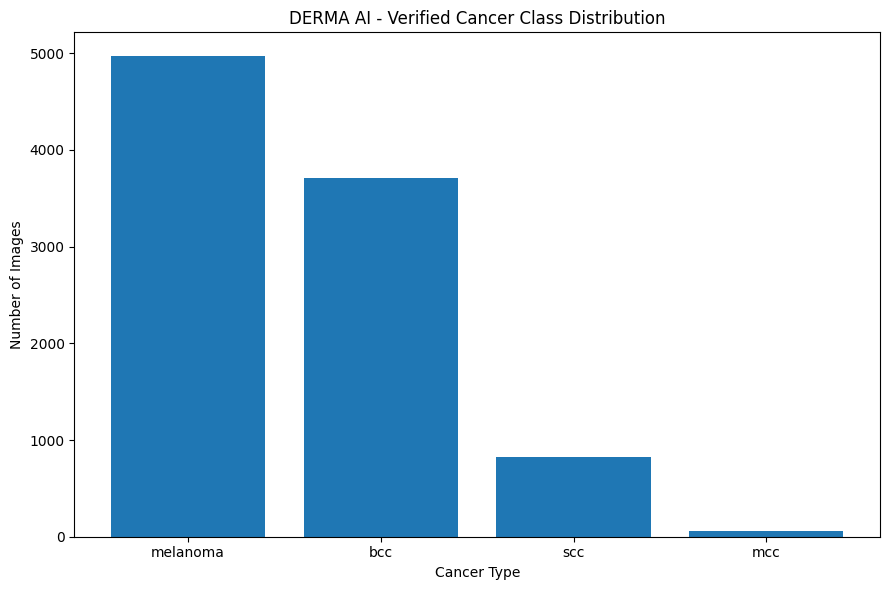


✅ Graph saved:
/kaggle/working/DERMA_AI/graphs/step6_verified_class_distribution.png

7️⃣ SOURCE × CLASS DISTRIBUTION


target_class_clean,bcc,mcc,melanoma,scc
dataset,,,,
isic_labelled,3316,0,4514,628
mcc_2,0,10,0,0
mcc_3,0,18,0,0
mcc_4,0,10,0,0
mcc_original,0,16,0,0
skin_cancer9,392,0,453,197



8️⃣ IMAGE DIMENSION SUMMARY


,metric,value
0,min_width,150.000000
1,max_width,6668.000000
2,mean_width,933.028156
3,median_width,1024.000000
4,min_height,182.000000
5,max_height,4421.000000
6,mean_height,860.079757
7,median_height,1024.000000



9️⃣ RANDOM VISUAL QUALITY CHECK


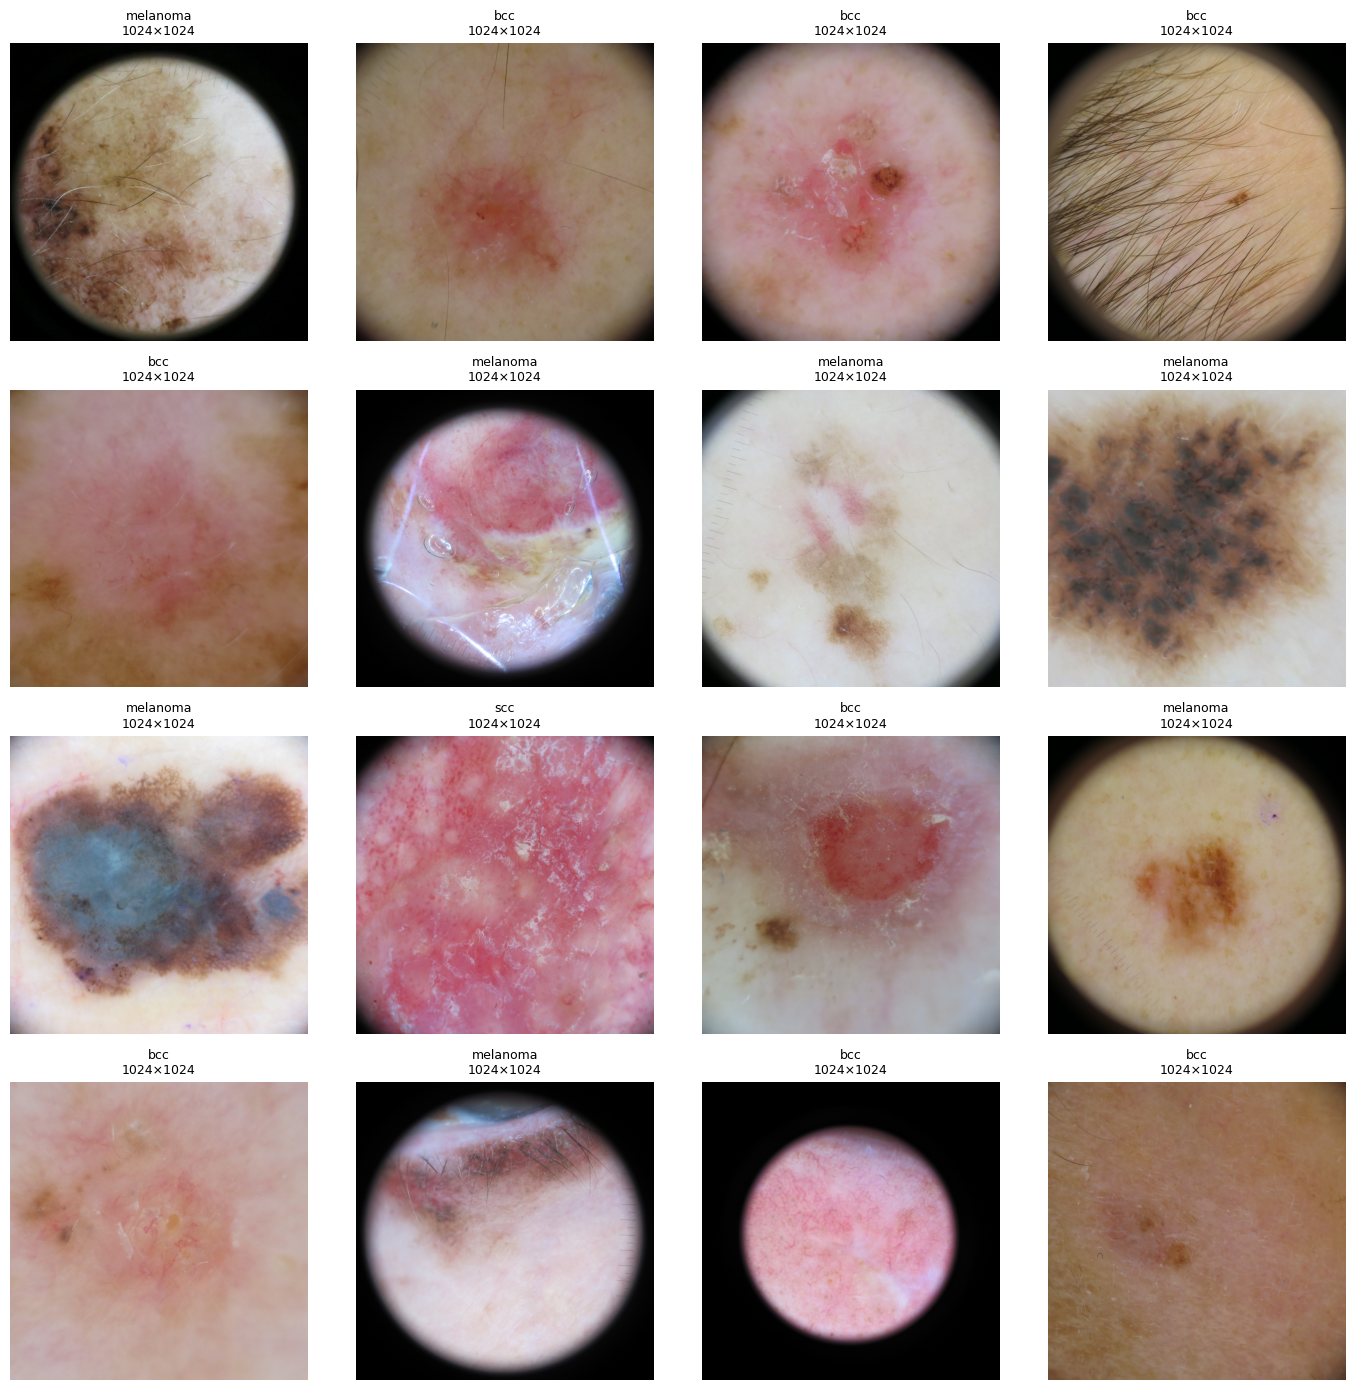


✅ Random image inspection saved:
/kaggle/working/DERMA_AI/graphs/step6_random_image_quality_check.png

✅ STEP 6 COMPLETED

Verified images : 9,554

Cancer classes:
  MELANOMA → 4,967
  BCC      → 3,708
  SCC      → 825
  MCC      → 54

Saved outputs:
  ✓ /kaggle/working/DERMA_AI/preprocessing/step6_verified_master_manifest.csv
  ✓ /kaggle/working/DERMA_AI/preprocessing/step6_verified_master_manifest_with_indices.csv
  ✓ /kaggle/working/DERMA_AI/dataset_analysis/step6_verified_class_distribution.csv
  ✓ /kaggle/working/DERMA_AI/dataset_analysis/step6_verified_source_class_distribution.csv
  ✓ /kaggle/working/DERMA_AI/dataset_analysis/step6_image_dimension_summary.csv
  ✓ /kaggle/working/DERMA_AI/dataset_analysis/step6_sha256_duplicate_groups.csv
  ✓ /kaggle/working/DERMA_AI/dataset_analysis/step6_missing_images.csv
  ✓ /kaggle/working/DERMA_AI/dataset_analysis/step6_corrupted_images.csv
  ✓ /kaggle/working/DERMA_AI/dataset_analysis/step6_verification_report.json
  ✓ /kaggle/working/DER

In [15]:
# ================================================================
# DERMA AI - STEP 6
# IMAGE VALIDATION + LABEL VERIFICATION + SPLIT PREPARATION
# ================================================================

import os
import json
import hashlib
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image, ImageFile
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = True

# ================================================================
# 1. PROJECT PATHS
# ================================================================

PROJECT_DIR = Path("/kaggle/working/DERMA_AI")

ANALYSIS_DIR = PROJECT_DIR / "dataset_analysis"
PREPROCESS_DIR = PROJECT_DIR / "preprocessing"
GRAPHS_DIR = PROJECT_DIR / "graphs"
METRICS_DIR = PROJECT_DIR / "metrics"
MODELS_DIR = PROJECT_DIR / "models"
CHECKPOINTS_DIR = PROJECT_DIR / "checkpoints"
PREDICTIONS_DIR = PROJECT_DIR / "predictions"
LOGS_DIR = PROJECT_DIR / "logs"
CONFIG_DIR = PROJECT_DIR / "configs"

for folder in [
    ANALYSIS_DIR,
    PREPROCESS_DIR,
    GRAPHS_DIR,
    METRICS_DIR,
    MODELS_DIR,
    CHECKPOINTS_DIR,
    PREDICTIONS_DIR,
    LOGS_DIR,
    CONFIG_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("=" * 90)
print("DERMA AI - STEP 6")
print("IMAGE VALIDATION + LABEL VERIFICATION + SPLIT PREPARATION")
print("=" * 90)


# ================================================================
# 2. LOAD STEP 5 MANIFEST
# ================================================================

MANIFEST_PATH = ANALYSIS_DIR / "step5_final_candidate_manifest.csv"

if not MANIFEST_PATH.exists():
    raise FileNotFoundError(
        f"Step 5 manifest not found:\n{MANIFEST_PATH}"
    )

df = pd.read_csv(MANIFEST_PATH)

print("\n" + "=" * 90)
print("1️⃣ STEP 5 MANIFEST LOADED")
print("=" * 90)

print(f"Manifest rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")

print("\nFirst rows:")
display(df.head())


# ================================================================
# 3. STANDARDIZE COLUMN NAMES
# ================================================================

df.columns = [
    str(c).strip().lower().replace(" ", "_")
    for c in df.columns
]

print("\nStandardized columns:")
print(list(df.columns))


# ================================================================
# 4. FIND IMPORTANT COLUMNS
# ================================================================

def find_column(possible_names):
    for name in possible_names:
        if name in df.columns:
            return name
    return None


PATH_COL = find_column([
    "filepath",
    "file_path",
    "path",
    "image_path",
    "full_path"
])

CLASS_COL = find_column([
    "target_class",
    "class",
    "label",
    "target"
])

SOURCE_COL = find_column([
    "dataset",
    "source_dataset",
    "source"
])

HASH_COL = find_column([
    "sha256",
    "hash",
    "image_hash"
])

if PATH_COL is None:
    raise ValueError(
        "Could not find image path column in Step 5 manifest."
    )

if CLASS_COL is None:
    raise ValueError(
        "Could not find target class column in Step 5 manifest."
    )

print("\nDetected columns:")
print(f"  Image path : {PATH_COL}")
print(f"  Class      : {CLASS_COL}")
print(f"  Source     : {SOURCE_COL}")
print(f"  SHA-256    : {HASH_COL}")


# ================================================================
# 5. NORMALIZE TARGET LABELS
# ================================================================

LABEL_MAP = {
    "mel": "melanoma",
    "melanoma": "melanoma",

    "bcc": "bcc",
    "basal cell carcinoma": "bcc",

    "scc": "scc",
    "squamous cell carcinoma": "scc",

    "mcc": "mcc",
    "merkel cell carcinoma": "mcc",
    "merkel-cell carcinoma": "mcc",
    "mercel cell carcinoma": "mcc"
}

df["target_class_clean"] = (
    df[CLASS_COL]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(LABEL_MAP)
)

unknown_labels = df[
    df["target_class_clean"].isna()
][CLASS_COL].value_counts()

if len(unknown_labels) > 0:
    print("\n⚠️ UNKNOWN LABELS FOUND:")
    print(unknown_labels)

    unknown_labels.to_csv(
        ANALYSIS_DIR / "step6_unknown_labels.csv"
    )

else:
    print("\n✅ All target labels recognized.")


# ================================================================
# 6. REMOVE UNKNOWN LABELS
# ================================================================

before_labels = len(df)

df = df[
    df["target_class_clean"].notna()
].copy()

removed_unknown = before_labels - len(df)

print(f"\nUnknown-label records removed: {removed_unknown:,}")


# ================================================================
# 7. IMAGE FILE EXISTENCE CHECK
# ================================================================

print("\n" + "=" * 90)
print("2️⃣ IMAGE FILE EXISTENCE CHECK")
print("=" * 90)

exist_results = []

for i, path in enumerate(df[PATH_COL].astype(str)):

    exists = os.path.isfile(path)

    exist_results.append(exists)

    if (i + 1) % 1000 == 0:
        print(f"Checked {i+1:,}/{len(df):,}")

df["file_exists"] = exist_results

missing_df = df[
    ~df["file_exists"]
].copy()

print(f"\nExisting files : {df['file_exists'].sum():,}")
print(f"Missing files  : {(~df['file_exists']).sum():,}")

missing_df.to_csv(
    ANALYSIS_DIR / "step6_missing_images.csv",
    index=False
)

df = df[
    df["file_exists"]
].copy()


# ================================================================
# 8. IMAGE READABILITY + BASIC IMAGE INFORMATION
# ================================================================

print("\n" + "=" * 90)
print("3️⃣ IMAGE READABILITY CHECK")
print("=" * 90)

widths = []
heights = []
modes = []
formats = []
valid_images = []
error_messages = []

for i, path in enumerate(df[PATH_COL].astype(str)):

    try:

        with Image.open(path) as img:

            # Force actual decoding
            img.verify()

        # Re-open after verify
        with Image.open(path) as img:

            widths.append(img.width)
            heights.append(img.height)
            modes.append(img.mode)
            formats.append(img.format)

        valid_images.append(True)
        error_messages.append("")

    except Exception as e:

        widths.append(None)
        heights.append(None)
        modes.append(None)
        formats.append(None)

        valid_images.append(False)
        error_messages.append(str(e))

    if (i + 1) % 1000 == 0:
        print(f"Validated {i+1:,}/{len(df):,}")

df["image_valid"] = valid_images
df["width"] = widths
df["height"] = heights
df["image_mode"] = modes
df["image_format"] = formats
df["validation_error"] = error_messages

bad_images = df[
    ~df["image_valid"]
].copy()

print("\nImage validation results:")
print(f"  Valid images   : {df['image_valid'].sum():,}")
print(f"  Invalid images : {(~df['image_valid']).sum():,}")

bad_images.to_csv(
    ANALYSIS_DIR / "step6_corrupted_images.csv",
    index=False
)

df = df[
    df["image_valid"]
].copy()


# ================================================================
# 9. REMOVE EXACT PATH DUPLICATES AGAIN
# ================================================================

before_path_dedup = len(df)

df = df.drop_duplicates(
    subset=[PATH_COL]
).copy()

print("\n" + "=" * 90)
print("4️⃣ PATH DUPLICATE CHECK")
print("=" * 90)

print(f"Before: {before_path_dedup:,}")
print(f"After : {len(df):,}")
print(f"Removed: {before_path_dedup - len(df):,}")


# ================================================================
# 10. SHA-256 RECHECK
# ================================================================

print("\n" + "=" * 90)
print("5️⃣ SHA-256 LEAKAGE CHECK")
print("=" * 90)

def calculate_sha256(file_path, chunk_size=1024 * 1024):

    sha = hashlib.sha256()

    with open(file_path, "rb") as f:

        while True:

            chunk = f.read(chunk_size)

            if not chunk:
                break

            sha.update(chunk)

    return sha.hexdigest()


if HASH_COL is None:

    hashes = []

    for i, path in enumerate(df[PATH_COL].astype(str)):

        try:
            hashes.append(
                calculate_sha256(path)
            )
        except Exception:
            hashes.append(None)

        if (i + 1) % 1000 == 0:
            print(f"Hashed {i+1:,}/{len(df):,}")

    df["sha256_clean"] = hashes

else:

    df["sha256_clean"] = (
        df[HASH_COL]
        .astype(str)
        .replace("nan", np.nan)
    )

    missing_hash = df["sha256_clean"].isna()

    if missing_hash.any():

        print(
            f"Calculating missing hashes: "
            f"{missing_hash.sum():,}"
        )

        df.loc[missing_hash, "sha256_clean"] = [
            calculate_sha256(path)
            for path in df.loc[missing_hash, PATH_COL]
        ]


# ================================================================
# 11. GLOBAL HASH DUPLICATES
# ================================================================

duplicate_hash_mask = df[
    "sha256_clean"
].duplicated(
    keep=False
)

duplicate_hash_df = df[
    duplicate_hash_mask
].copy()

print(f"\nImages with repeated SHA-256: {len(duplicate_hash_df):,}")

duplicate_hash_df.to_csv(
    ANALYSIS_DIR / "step6_sha256_duplicate_groups.csv",
    index=False
)


# ================================================================
# 12. KEEP ONLY ONE IMAGE PER SHA-256
# ================================================================

before_hash_dedup = len(df)

df = df.drop_duplicates(
    subset=["sha256_clean"],
    keep="first"
).copy()

print(f"\nBefore SHA-256 dedup: {before_hash_dedup:,}")
print(f"After SHA-256 dedup : {len(df):,}")
print(f"Removed             : {before_hash_dedup - len(df):,}")


# ================================================================
# 13. FINAL CLASS DISTRIBUTION
# ================================================================

print("\n" + "=" * 90)
print("6️⃣ VERIFIED CLASS DISTRIBUTION")
print("=" * 90)

class_counts = (
    df["target_class_clean"]
    .value_counts()
    .reindex(
        ["melanoma", "bcc", "scc", "mcc"],
        fill_value=0
    )
)

print(class_counts)

class_counts_df = (
    class_counts
    .rename_axis("target_class")
    .reset_index(name="image_count")
)

class_counts_df.to_csv(
    ANALYSIS_DIR / "step6_verified_class_distribution.csv",
    index=False
)


# ================================================================
# 14. CLASS DISTRIBUTION GRAPH
# ================================================================

plt.figure(figsize=(9, 6))

plt.bar(
    class_counts.index,
    class_counts.values
)

plt.title(
    "DERMA AI - Verified Cancer Class Distribution"
)

plt.xlabel("Cancer Type")
plt.ylabel("Number of Images")

plt.tight_layout()

graph_path = (
    GRAPHS_DIR /
    "step6_verified_class_distribution.png"
)

plt.savefig(
    graph_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(f"\n✅ Graph saved:")
print(graph_path)


# ================================================================
# 15. SOURCE × CLASS DISTRIBUTION
# ================================================================

if SOURCE_COL is not None:

    source_class = pd.crosstab(
        df[SOURCE_COL],
        df["target_class_clean"]
    )

    source_class.to_csv(
        ANALYSIS_DIR /
        "step6_verified_source_class_distribution.csv"
    )

    print("\n" + "=" * 90)
    print("7️⃣ SOURCE × CLASS DISTRIBUTION")
    print("=" * 90)

    display(source_class)


# ================================================================
# 16. IMAGE DIMENSION ANALYSIS
# ================================================================

dimension_summary = pd.DataFrame({
    "metric": [
        "min_width",
        "max_width",
        "mean_width",
        "median_width",
        "min_height",
        "max_height",
        "mean_height",
        "median_height"
    ],
    "value": [
        df["width"].min(),
        df["width"].max(),
        df["width"].mean(),
        df["width"].median(),
        df["height"].min(),
        df["height"].max(),
        df["height"].mean(),
        df["height"].median()
    ]
})

dimension_summary.to_csv(
    ANALYSIS_DIR /
    "step6_image_dimension_summary.csv",
    index=False
)

print("\n" + "=" * 90)
print("8️⃣ IMAGE DIMENSION SUMMARY")
print("=" * 90)

display(dimension_summary)


# ================================================================
# 17. RANDOM VISUAL QUALITY CHECK
# ================================================================

print("\n" + "=" * 90)
print("9️⃣ RANDOM VISUAL QUALITY CHECK")
print("=" * 90)

random.seed(42)

sample_size = min(16, len(df))

sample_df = df.sample(
    sample_size,
    random_state=42
).reset_index(drop=True)

fig, axes = plt.subplots(
    4,
    4,
    figsize=(14, 14)
)

axes = axes.flatten()

for ax in axes:
    ax.axis("off")

for i in range(sample_size):

    row = sample_df.iloc[i]

    try:

        img = Image.open(
            row[PATH_COL]
        ).convert("RGB")

        axes[i].imshow(img)

        axes[i].set_title(
            f"{row['target_class_clean']}\n"
            f"{row['width']}×{row['height']}",
            fontsize=9
        )

    except Exception:
        axes[i].set_title("READ ERROR")

plt.tight_layout()

sample_graph_path = (
    GRAPHS_DIR /
    "step6_random_image_quality_check.png"
)

plt.savefig(
    sample_graph_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(f"\n✅ Random image inspection saved:")
print(sample_graph_path)


# ================================================================
# 18. PREPARE MASTER VERIFIED MANIFEST
# ================================================================

FINAL_COLUMNS = [
    PATH_COL,
    "target_class_clean",
    "sha256_clean",
    "width",
    "height",
    "image_mode",
    "image_format"
]

if SOURCE_COL is not None:
    FINAL_COLUMNS.insert(
        1,
        SOURCE_COL
    )

final_manifest = df[
    FINAL_COLUMNS
].copy()

final_manifest = final_manifest.rename(
    columns={
        PATH_COL: "image_path",
        "target_class_clean": "target_class",
        "sha256_clean": "sha256"
    }
)

final_manifest.to_csv(
    PREPROCESS_DIR /
    "step6_verified_master_manifest.csv",
    index=False
)


# ================================================================
# 19. CLASS INDEX CONFIGURATION
# ================================================================

CLASS_NAMES = [
    "melanoma",
    "bcc",
    "scc",
    "mcc"
]

CLASS_TO_INDEX = {
    name: i
    for i, name in enumerate(CLASS_NAMES)
}

INDEX_TO_CLASS = {
    str(i): name
    for i, name in enumerate(CLASS_NAMES)
}

final_manifest["class_index"] = (
    final_manifest["target_class"]
    .map(CLASS_TO_INDEX)
)

final_manifest.to_csv(
    PREPROCESS_DIR /
    "step6_verified_master_manifest_with_indices.csv",
    index=False
)


# ================================================================
# 20. PROJECT CONFIG UPDATE
# ================================================================

config = {
    "project_name": "DERMA_AI",

    "objective": (
        "Skin cancer type prediction for four target cancer classes, "
        "with model development and validation focused on South Asian "
        "skin-tone representation."
    ),

    "target_classes": CLASS_NAMES,

    "class_to_index": CLASS_TO_INDEX,

    "image_input_size": [224, 224],

    "verified_image_count": int(len(final_manifest)),

    "class_counts": {
        str(k): int(v)
        for k, v in class_counts.items()
    },

    "random_seed": 42,

    "step": 6,

    "notes": [
        "Original Kaggle input datasets were not modified.",
        "Exact duplicate image files were removed using SHA-256.",
        "Invalid/unreadable images were excluded.",
        "No model training was performed in Step 6.",
        "Train/validation/test split will be created in the next step.",
        "Stage prediction will be handled separately using the 14 symptom features."
    ]
}

with open(
    CONFIG_DIR / "step6_config.json",
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )


# ================================================================
# 21. STEP 6 REPORT
# ================================================================

report = {
    "step": 6,

    "manifest_rows_initial": int(before_labels),

    "unknown_label_records_removed": int(
        removed_unknown
    ),

    "missing_files_removed": int(
        len(missing_df)
    ),

    "invalid_images_removed": int(
        len(bad_images)
    ),

    "final_verified_images": int(
        len(final_manifest)
    ),

    "sha256_duplicate_records_detected": int(
        len(duplicate_hash_df)
    ),

    "sha256_duplicates_removed": int(
        before_hash_dedup - len(df)
    ),

    "class_distribution": {
        str(k): int(v)
        for k, v in class_counts.items()
    },

    "class_names": CLASS_NAMES,

    "random_seed": 42,

    "training_performed": False,

    "validation_performed": False,

    "testing_performed": False,

    "south_asian_objective": True,

    "stage_prediction": {
        "method": "14 symptom based",
        "training_performed": False
    }
}

with open(
    ANALYSIS_DIR /
    "step6_verification_report.json",
    "w"
) as f:

    json.dump(
        report,
        f,
        indent=4
    )


# ================================================================
# 22. FINAL OUTPUT
# ================================================================

print("\n" + "=" * 90)
print("✅ STEP 6 COMPLETED")
print("=" * 90)

print(f"""
Verified images : {len(final_manifest):,}

Cancer classes:
  MELANOMA → {class_counts['melanoma']:,}
  BCC      → {class_counts['bcc']:,}
  SCC      → {class_counts['scc']:,}
  MCC      → {class_counts['mcc']:,}

Saved outputs:
  ✓ {PREPROCESS_DIR / 'step6_verified_master_manifest.csv'}
  ✓ {PREPROCESS_DIR / 'step6_verified_master_manifest_with_indices.csv'}
  ✓ {ANALYSIS_DIR / 'step6_verified_class_distribution.csv'}
  ✓ {ANALYSIS_DIR / 'step6_verified_source_class_distribution.csv'}
  ✓ {ANALYSIS_DIR / 'step6_image_dimension_summary.csv'}
  ✓ {ANALYSIS_DIR / 'step6_sha256_duplicate_groups.csv'}
  ✓ {ANALYSIS_DIR / 'step6_missing_images.csv'}
  ✓ {ANALYSIS_DIR / 'step6_corrupted_images.csv'}
  ✓ {ANALYSIS_DIR / 'step6_verification_report.json'}
  ✓ {CONFIG_DIR / 'step6_config.json'}
  ✓ {GRAPHS_DIR / 'step6_verified_class_distribution.png'}
  ✓ {GRAPHS_DIR / 'step6_random_image_quality_check.png'}

⚠️ NO MODEL TRAINING WAS PERFORMED.
⚠️ NO ORIGINAL DATASET FILES WERE MODIFIED.
⚠️ Train / validation / test split is NOT performed yet.
""")

print("=" * 90)

In [16]:
# ============================================================================
# DERMA AI - STEP 7
# TRAIN / VALIDATION / TEST SPLIT PREPARATION
# ============================================================================

import os
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split

print("=" * 90)
print("DERMA AI - STEP 7")
print("TRAIN / VALIDATION / TEST SPLIT PREPARATION")
print("=" * 90)

# ============================================================================
# 1. PROJECT DIRECTORIES
# ============================================================================

ROOT = Path("/kaggle/working/DERMA_AI")
PREPROCESSING_DIR = ROOT / "preprocessing"

PREPROCESSING_DIR.mkdir(parents=True, exist_ok=True)

print("\nProject directory:")
print(ROOT)

# ============================================================================
# 2. FIND STEP 6 MANIFEST
# ============================================================================

possible_manifests = [
    PREPROCESSING_DIR / "step6_verified_master_manifest_with_indices.csv",
    PREPROCESSING_DIR / "step6_verified_master_manifest.csv",
]

manifest_path = None

for p in possible_manifests:
    if p.exists():
        manifest_path = p
        break

# If not found in expected folder, search entire /kaggle/working
if manifest_path is None:
    print("\nSearching entire /kaggle/working ...")

    matches = list(
        Path("/kaggle/working").rglob(
            "step6_verified_master_manifest*.csv"
        )
    )

    if matches:
        manifest_path = matches[0]

# ============================================================================
# 3. STOP IF MANIFEST REALLY DOES NOT EXIST
# ============================================================================

if manifest_path is None:

    print("\n❌ STEP 6 MANIFEST NOT FOUND")
    print("\nFiles currently inside preprocessing folder:")

    if PREPROCESSING_DIR.exists():
        for f in PREPROCESSING_DIR.iterdir():
            print("   ", f.name)
    else:
        print("   preprocessing folder does not exist.")

    raise FileNotFoundError(
        "\nStep 6 manifest could not be found.\n"
        "Please run Step 6 first."
    )

print("\n✅ Step 6 manifest found:")
print(manifest_path)

# ============================================================================
# 4. LOAD MASTER MANIFEST
# ============================================================================

df = pd.read_csv(manifest_path)

print("\nMaster manifest loaded.")
print("Rows:", len(df))

print("\nColumns:")
print(df.columns.tolist())

# ============================================================================
# 5. CHECK REQUIRED COLUMNS
# ============================================================================

required_columns = [
    "image_path",
    "target_class",
]

missing_columns = [
    c for c in required_columns
    if c not in df.columns
]

if missing_columns:
    raise ValueError(
        f"\nMissing required columns: {missing_columns}\n"
        f"Available columns: {df.columns.tolist()}"
    )

# ============================================================================
# 6. REMOVE INVALID ROWS
# ============================================================================

df = df.dropna(
    subset=["image_path", "target_class"]
).copy()

df["target_class"] = df["target_class"].astype(str).str.lower().str.strip()

# ============================================================================
# 7. VERIFY IMAGE PATHS
# ============================================================================

print("\nChecking image paths...")

def path_exists(p):
    return os.path.exists(str(p))

df["path_exists"] = df["image_path"].apply(path_exists)

missing_images = df[~df["path_exists"]].copy()

if len(missing_images) > 0:

    print(
        f"⚠️ Missing images: {len(missing_images)}"
    )

    print("\nFirst missing paths:")
    print(
        missing_images["image_path"]
        .head(10)
        .to_string(index=False)
    )

    raise FileNotFoundError(
        f"\n{len(missing_images)} image paths are missing."
    )

df.drop(columns=["path_exists"], inplace=True)

print("✅ All image paths exist.")

# ============================================================================
# 8. CLASS DISTRIBUTION
# ============================================================================

print("\n" + "=" * 90)
print("FULL DATASET CLASS DISTRIBUTION")
print("=" * 90)

class_counts = df["target_class"].value_counts().sort_index()

print(class_counts)

# ============================================================================
# 9. FIX CLASS ORDER
# ============================================================================

class_names = [
    "melanoma",
    "bcc",
    "scc",
    "mcc"
]

# Check classes
found_classes = sorted(df["target_class"].unique())

print("\nFound classes:")
print(found_classes)

for cls in class_names:
    if cls not in found_classes:
        print(f"⚠️ Warning: {cls} not found in dataset.")

# Create class index
class_to_index = {
    cls: i
    for i, cls in enumerate(class_names)
}

df["class_index"] = df["target_class"].map(class_to_index)

# Check unmapped
if df["class_index"].isna().any():

    unknown = df.loc[
        df["class_index"].isna(),
        "target_class"
    ].unique()

    raise ValueError(
        f"\nUnknown classes found: {unknown}"
    )

df["class_index"] = df["class_index"].astype(int)

# ============================================================================
# 10. TRAIN / VALIDATION / TEST SPLIT
# ============================================================================

print("\n" + "=" * 90)
print("CREATING STRATIFIED SPLIT")
print("=" * 90)

# First split:
# 70% train
# 30% temporary

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["target_class"],
    random_state=42
)

# Second split:
# 15% validation
# 15% test

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["target_class"],
    random_state=42
)

# ============================================================================
# 11. ADD SPLIT COLUMN
# ============================================================================

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["split"] = "train"
val_df["split"] = "validation"
test_df["split"] = "test"

# Combine
final_df = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

# ============================================================================
# 12. SHUFFLE
# ============================================================================

final_df = final_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# ============================================================================
# 13. SAVE MANIFESTS
# ============================================================================

train_path = PREPROCESSING_DIR / "train_manifest.csv"
val_path = PREPROCESSING_DIR / "validation_manifest.csv"
test_path = PREPROCESSING_DIR / "test_manifest.csv"
final_path = PREPROCESSING_DIR / "final_split_manifest.csv"

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)
final_df.to_csv(final_path, index=False)

# ============================================================================
# 14. PRINT DATASET SIZES
# ============================================================================

print("\n" + "=" * 90)
print("SPLIT RESULTS")
print("=" * 90)

print(f"\nTrain      : {len(train_df)}")
print(f"Validation : {len(val_df)}")
print(f"Test       : {len(test_df)}")
print(f"Total      : {len(final_df)}")

# ============================================================================
# 15. CLASS DISTRIBUTION PER SPLIT
# ============================================================================

print("\n" + "=" * 90)
print("CLASS DISTRIBUTION")
print("=" * 90)

for name, split_df in [
    ("TRAIN", train_df),
    ("VALIDATION", val_df),
    ("TEST", test_df)
]:

    print(f"\n{name}")

    counts = (
        split_df["target_class"]
        .value_counts()
        .reindex(class_names, fill_value=0)
    )

    for cls, count in counts.items():
        print(f"   {cls:10s}: {count}")

# ============================================================================
# 16. CHECK FOR DUPLICATE HASH LEAKAGE
# ============================================================================

if "sha256" in final_df.columns:

    print("\n" + "=" * 90)
    print("CHECKING SHA-256 LEAKAGE")
    print("=" * 90)

    split_hashes = {}

    for split_name, split_df in [
        ("train", train_df),
        ("validation", val_df),
        ("test", test_df)
    ]:

        split_hashes[split_name] = set(
            split_df["sha256"].dropna().astype(str)
        )

    train_val = split_hashes["train"] & split_hashes["validation"]
    train_test = split_hashes["train"] & split_hashes["test"]
    val_test = split_hashes["validation"] & split_hashes["test"]

    print("Train ∩ Validation :", len(train_val))
    print("Train ∩ Test       :", len(train_test))
    print("Validation ∩ Test  :", len(val_test))

    if len(train_val) == 0 and len(train_test) == 0 and len(val_test) == 0:
        print("\n✅ NO SHA-256 LEAKAGE FOUND")
    else:
        raise ValueError(
            "\n❌ Duplicate images detected across splits!"
        )

# ============================================================================
# 17. FINAL SUMMARY
# ============================================================================

print("\n" + "=" * 90)
print("FILES SAVED")
print("=" * 90)

print(f"\nTrain manifest:")
print(train_path)

print("\nValidation manifest:")
print(val_path)

print("\nTest manifest:")
print(test_path)

print("\nFinal split manifest:")
print(final_path)

print("\n" + "=" * 90)
print("✅ STEP 7 COMPLETED SUCCESSFULLY")
print("=" * 90)

DERMA AI - STEP 7
TRAIN / VALIDATION / TEST SPLIT PREPARATION

Project directory:
/kaggle/working/DERMA_AI

✅ Step 6 manifest found:
/kaggle/working/DERMA_AI/preprocessing/step6_verified_master_manifest_with_indices.csv

Master manifest loaded.
Rows: 9554

Columns:
['image_path', 'dataset', 'target_class', 'sha256', 'width', 'height', 'image_mode', 'image_format', 'class_index']

Checking image paths...
✅ All image paths exist.

FULL DATASET CLASS DISTRIBUTION
target_class
bcc         3708
mcc           54
melanoma    4967
scc          825
Name: count, dtype: int64

Found classes:
['bcc', 'mcc', 'melanoma', 'scc']

CREATING STRATIFIED SPLIT

SPLIT RESULTS

Train      : 6687
Validation : 1433
Test       : 1434
Total      : 9554

CLASS DISTRIBUTION

TRAIN
   melanoma  : 3477
   bcc       : 2595
   scc       : 577
   mcc       : 38

VALIDATION
   melanoma  : 745
   bcc       : 556
   scc       : 124
   mcc       : 8

TEST
   melanoma  : 745
   bcc       : 557
   scc       : 124
   mcc    

In [17]:
# ================================================================
# DERMA AI - STEP 7
# TRAIN / VALIDATION / TEST SPLIT PREPARATION
# ================================================================

import os
import json
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

print("=" * 90)
print("DERMA AI - STEP 7")
print("TRAIN / VALIDATION / TEST SPLIT PREPARATION")
print("=" * 90)


# ================================================================
# 1. PROJECT PATHS
# ================================================================

PROJECT_DIR = "/kaggle/working/DERMA_AI"

DATASET_ANALYSIS_DIR = os.path.join(
    PROJECT_DIR, "dataset_analysis"
)

PREPROCESSING_DIR = os.path.join(
    PROJECT_DIR, "preprocessing"
)

os.makedirs(DATASET_ANALYSIS_DIR, exist_ok=True)
os.makedirs(PREPROCESSING_DIR, exist_ok=True)


# ================================================================
# 2. LOAD STEP 6 MANIFEST
# ================================================================

STEP6_FILE = os.path.join(
    PREPROCESSING_DIR,
    "step6_verified_manifest.csv"
)

# If the expected filename does not exist,
# search preprocessing folder for CSV files.

if not os.path.exists(STEP6_FILE):

    csv_files = [
        os.path.join(PREPROCESSING_DIR, f)
        for f in os.listdir(PREPROCESSING_DIR)
        if f.lower().endswith(".csv")
    ]

    if len(csv_files) == 0:
        raise FileNotFoundError(
            "No STEP 6 CSV file found inside: "
            + PREPROCESSING_DIR
        )

    print("⚠️ Expected STEP 6 filename not found.")
    print("Available CSV files:")

    for f in csv_files:
        print("  ", f)

    # Use the most recently modified CSV
    STEP6_FILE = max(
        csv_files,
        key=os.path.getmtime
    )

print("\nSTEP 6 manifest:")
print(STEP6_FILE)

df = pd.read_csv(STEP6_FILE)

print("\nManifest rows:", len(df))
print("Columns:")
print(df.columns.tolist())


# ================================================================
# 3. NORMALIZE COLUMN NAMES
# ================================================================

# STEP 6 currently has:
# image_path
# dataset
# target_class
# sha256
# width
# height
# image_mode
# image_format

# We will standardize them for STEP 7.

if "filepath" not in df.columns:

    if "image_path" in df.columns:
        df["filepath"] = df["image_path"]

    else:
        raise ValueError(
            "Neither 'filepath' nor 'image_path' "
            "exists in STEP 6 manifest."
        )


# Create image_id if missing

if "image_id" not in df.columns:

    df.insert(
        0,
        "image_id",
        [
            f"DERMA_{i:06d}"
            for i in range(1, len(df) + 1)
        ]
    )


# ================================================================
# 4. REQUIRED COLUMN CHECK
# ================================================================

required_columns = [
    "image_id",
    "filepath",
    "target_class"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:

    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("\n✅ Required columns available.")


# ================================================================
# 5. REMOVE INVALID BASIC RECORDS
# ================================================================

before_clean = len(df)

df = df.dropna(
    subset=[
        "image_id",
        "filepath",
        "target_class"
    ]
).copy()

df["target_class"] = (
    df["target_class"]
    .astype(str)
    .str.lower()
    .str.strip()
)

valid_classes = [
    "melanoma",
    "bcc",
    "scc",
    "mcc"
]

df = df[
    df["target_class"].isin(valid_classes)
].copy()

after_clean = len(df)

print("\nBasic manifest cleaning:")
print("Before:", before_clean)
print("After :", after_clean)
print("Removed:", before_clean - after_clean)


# ================================================================
# 6. VERIFY IMAGE FILES
# ================================================================

print("\n" + "=" * 90)
print("IMAGE FILE EXISTENCE VERIFICATION")
print("=" * 90)

exists_mask = df["filepath"].apply(
    os.path.isfile
)

missing_count = (~exists_mask).sum()

df = df[exists_mask].copy()

print("Existing files:", len(df))
print("Missing files :", missing_count)


# ================================================================
# 7. CLASS DISTRIBUTION BEFORE SPLIT
# ================================================================

print("\n" + "=" * 90)
print("CLASS DISTRIBUTION BEFORE SPLIT")
print("=" * 90)

class_counts = (
    df["target_class"]
    .value_counts()
    .sort_index()
)

print(class_counts)


# ================================================================
# 8. HANDLE SHA-256
# ================================================================

# SHA-256 already exists from STEP 6.
# It is important because the same image must not
# appear in both train and test.

if "sha256" not in df.columns:

    print(
        "\n⚠️ SHA-256 column not found."
    )

    print(
        "Using filepath as grouping key."
    )

    df["split_group"] = df["filepath"]

else:

    df["split_group"] = (
        df["sha256"]
        .fillna(df["filepath"])
        .astype(str)
    )


# ================================================================
# 9. REMOVE ANY REMAINING DUPLICATE GROUPS
# ================================================================

before_group_dedup = len(df)

df = df.drop_duplicates(
    subset=["split_group"],
    keep="first"
).copy()

after_group_dedup = len(df)

print("\nSHA/group duplicate protection:")
print("Before:", before_group_dedup)
print("After :", after_group_dedup)
print("Removed:", before_group_dedup - after_group_dedup)


# ================================================================
# 10. TRAIN / VALIDATION / TEST SPLIT
# ================================================================

print("\n" + "=" * 90)
print("CREATING TRAIN / VALIDATION / TEST SPLITS")
print("=" * 90)

# Target:
#
# TRAIN      = 70%
# VALIDATION = 15%
# TEST       = 15%

RANDOM_STATE = 42

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=df["target_class"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temp_df["target_class"]
)


# ================================================================
# 11. ADD SPLIT COLUMN
# ================================================================

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["split"] = "train"
val_df["split"] = "validation"
test_df["split"] = "test"


# ================================================================
# 12. COMBINE SPLIT MANIFEST
# ================================================================

split_df = pd.concat(
    [
        train_df,
        val_df,
        test_df
    ],
    ignore_index=True
)

# Shuffle final manifest

split_df = split_df.sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)


# ================================================================
# 13. PRINT SPLIT COUNTS
# ================================================================

print("\nSplit sizes:")

print(
    split_df["split"]
    .value_counts()
)


print("\nClass × Split distribution:")

split_distribution = pd.crosstab(
    split_df["target_class"],
    split_df["split"]
)

print(split_distribution)


# ================================================================
# 14. VERIFY NO SHA-256 LEAKAGE
# ================================================================

print("\n" + "=" * 90)
print("SHA-256 SPLIT LEAKAGE VERIFICATION")
print("=" * 90)

if "sha256" in split_df.columns:

    sha_split_counts = (
        split_df
        .groupby("sha256")["split"]
        .nunique()
    )

    leakage_groups = (
        sha_split_counts[
            sha_split_counts > 1
        ]
    )

    print(
        "Images appearing in multiple splits:",
        len(leakage_groups)
    )

    if len(leakage_groups) == 0:

        print(
            "✅ NO SHA-256 LEAKAGE DETECTED"
        )

    else:

        print(
            "❌ WARNING: SHA-256 leakage detected!"
        )

else:

    print(
        "⚠️ SHA-256 column unavailable."
    )


# ================================================================
# 15. SAVE INDIVIDUAL SPLITS
# ================================================================

TRAIN_FILE = os.path.join(
    PREPROCESSING_DIR,
    "train_manifest.csv"
)

VAL_FILE = os.path.join(
    PREPROCESSING_DIR,
    "validation_manifest.csv"
)

TEST_FILE = os.path.join(
    PREPROCESSING_DIR,
    "test_manifest.csv"
)

ALL_SPLIT_FILE = os.path.join(
    PREPROCESSING_DIR,
    "final_split_manifest.csv"
)

train_df.to_csv(
    TRAIN_FILE,
    index=False
)

val_df.to_csv(
    VAL_FILE,
    index=False
)

test_df.to_csv(
    TEST_FILE,
    index=False
)

split_df.to_csv(
    ALL_SPLIT_FILE,
    index=False
)


# ================================================================
# 16. SAVE CLASS × SPLIT COUNTS
# ================================================================

distribution_file = os.path.join(
    DATASET_ANALYSIS_DIR,
    "step7_class_split_distribution.csv"
)

split_distribution.to_csv(
    distribution_file
)


# ================================================================
# 17. SAVE SPLIT SUMMARY
# ================================================================

summary = {
    "total_images": int(len(split_df)),

    "train_images": int(len(train_df)),

    "validation_images": int(len(val_df)),

    "test_images": int(len(test_df)),

    "train_ratio": float(
        len(train_df) / len(split_df)
    ),

    "validation_ratio": float(
        len(val_df) / len(split_df)
    ),

    "test_ratio": float(
        len(test_df) / len(split_df)
    ),

    "random_state": RANDOM_STATE,

    "classes": valid_classes,

    "class_counts": {
        str(k): int(v)
        for k, v in
        split_df["target_class"]
        .value_counts()
        .items()
    }
}


summary_file = os.path.join(
    DATASET_ANALYSIS_DIR,
    "step7_split_summary.json"
)

with open(
    summary_file,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )


# ================================================================
# 18. FINAL OUTPUT
# ================================================================

print("\n" + "=" * 90)
print("✅ STEP 7 COMPLETED")
print("=" * 90)

print("\nFINAL DATASET:")
print("Total      :", len(split_df))
print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))

print("\nClass distribution:")
print(
    split_df["target_class"]
    .value_counts()
)

print("\nSaved files:")

print(
    "✓", TRAIN_FILE
)

print(
    "✓", VAL_FILE
)

print(
    "✓", TEST_FILE
)

print(
    "✓", ALL_SPLIT_FILE
)

print(
    "✓", distribution_file
)

print(
    "✓", summary_file
)

print("\n" + "=" * 90)
print("NO MODEL TRAINING PERFORMED IN STEP 7")
print("NO ORIGINAL KAGGLE DATASET MODIFIED")
print("=" * 90)

DERMA AI - STEP 7
TRAIN / VALIDATION / TEST SPLIT PREPARATION
⚠️ Expected STEP 6 filename not found.
Available CSV files:
   /kaggle/working/DERMA_AI/preprocessing/test_manifest.csv
   /kaggle/working/DERMA_AI/preprocessing/train_manifest.csv
   /kaggle/working/DERMA_AI/preprocessing/validation_manifest.csv
   /kaggle/working/DERMA_AI/preprocessing/step6_verified_master_manifest.csv
   /kaggle/working/DERMA_AI/preprocessing/final_split_manifest.csv
   /kaggle/working/DERMA_AI/preprocessing/step6_verified_master_manifest_with_indices.csv

STEP 6 manifest:
/kaggle/working/DERMA_AI/preprocessing/final_split_manifest.csv

Manifest rows: 9554
Columns:
['image_path', 'dataset', 'target_class', 'sha256', 'width', 'height', 'image_mode', 'image_format', 'class_index', 'split']

✅ Required columns available.

Basic manifest cleaning:
Before: 9554
After : 9554
Removed: 0

IMAGE FILE EXISTENCE VERIFICATION
Existing files: 9554
Missing files : 0

CLASS DISTRIBUTION BEFORE SPLIT
target_class
bcc   

In [18]:
# =============================================================================
# DERMA AI - STEP 8
# ACTUAL IMAGE TRAINING SETUP + CLASS IMBALANCE HANDLING
# =============================================================================

import os
import json
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight

print("=" * 90)
print("DERMA AI - STEP 8")
print("ACTUAL IMAGE TRAINING SETUP + CLASS IMBALANCE HANDLING")
print("=" * 90)

# -----------------------------------------------------------------------------
# 1. PROJECT DIRECTORIES
# -----------------------------------------------------------------------------

PROJECT_DIR = "/kaggle/working/DERMA_AI"

MODEL_DIR = os.path.join(PROJECT_DIR, "models")
CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
GRAPH_DIR = os.path.join(PROJECT_DIR, "graphs")
METRIC_DIR = os.path.join(PROJECT_DIR, "metrics")
PREDICTION_DIR = os.path.join(PROJECT_DIR, "predictions")
PREPROCESSING_DIR = os.path.join(PROJECT_DIR, "preprocessing")
CONFIG_DIR = os.path.join(PROJECT_DIR, "configs")
LOG_DIR = os.path.join(PROJECT_DIR, "logs")

for directory in [
    MODEL_DIR,
    CHECKPOINT_DIR,
    GRAPH_DIR,
    METRIC_DIR,
    PREDICTION_DIR,
    PREPROCESSING_DIR,
    CONFIG_DIR,
    LOG_DIR
]:
    os.makedirs(directory, exist_ok=True)

print("\n✅ Project directories ready")

# -----------------------------------------------------------------------------
# 2. LOAD STEP 7 MANIFESTS
# -----------------------------------------------------------------------------

TRAIN_CSV = os.path.join(PREPROCESSING_DIR, "train_manifest.csv")
VAL_CSV = os.path.join(PREPROCESSING_DIR, "validation_manifest.csv")
TEST_CSV = os.path.join(PREPROCESSING_DIR, "test_manifest.csv")

if not os.path.exists(TRAIN_CSV):
    raise FileNotFoundError(f"Training manifest not found:\n{TRAIN_CSV}")

if not os.path.exists(VAL_CSV):
    raise FileNotFoundError(f"Validation manifest not found:\n{VAL_CSV}")

if not os.path.exists(TEST_CSV):
    raise FileNotFoundError(f"Test manifest not found:\n{TEST_CSV}")

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print("\n" + "=" * 90)
print("1️⃣ STEP 7 MANIFESTS LOADED")
print("=" * 90)

print(f"Train      : {len(train_df)}")
print(f"Validation : {len(val_df)}")
print(f"Test       : {len(test_df)}")

# -----------------------------------------------------------------------------
# 3. VERIFY REQUIRED COLUMNS
# -----------------------------------------------------------------------------

required_columns = ["image_path", "target_class"]

for name, df in [
    ("TRAIN", train_df),
    ("VALIDATION", val_df),
    ("TEST", test_df)
]:
    missing = [c for c in required_columns if c not in df.columns]

    if missing:
        raise ValueError(
            f"{name} manifest missing columns: {missing}"
        )

print("\n✅ Required columns verified")

# -----------------------------------------------------------------------------
# 4. DEFINE CANCER CLASSES
# -----------------------------------------------------------------------------

CLASS_NAMES = [
    "melanoma",
    "bcc",
    "scc",
    "mcc"
]

CLASS_TO_INDEX = {
    "melanoma": 0,
    "bcc": 1,
    "scc": 2,
    "mcc": 3
}

INDEX_TO_CLASS = {
    0: "melanoma",
    1: "bcc",
    2: "scc",
    3: "mcc"
}

NUM_CLASSES = len(CLASS_NAMES)

print("\n" + "=" * 90)
print("2️⃣ MODEL CLASSES")
print("=" * 90)

for i, cls in enumerate(CLASS_NAMES):
    print(f"{i} → {cls}")

# -----------------------------------------------------------------------------
# 5. CLEAN LABELS
# -----------------------------------------------------------------------------

for df in [train_df, val_df, test_df]:
    df["target_class"] = (
        df["target_class"]
        .astype(str)
        .str.lower()
        .str.strip()
    )

invalid_classes = set(train_df["target_class"]) - set(CLASS_NAMES)

if invalid_classes:
    raise ValueError(
        f"Unknown classes found in training data: {invalid_classes}"
    )

# -----------------------------------------------------------------------------
# 6. VERIFY IMAGE FILES
# -----------------------------------------------------------------------------

print("\n" + "=" * 90)
print("3️⃣ VERIFYING ACTUAL IMAGE FILES")
print("=" * 90)

for name, df in [
    ("TRAIN", train_df),
    ("VALIDATION", val_df),
    ("TEST", test_df)
]:

    missing_files = []

    for path in df["image_path"]:
        if not os.path.isfile(path):
            missing_files.append(path)

    print(
        f"{name:12s} → "
        f"Images: {len(df):5d} | "
        f"Missing: {len(missing_files):5d}"
    )

    if missing_files:
        raise FileNotFoundError(
            f"{name} contains missing image files."
        )

print("\n✅ All actual image files verified")

# -----------------------------------------------------------------------------
# 7. CLASS DISTRIBUTION
# -----------------------------------------------------------------------------

print("\n" + "=" * 90)
print("4️⃣ TRAINING CLASS DISTRIBUTION")
print("=" * 90)

train_counts = train_df["target_class"].value_counts()

for cls in CLASS_NAMES:
    print(
        f"{cls.upper():10s} → "
        f"{train_counts.get(cls, 0)} images"
    )

# -----------------------------------------------------------------------------
# 8. CALCULATE CLASS WEIGHTS
# -----------------------------------------------------------------------------

print("\n" + "=" * 90)
print("5️⃣ CLASS IMBALANCE HANDLING")
print("=" * 90)

y_train = train_df["target_class"].map(CLASS_TO_INDEX).values

class_indices = np.arange(NUM_CLASSES)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=class_indices,
    y=y_train
)

CLASS_WEIGHTS = {
    int(i): float(w)
    for i, w in zip(class_indices, class_weights_array)
}

print("\nCalculated class weights:")

for i, cls in enumerate(CLASS_NAMES):
    print(
        f"{cls.upper():10s} → "
        f"{CLASS_WEIGHTS[i]:.4f}"
    )

# -----------------------------------------------------------------------------
# 9. TRAINING CONFIGURATION
# -----------------------------------------------------------------------------

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

INITIAL_EPOCHS = 15
FINE_TUNE_EPOCHS = 15

SEED = 42

print("\n" + "=" * 90)
print("6️⃣ TRAINING CONFIGURATION")
print("=" * 90)

print(f"Image size          : {IMG_SIZE}")
print(f"Batch size          : {BATCH_SIZE}")
print(f"Initial epochs      : {INITIAL_EPOCHS}")
print(f"Fine-tune epochs    : {FINE_TUNE_EPOCHS}")
print(f"Random seed         : {SEED}")

# -----------------------------------------------------------------------------
# 10. REPRODUCIBILITY
# -----------------------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("\n✅ Random seeds fixed")

# -----------------------------------------------------------------------------
# 11. SAVE TRAINING CONFIGURATION
# -----------------------------------------------------------------------------

training_config = {
    "project": "DERMA_AI",
    "task": "4-class skin cancer classification",
    "classes": CLASS_NAMES,
    "class_to_index": CLASS_TO_INDEX,
    "num_classes": NUM_CLASSES,
    "image_size": list(IMG_SIZE),
    "batch_size": BATCH_SIZE,
    "initial_epochs": INITIAL_EPOCHS,
    "fine_tune_epochs": FINE_TUNE_EPOCHS,
    "seed": SEED,
    "class_weights": CLASS_WEIGHTS,
    "train_images": len(train_df),
    "validation_images": len(val_df),
    "test_images": len(test_df),
    "model_backbone": "EfficientNetB0",
    "augmentation": "training_only"
}

CONFIG_PATH = os.path.join(
    CONFIG_DIR,
    "step8_training_config.json"
)

with open(CONFIG_PATH, "w") as f:
    json.dump(training_config, f, indent=4)

print("\n💾 Configuration saved:")
print(CONFIG_PATH)

# -----------------------------------------------------------------------------
# 12. SAVE CLASS WEIGHTS
# -----------------------------------------------------------------------------

weights_df = pd.DataFrame({
    "class_index": list(range(NUM_CLASSES)),
    "class_name": CLASS_NAMES,
    "training_images": [
        int(train_counts.get(cls, 0))
        for cls in CLASS_NAMES
    ],
    "class_weight": [
        CLASS_WEIGHTS[i]
        for i in range(NUM_CLASSES)
    ]
})

WEIGHTS_PATH = os.path.join(
    METRIC_DIR,
    "step8_class_weights.csv"
)

weights_df.to_csv(WEIGHTS_PATH, index=False)

print("\n💾 Class weights saved:")
print(WEIGHTS_PATH)

print("\n" + "=" * 90)
print("✅ STEP 8 COMPLETED")
print("=" * 90)

print("""
IMPORTANT:
-----------
This step prepared the REAL image data for training.

Actual images will be loaded from their original Kaggle paths
during the next training step.

Class imbalance will be handled using class weights.

Training augmentation → YES
Validation augmentation → NO
Test augmentation → NO

No images are copied unnecessarily.
No original Kaggle dataset is modified.

Next:
STEP 9 → TensorFlow datasets + augmentation + EfficientNetB0 model
""")

DERMA AI - STEP 8
ACTUAL IMAGE TRAINING SETUP + CLASS IMBALANCE HANDLING

✅ Project directories ready

1️⃣ STEP 7 MANIFESTS LOADED
Train      : 6687
Validation : 1433
Test       : 1434

✅ Required columns verified

2️⃣ MODEL CLASSES
0 → melanoma
1 → bcc
2 → scc
3 → mcc

3️⃣ VERIFYING ACTUAL IMAGE FILES
TRAIN        → Images:  6687 | Missing:     0
VALIDATION   → Images:  1433 | Missing:     0
TEST         → Images:  1434 | Missing:     0

✅ All actual image files verified

4️⃣ TRAINING CLASS DISTRIBUTION
MELANOMA   → 3477 images
BCC        → 2595 images
SCC        → 577 images
MCC        → 38 images

5️⃣ CLASS IMBALANCE HANDLING

Calculated class weights:
MELANOMA   → 0.4808
BCC        → 0.6442
SCC        → 2.8973
MCC        → 43.9934

6️⃣ TRAINING CONFIGURATION
Image size          : (224, 224)
Batch size          : 32
Initial epochs      : 15
Fine-tune epochs    : 15
Random seed         : 42

✅ Random seeds fixed

💾 Configuration saved:
/kaggle/working/DERMA_AI/configs/step8_training_

In [19]:
# =============================================================================
# DERMA AI - STEP 9
# TENSORFLOW DATASETS + AUGMENTATION + EFFICIENTNETB0 MODEL
# =============================================================================

import os
import json
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0

print("=" * 90)
print("DERMA AI - STEP 9")
print("TENSORFLOW DATASETS + AUGMENTATION + EFFICIENTNETB0 MODEL")
print("=" * 90)

# =============================================================================
# 1. PROJECT DIRECTORIES
# =============================================================================

PROJECT_DIR = "/kaggle/working/DERMA_AI"

PREPROCESSING_DIR = os.path.join(PROJECT_DIR, "preprocessing")
CONFIG_DIR = os.path.join(PROJECT_DIR, "configs")
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
GRAPH_DIR = os.path.join(PROJECT_DIR, "graphs")
METRICS_DIR = os.path.join(PROJECT_DIR, "metrics")
PREDICTION_DIR = os.path.join(PROJECT_DIR, "predictions")
LOG_DIR = os.path.join(PROJECT_DIR, "logs")

for d in [
    PREPROCESSING_DIR,
    CONFIG_DIR,
    MODEL_DIR,
    CHECKPOINT_DIR,
    GRAPH_DIR,
    METRICS_DIR,
    PREDICTION_DIR,
    LOG_DIR
]:
    os.makedirs(d, exist_ok=True)

print("\nProject directories ready.")

# =============================================================================
# 2. RANDOM SEEDS
# =============================================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("\nRandom seed:", SEED)

# =============================================================================
# 3. LOAD STEP 7 MANIFESTS
# =============================================================================

train_path = os.path.join(
    PREPROCESSING_DIR,
    "train_manifest.csv"
)

val_path = os.path.join(
    PREPROCESSING_DIR,
    "validation_manifest.csv"
)

test_path = os.path.join(
    PREPROCESSING_DIR,
    "test_manifest.csv"
)

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

print("\n" + "=" * 90)
print("1. STEP 7 MANIFESTS")
print("=" * 90)

print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))

# =============================================================================
# 4. STANDARDIZE IMAGE PATH COLUMN
# =============================================================================

def standardize_manifest(df):

    df = df.copy()

    if "image_path" not in df.columns:

        if "filepath" in df.columns:
            df["image_path"] = df["filepath"]

        else:
            raise ValueError(
                "Manifest must contain image_path or filepath"
            )

    if "target_class" not in df.columns:
        raise ValueError(
            "Manifest must contain target_class"
        )

    return df


train_df = standardize_manifest(train_df)
val_df = standardize_manifest(val_df)
test_df = standardize_manifest(test_df)

# =============================================================================
# 5. MODEL CLASS MAPPING
# =============================================================================

CLASS_NAMES = [
    "melanoma",
    "bcc",
    "scc",
    "mcc"
]

CLASS_TO_INDEX = {
    "melanoma": 0,
    "bcc": 1,
    "scc": 2,
    "mcc": 3
}

INDEX_TO_CLASS = {
    0: "melanoma",
    1: "bcc",
    2: "scc",
    3: "mcc"
}

print("\n" + "=" * 90)
print("2. MODEL CLASSES")
print("=" * 90)

for i, name in enumerate(CLASS_NAMES):
    print(f"{i} → {name}")

# =============================================================================
# 6. CONVERT LABELS TO INTEGER INDEX
# =============================================================================

def prepare_labels(df):

    df = df.copy()

    df["target_class"] = (
        df["target_class"]
        .astype(str)
        .str.lower()
        .str.strip()
    )

    unknown = sorted(
        set(df["target_class"]) - set(CLASS_TO_INDEX.keys())
    )

    if unknown:
        raise ValueError(
            f"Unknown classes found: {unknown}"
        )

    df["class_index"] = df["target_class"].map(
        CLASS_TO_INDEX
    )

    return df


train_df = prepare_labels(train_df)
val_df = prepare_labels(val_df)
test_df = prepare_labels(test_df)

# =============================================================================
# 7. VERIFY REAL IMAGE FILES
# =============================================================================

print("\n" + "=" * 90)
print("3. VERIFYING ACTUAL IMAGE FILES")
print("=" * 90)

def verify_files(df, name):

    exists = df["image_path"].apply(
        os.path.isfile
    )

    missing = (~exists).sum()

    print(
        f"{name:<12} → Images: {len(df):5d} | "
        f"Missing: {missing:5d}"
    )

    if missing > 0:
        raise FileNotFoundError(
            f"{name} contains {missing} missing image files."
        )


verify_files(train_df, "TRAIN")
verify_files(val_df, "VALIDATION")
verify_files(test_df, "TEST")

print("\nAll actual image files verified.")

# =============================================================================
# 8. IMAGE CONFIGURATION
# =============================================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 4

print("\n" + "=" * 90)
print("4. IMAGE CONFIGURATION")
print("=" * 90)

print("Image size :", IMG_SIZE)
print("Batch size :", BATCH_SIZE)
print("Classes    :", NUM_CLASSES)

# =============================================================================
# 9. TF.DATA IMAGE LOADING
# =============================================================================

def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape(
        [None, None, 3]
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image, label


def create_dataset(df, training=False):

    paths = df["image_path"].values
    labels = df["class_index"].values.astype(np.int32)

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if training:

        dataset = dataset.shuffle(
            buffer_size=len(df),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset


train_ds = create_dataset(
    train_df,
    training=True
)

val_ds = create_dataset(
    val_df,
    training=False
)

test_ds = create_dataset(
    test_df,
    training=False
)

print("\nTensorFlow datasets created.")

# =============================================================================
# 10. DATA AUGMENTATION
# =============================================================================

data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip(
            "horizontal"
        ),

        layers.RandomRotation(
            0.08
        ),

        layers.RandomZoom(
            0.10
        ),

        layers.RandomContrast(
            0.10
        ),

        layers.RandomTranslation(
            height_factor=0.05,
            width_factor=0.05
        )
    ],
    name="data_augmentation"
)

print("\n" + "=" * 90)
print("5. TRAINING AUGMENTATION")
print("=" * 90)

print("RandomFlip        : YES")
print("RandomRotation    : YES")
print("RandomZoom        : YES")
print("RandomContrast    : YES")
print("RandomTranslation : YES")

print("\nValidation augmentation : NO")
print("Test augmentation       : NO")

# =============================================================================
# 11. BUILD EFFICIENTNETB0 BACKBONE
# =============================================================================

print("\n" + "=" * 90)
print("6. BUILDING MODEL")
print("=" * 90)

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# Freeze backbone for initial training
base_model.trainable = False

# =============================================================================
# 12. MODEL ARCHITECTURE
# =============================================================================

inputs = layers.Input(
    shape=(224, 224, 3),
    name="image_input"
)

x = data_augmentation(
    inputs
)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = layers.Dropout(
    0.40,
    name="dropout"
)(x)

x = layers.Dense(
    128,
    activation="relu",
    name="dense_128"
)(x)

x = layers.Dropout(
    0.30,
    name="dense_dropout"
)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="classification_output"
)(x)

model = Model(
    inputs=inputs,
    outputs=outputs,
    name="DERMA_AI_EfficientNetB0"
)

# =============================================================================
# 13. MODEL SUMMARY
# =============================================================================

print("\n" + "=" * 90)
print("7. MODEL LAYERS")
print("=" * 90)

model.summary()

# =============================================================================
# 14. SAVE MODEL ARCHITECTURE
# =============================================================================

architecture_path = os.path.join(
    CONFIG_DIR,
    "step9_model_architecture.json"
)

architecture = {
    "model_name": "DERMA_AI_EfficientNetB0",

    "input": {
        "height": 224,
        "width": 224,
        "channels": 3
    },

    "backbone": {
        "name": "EfficientNetB0",
        "pretrained": "ImageNet",
        "include_top": False,
        "initially_frozen": True
    },

    "augmentation": [
        "RandomFlip(horizontal)",
        "RandomRotation(0.08)",
        "RandomZoom(0.10)",
        "RandomContrast(0.10)",
        "RandomTranslation(0.05, 0.05)"
    ],

    "classification_head": [
        "GlobalAveragePooling2D",
        "Dropout(0.40)",
        "Dense(128, ReLU)",
        "Dropout(0.30)",
        "Dense(4, Softmax)"
    ],

    "classes": CLASS_NAMES,

    "class_mapping": CLASS_TO_INDEX
}

with open(
    architecture_path,
    "w"
) as f:

    json.dump(
        architecture,
        f,
        indent=4
    )

# =============================================================================
# 15. SAVE INITIAL MODEL
# =============================================================================

initial_model_path = os.path.join(
    MODEL_DIR,
    "step9_efficientnetb0_initial.keras"
)

model.save(
    initial_model_path
)

print("\n" + "=" * 90)
print("8. STEP 9 MODEL SAVED")
print("=" * 90)

print(
    "Architecture config:"
)
print(
    architecture_path
)

print(
    "\nInitial model:"
)
print(
    initial_model_path
)

print("\n" + "=" * 90)
print("STEP 9 COMPLETED")
print("=" * 90)

print("""
REAL IMAGE DATASETS READY
TRAIN / VALIDATION / TEST READY
TRAINING AUGMENTATION READY
EFFICIENTNETB0 READY
INITIAL BACKBONE FROZEN
CLASSIFICATION HEAD READY

Next:
STEP 10 → ACTUAL MODEL TRAINING
           + class weights
           + callbacks
           + best model checkpoint
           + training history
           + accuracy/loss graphs
           + validation monitoring
""")

DERMA AI - STEP 9
TENSORFLOW DATASETS + AUGMENTATION + EFFICIENTNETB0 MODEL

Project directories ready.

Random seed: 42

1. STEP 7 MANIFESTS
Train      : 6687
Validation : 1433
Test       : 1434

2. MODEL CLASSES
0 → melanoma
1 → bcc
2 → scc
3 → mcc

3. VERIFYING ACTUAL IMAGE FILES
TRAIN        → Images:  6687 | Missing:     0
VALIDATION   → Images:  1433 | Missing:     0
TEST         → Images:  1434 | Missing:     0

All actual image files verified.

4. IMAGE CONFIGURATION
Image size : (224, 224)
Batch size : 32
Classes    : 4


I0000 00:00:1788810411.274507      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788810411.277153      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



TensorFlow datasets created.

5. TRAINING AUGMENTATION
RandomFlip        : YES
RandomRotation    : YES
RandomZoom        : YES
RandomContrast    : YES
RandomTranslation : YES

Validation augmentation : NO
Test augmentation       : NO

6. BUILDING MODEL
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

7. MODEL LAYERS


Model: "DERMA_AI_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_dropout (Dropout)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_output (Dense)   │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)


8. STEP 9 MODEL SAVED
Architecture config:
/kaggle/working/DERMA_AI/configs/step9_model_architecture.json

Initial model:
/kaggle/working/DERMA_AI/models/step9_efficientnetb0_initial.keras

STEP 9 COMPLETED

REAL IMAGE DATASETS READY
TRAIN / VALIDATION / TEST READY
TRAINING AUGMENTATION READY
EFFICIENTNETB0 READY
INITIAL BACKBONE FROZEN
CLASSIFICATION HEAD READY

Next:
STEP 10 → ACTUAL MODEL TRAINING
           + class weights
           + callbacks
           + best model checkpoint
           + training history
           + accuracy/loss graphs
           + validation monitoring



DERMA AI - STEP 10
ACTUAL MODEL TRAINING

Project directories ready.

1. DATASETS
Train      : 6687
Validation : 1433
Test       : 1434

2. CLASS MAPPING
0 → melanoma
1 → bcc
2 → scc
3 → mcc

3. TRAINING CLASS DISTRIBUTION
target_class
melanoma    3477
bcc         2595
scc          577
mcc           38
Name: count, dtype: int64

4. CLASS IMBALANCE HANDLING

Original balanced class weights:
0 → melanoma   : 0.4808
1 → bcc        : 0.6442
2 → scc        : 2.8973
3 → mcc        : 43.9934

Saved: /kaggle/working/DERMA_AI/metrics/step10_class_weights.csv

5. LOADING STEP 9 MODEL
STEP 9 model loaded successfully.

6. IMAGE CONFIGURATION
Image size : (224, 224)
Batch size : 32

TensorFlow datasets ready.

7. COMPILING MODEL
Optimizer : Adam
Learning rate : 0.001
Loss : SparseCategoricalCrossentropy
Metric : Accuracy

Callbacks:
✓ Best model checkpoint
✓ Backup checkpoint
✓ ReduceLROnPlateau
✓ EarlyStopping
✓ CSVLogger

Training config saved:
/kaggle/working/DERMA_AI/configs/step10_stage1_trai

E0000 00:00:1788810437.677791      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/DERMA_AI_EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.4784 - loss: 1.2599
Epoch 1: val_loss improved from None to 0.76830, saving model to /kaggle/working/DERMA_AI/models/best_model_stage1.keras

Epoch 1: finished saving model to /kaggle/working/DERMA_AI/models/best_model_stage1.keras
209/209 ━━━━━━━━━━━━━━━━━━━━ 49s 161ms/step - accuracy: 0.5517 - loss: 0.9609 - val_accuracy: 0.6636 - val_loss: 0.7683 - learning_rate: 0.0010
Epoch 2/15
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.6181 - loss: 0.7453
Epoch 2: val_loss did not improve from 0.76830
209/209 ━━━━━━━━━━━━━━━━━━━━ 29s 138ms/step - accuracy: 0.6151 - loss: 0.7531 - val_accuracy: 0.6385 - val_loss: 0.8168 - learning_rate: 0.0010
Epoch 3/15
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.6525 - loss: 0.6354
Epoch 3: val_loss improved from 0.76830 to 0.74847, saving model to /kaggle/working/DERMA_AI/models/best_model_stage1.keras

Epoch 3: finished saving model to /kaggle/working/DERMA_AI/models/best_mode

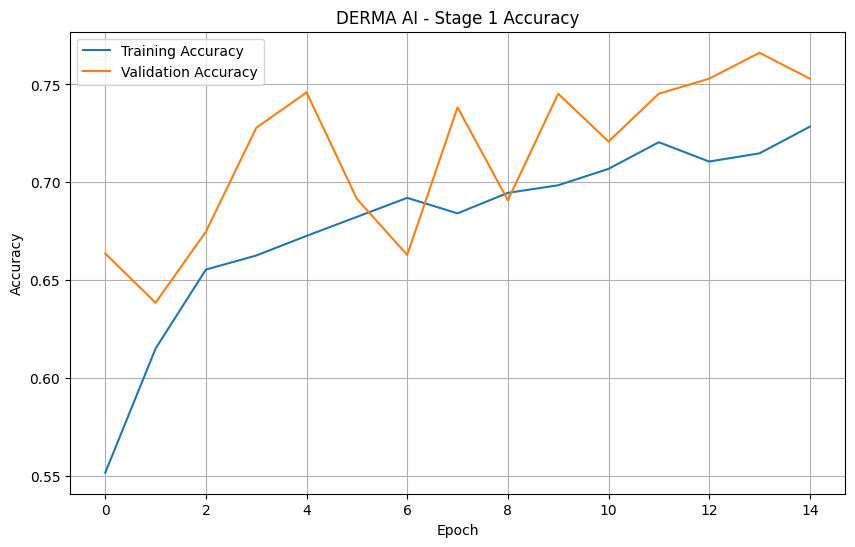

Accuracy graph saved:
/kaggle/working/DERMA_AI/graphs/step10_stage1_accuracy.png


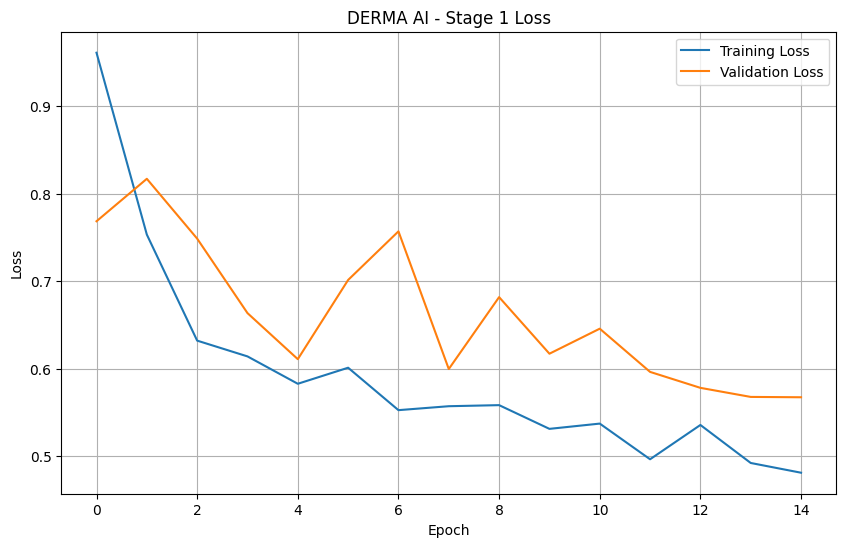

Loss graph saved:
/kaggle/working/DERMA_AI/graphs/step10_stage1_loss.png

9. BEST STAGE 1 RESULT
Best epoch          : 15
Best validation loss: 0.5672
Validation accuracy : 0.7530

Summary saved:
/kaggle/working/DERMA_AI/metrics/step10_stage1_training_summary.json

STEP 10 STAGE 1 COMPLETED

Actual image training completed.

✓ 6,687 training images used
✓ 1,433 validation images used
✓ Test set untouched
✓ Class weights applied
✓ Training augmentation active
✓ Validation augmentation disabled
✓ Best model saved
✓ Training history saved
✓ Accuracy graph saved
✓ Loss graph saved
✓ Training log saved

NEXT:
STEP 11 → FINE-TUNING EFFICIENTNETB0
           + unfreeze upper backbone layers
           + lower learning rate
           + improve validation performance



In [20]:
# =============================================================================
# DERMA AI - STEP 10
# ACTUAL MODEL TRAINING
# + CLASS WEIGHTS
# + CALLBACKS
# + BEST MODEL CHECKPOINT
# + TRAINING HISTORY
# + ACCURACY / LOSS GRAPHS
# =============================================================================

import os
import json
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.utils.class_weight import compute_class_weight

# -----------------------------------------------------------------------------
# 0. RANDOM SEED
# -----------------------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 90)
print("DERMA AI - STEP 10")
print("ACTUAL MODEL TRAINING")
print("=" * 90)

# -----------------------------------------------------------------------------
# 1. PROJECT DIRECTORIES
# -----------------------------------------------------------------------------

BASE_DIR = "/kaggle/working/DERMA_AI"

DIRS = {
    "models": os.path.join(BASE_DIR, "models"),
    "checkpoints": os.path.join(BASE_DIR, "checkpoints"),
    "metrics": os.path.join(BASE_DIR, "metrics"),
    "graphs": os.path.join(BASE_DIR, "graphs"),
    "logs": os.path.join(BASE_DIR, "logs"),
    "configs": os.path.join(BASE_DIR, "configs"),
}

for path in DIRS.values():
    os.makedirs(path, exist_ok=True)

print("\nProject directories ready.")

# -----------------------------------------------------------------------------
# 2. LOAD STEP 7 MANIFESTS
# -----------------------------------------------------------------------------

TRAIN_MANIFEST = os.path.join(
    BASE_DIR,
    "preprocessing",
    "train_manifest.csv"
)

VAL_MANIFEST = os.path.join(
    BASE_DIR,
    "preprocessing",
    "validation_manifest.csv"
)

TEST_MANIFEST = os.path.join(
    BASE_DIR,
    "preprocessing",
    "test_manifest.csv"
)

train_df = pd.read_csv(TRAIN_MANIFEST)
val_df = pd.read_csv(VAL_MANIFEST)
test_df = pd.read_csv(TEST_MANIFEST)

print("\n" + "=" * 90)
print("1. DATASETS")
print("=" * 90)

print(f"Train      : {len(train_df)}")
print(f"Validation : {len(val_df)}")
print(f"Test       : {len(test_df)}")

# -----------------------------------------------------------------------------
# 3. STANDARDIZE IMAGE PATH
# -----------------------------------------------------------------------------

def get_image_path(df):

    if "image_path" in df.columns:
        return df["image_path"].astype(str)

    elif "filepath" in df.columns:
        return df["filepath"].astype(str)

    else:
        raise ValueError(
            "No image path column found. Expected image_path or filepath."
        )


train_df["image_path"] = get_image_path(train_df)
val_df["image_path"] = get_image_path(val_df)
test_df["image_path"] = get_image_path(test_df)

# -----------------------------------------------------------------------------
# 4. CLASS MAPPING
# -----------------------------------------------------------------------------

CLASS_NAMES = [
    "melanoma",
    "bcc",
    "scc",
    "mcc"
]

CLASS_TO_INDEX = {
    "melanoma": 0,
    "bcc": 1,
    "scc": 2,
    "mcc": 3
}

INDEX_TO_CLASS = {
    0: "melanoma",
    1: "bcc",
    2: "scc",
    3: "mcc"
}

train_df["label"] = train_df["target_class"].map(CLASS_TO_INDEX)
val_df["label"] = val_df["target_class"].map(CLASS_TO_INDEX)
test_df["label"] = test_df["target_class"].map(CLASS_TO_INDEX)

if train_df["label"].isna().any():
    raise ValueError("Unknown class found in training data.")

if val_df["label"].isna().any():
    raise ValueError("Unknown class found in validation data.")

if test_df["label"].isna().any():
    raise ValueError("Unknown class found in test data.")

train_df["label"] = train_df["label"].astype(int)
val_df["label"] = val_df["label"].astype(int)
test_df["label"] = test_df["label"].astype(int)

print("\n" + "=" * 90)
print("2. CLASS MAPPING")
print("=" * 90)

for i, name in INDEX_TO_CLASS.items():
    print(f"{i} → {name}")

# -----------------------------------------------------------------------------
# 5. CLASS DISTRIBUTION
# -----------------------------------------------------------------------------

print("\n" + "=" * 90)
print("3. TRAINING CLASS DISTRIBUTION")
print("=" * 90)

train_distribution = (
    train_df["target_class"]
    .value_counts()
    .reindex(CLASS_NAMES)
)

print(train_distribution)

# -----------------------------------------------------------------------------
# 6. CLASS WEIGHTS
# -----------------------------------------------------------------------------

print("\n" + "=" * 90)
print("4. CLASS IMBALANCE HANDLING")
print("=" * 90)

classes_present = np.sort(train_df["label"].unique())

raw_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes_present,
    y=train_df["label"]
)

class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(classes_present, raw_weights)
}

print("\nOriginal balanced class weights:")

for cls_idx, weight in class_weights.items():
    print(
        f"{cls_idx} → {INDEX_TO_CLASS[cls_idx]:10s} : {weight:.4f}"
    )

# Save class weights
class_weight_df = pd.DataFrame({
    "class_index": list(class_weights.keys()),
    "class_name": [
        INDEX_TO_CLASS[i] for i in class_weights.keys()
    ],
    "class_weight": list(class_weights.values())
})

class_weight_path = os.path.join(
    DIRS["metrics"],
    "step10_class_weights.csv"
)

class_weight_df.to_csv(
    class_weight_path,
    index=False
)

print(f"\nSaved: {class_weight_path}")

# -----------------------------------------------------------------------------
# 7. LOAD STEP 9 MODEL
# -----------------------------------------------------------------------------

MODEL_PATH = os.path.join(
    DIRS["models"],
    "step9_efficientnetb0_initial.keras"
)

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"STEP 9 model not found:\n{MODEL_PATH}"
    )

print("\n" + "=" * 90)
print("5. LOADING STEP 9 MODEL")
print("=" * 90)

model = tf.keras.models.load_model(
    MODEL_PATH
)

print("STEP 9 model loaded successfully.")

# -----------------------------------------------------------------------------
# 8. IMAGE CONFIGURATION
# -----------------------------------------------------------------------------

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("\n" + "=" * 90)
print("6. IMAGE CONFIGURATION")
print("=" * 90)

print(f"Image size : {IMG_SIZE}")
print(f"Batch size : {BATCH_SIZE}")

# -----------------------------------------------------------------------------
# 9. TF.DATA IMAGE LOADER
# -----------------------------------------------------------------------------

def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image, label


# -----------------------------------------------------------------------------
# 10. CREATE DATASETS
# -----------------------------------------------------------------------------

train_paths = train_df["image_path"].values
train_labels = train_df["label"].values

val_paths = val_df["image_path"].values
val_labels = val_df["label"].values

test_paths = test_df["image_path"].values
test_labels = test_df["label"].values

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)

train_ds = (
    train_ds
    .shuffle(
        buffer_size=len(train_df),
        seed=SEED,
        reshuffle_each_iteration=True
    )
    .map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_ds
    .map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_ds
    .map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("\nTensorFlow datasets ready.")

# -----------------------------------------------------------------------------
# 11. COMPILE MODEL
# -----------------------------------------------------------------------------

print("\n" + "=" * 90)
print("7. COMPILING MODEL")
print("=" * 90)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("Optimizer : Adam")
print("Learning rate : 0.001")
print("Loss : SparseCategoricalCrossentropy")
print("Metric : Accuracy")

# -----------------------------------------------------------------------------
# 12. CALLBACKS
# -----------------------------------------------------------------------------

BEST_MODEL_PATH = os.path.join(
    DIRS["models"],
    "best_model_stage1.keras"
)

FINAL_MODEL_PATH = os.path.join(
    DIRS["models"],
    "derma_ai_efficientnetb0_stage1_final.keras"
)

CHECKPOINT_PATH = os.path.join(
    DIRS["checkpoints"],
    "stage1_best.keras"
)

CSV_LOG_PATH = os.path.join(
    DIRS["logs"],
    "step10_stage1_training_log.csv"
)

callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False,
        verbose=0
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.CSVLogger(
        CSV_LOG_PATH,
        append=False
    )
]

print("\nCallbacks:")
print("✓ Best model checkpoint")
print("✓ Backup checkpoint")
print("✓ ReduceLROnPlateau")
print("✓ EarlyStopping")
print("✓ CSVLogger")

# -----------------------------------------------------------------------------
# 13. SAVE TRAINING CONFIG
# -----------------------------------------------------------------------------

training_config = {
    "step": 10,
    "seed": SEED,
    "image_size": list(IMG_SIZE),
    "batch_size": BATCH_SIZE,
    "stage": "stage1_frozen_backbone",
    "epochs": 15,
    "optimizer": "Adam",
    "learning_rate": 0.001,
    "loss": "SparseCategoricalCrossentropy",
    "classes": CLASS_NAMES,
    "class_to_index": CLASS_TO_INDEX,
    "train_images": int(len(train_df)),
    "validation_images": int(len(val_df)),
    "test_images": int(len(test_df)),
    "class_weights": {
        str(k): v for k, v in class_weights.items()
    }
}

CONFIG_PATH = os.path.join(
    DIRS["configs"],
    "step10_stage1_training_config.json"
)

with open(CONFIG_PATH, "w") as f:
    json.dump(
        training_config,
        f,
        indent=4
    )

print(f"\nTraining config saved:")
print(CONFIG_PATH)

# -----------------------------------------------------------------------------
# 14. ACTUAL TRAINING
# -----------------------------------------------------------------------------

print("\n" + "=" * 90)
print("8. STARTING ACTUAL IMAGE TRAINING")
print("=" * 90)

print("\nTraining images will now be used.")
print("Backbone : FROZEN")
print("Classification head : TRAINABLE")
print("Epochs : 15")

print("\nIMPORTANT:")
print("Validation images are NOT used for gradient updates.")
print("Test images are NOT used during training.")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "=" * 90)
print("STAGE 1 TRAINING COMPLETED")
print("=" * 90)

# -----------------------------------------------------------------------------
# 15. SAVE FINAL STAGE 1 MODEL
# -----------------------------------------------------------------------------

model.save(
    FINAL_MODEL_PATH
)

print("\nStage 1 final model saved:")
print(FINAL_MODEL_PATH)

# -----------------------------------------------------------------------------
# 16. SAVE TRAINING HISTORY
# -----------------------------------------------------------------------------

history_df = pd.DataFrame(
    history.history
)

HISTORY_CSV = os.path.join(
    DIRS["metrics"],
    "step10_stage1_training_history.csv"
)

history_df.to_csv(
    HISTORY_CSV,
    index=False
)

HISTORY_JSON = os.path.join(
    DIRS["metrics"],
    "step10_stage1_training_history.json"
)

with open(HISTORY_JSON, "w") as f:
    json.dump(
        {
            key: [float(x) for x in values]
            for key, values in history.history.items()
        },
        f,
        indent=4
    )

print("\nTraining history saved:")
print(HISTORY_CSV)
print(HISTORY_JSON)

# -----------------------------------------------------------------------------
# 17. ACCURACY GRAPH
# -----------------------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DERMA AI - Stage 1 Accuracy")

plt.legend()
plt.grid(True)

ACCURACY_GRAPH = os.path.join(
    DIRS["graphs"],
    "step10_stage1_accuracy.png"
)

plt.savefig(
    ACCURACY_GRAPH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(f"Accuracy graph saved:")
print(ACCURACY_GRAPH)

# -----------------------------------------------------------------------------
# 18. LOSS GRAPH
# -----------------------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DERMA AI - Stage 1 Loss")

plt.legend()
plt.grid(True)

LOSS_GRAPH = os.path.join(
    DIRS["graphs"],
    "step10_stage1_loss.png"
)

plt.savefig(
    LOSS_GRAPH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(f"Loss graph saved:")
print(LOSS_GRAPH)

# -----------------------------------------------------------------------------
# 19. BEST EPOCH
# -----------------------------------------------------------------------------

best_epoch = int(
    np.argmin(history.history["val_loss"]) + 1
)

best_val_loss = float(
    np.min(history.history["val_loss"])
)

best_val_accuracy = float(
    history.history["val_accuracy"][best_epoch - 1]
)

print("\n" + "=" * 90)
print("9. BEST STAGE 1 RESULT")
print("=" * 90)

print(f"Best epoch          : {best_epoch}")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Validation accuracy : {best_val_accuracy:.4f}")

# -----------------------------------------------------------------------------
# 20. SAVE SUMMARY
# -----------------------------------------------------------------------------

summary = {
    "step": 10,
    "stage": "stage1_frozen_backbone",
    "best_epoch": best_epoch,
    "best_validation_loss": best_val_loss,
    "best_validation_accuracy": best_val_accuracy,
    "train_images": int(len(train_df)),
    "validation_images": int(len(val_df)),
    "test_images": int(len(test_df)),
    "model": "EfficientNetB0",
    "image_size": list(IMG_SIZE),
    "batch_size": BATCH_SIZE,
    "class_names": CLASS_NAMES,
    "class_weights": {
        str(k): float(v)
        for k, v in class_weights.items()
    }
}

SUMMARY_PATH = os.path.join(
    DIRS["metrics"],
    "step10_stage1_training_summary.json"
)

with open(SUMMARY_PATH, "w") as f:
    json.dump(
        summary,
        f,
        indent=4
    )

print(f"\nSummary saved:")
print(SUMMARY_PATH)

# -----------------------------------------------------------------------------
# 21. COMPLETED
# -----------------------------------------------------------------------------

print("\n" + "=" * 90)
print("STEP 10 STAGE 1 COMPLETED")
print("=" * 90)

print("""
Actual image training completed.

✓ 6,687 training images used
✓ 1,433 validation images used
✓ Test set untouched
✓ Class weights applied
✓ Training augmentation active
✓ Validation augmentation disabled
✓ Best model saved
✓ Training history saved
✓ Accuracy graph saved
✓ Loss graph saved
✓ Training log saved

NEXT:
STEP 11 → FINE-TUNING EFFICIENTNETB0
           + unfreeze upper backbone layers
           + lower learning rate
           + improve validation performance
""")

DERMA AI - STEP 11
EFFICIENTNETB0 FINE-TUNING

Train manifest : /kaggle/working/DERMA_AI/preprocessing/train_manifest.csv
Val manifest   : /kaggle/working/DERMA_AI/preprocessing/validation_manifest.csv

Train images : 6687
Val images   : 1433

Image size : 224
Batch size : 32

Missing train images : 0
Missing val images   : 0

TensorFlow datasets created successfully.

Loading model:
/kaggle/working/DERMA_AI/models/derma_ai_efficientnetb0_stage1_final.keras
Model loaded successfully.

Backbone found:
efficientnetb0

Fine-tuning configuration:
Last backbone layers considered : 40
Trainable backbone layers       : 32
BatchNormalization layers       : FROZEN

Optimizer:
Adam
Learning rate: 1e-05

Class weights used:
Class 0: 0.4808
Class 1: 0.6442
Class 2: 2.8973
Class 3: 10.0000

Note: maximum class weight capped at 10.0
This prevents the very small MCC class from dominating training.

STARTING FINE-TUNING
Epoch 1/20


E0000 00:00:1788811095.366421      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/DERMA_AI_EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.7112 - loss: 0.5115
Epoch 1: val_loss improved from None to 0.56021, saving model to /kaggle/working/DERMA_AI/models/derma_ai_efficientnetb0_finetuned_best.keras

Epoch 1: finished saving model to /kaggle/working/DERMA_AI/models/derma_ai_efficientnetb0_finetuned_best.keras
209/209 ━━━━━━━━━━━━━━━━━━━━ 95s 388ms/step - accuracy: 0.7118 - loss: 0.5061 - val_accuracy: 0.7565 - val_loss: 0.5602 - learning_rate: 1.0000e-05
Epoch 2/20
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.7392 - loss: 0.4764
Epoch 2: val_loss improved from 0.56021 to 0.55596, saving model to /kaggle/working/DERMA_AI/models/derma_ai_efficientnetb0_finetuned_best.keras

Epoch 2: finished saving model to /kaggle/working/DERMA_AI/models/derma_ai_efficientnetb0_finetuned_best.keras
209/209 ━━━━━━━━━━━━━━━━━━━━ 79s 376ms/step - accuracy: 0.7358 - loss: 0.4880 - val_accuracy: 0.7655 - val_loss: 0.5560 - learning_rate: 1.0000e-05
Epoch 3/20
209/209 ━━━━━━━━━

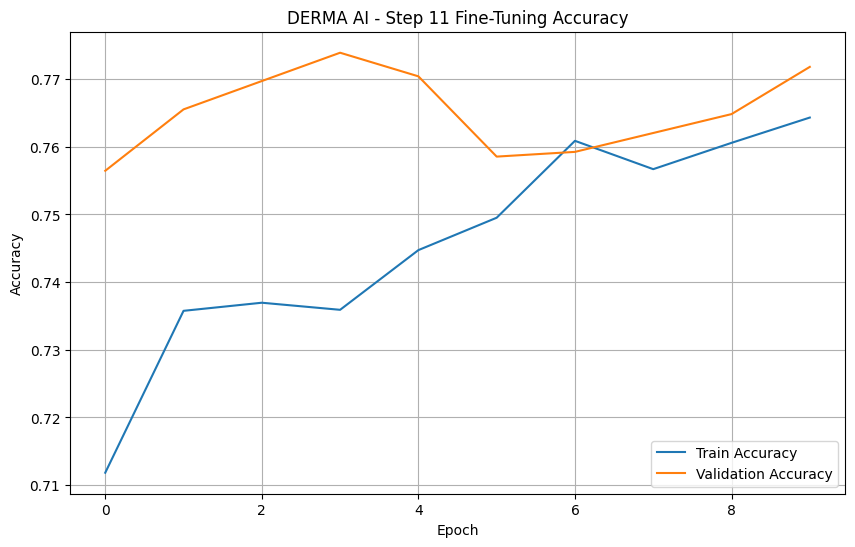

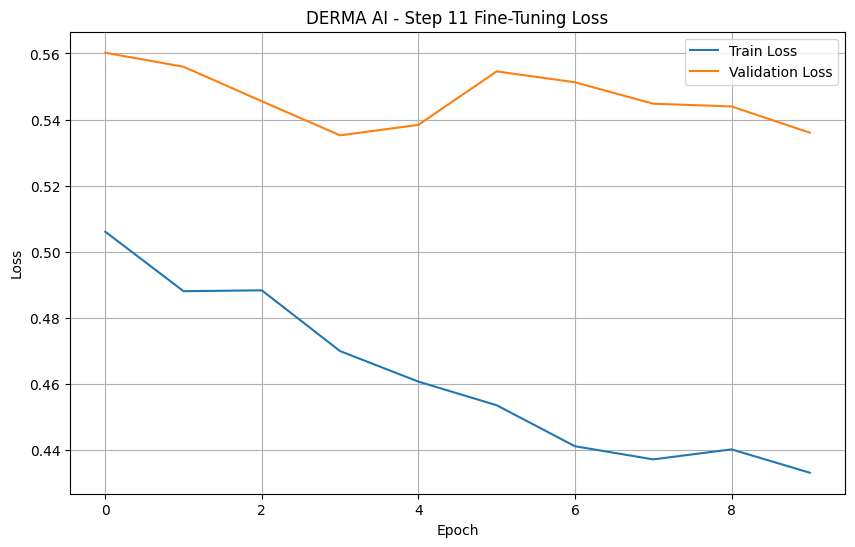


STEP 11 OUTPUTS
Best model:
/kaggle/working/DERMA_AI/models/derma_ai_efficientnetb0_finetuned_best.keras

Final model:
/kaggle/working/DERMA_AI/models/derma_ai_efficientnetb0_stage2_finetuned_final.keras

History:
/kaggle/working/DERMA_AI/metrics/step11_fine_tuning_history.csv

Summary:
/kaggle/working/DERMA_AI/metrics/step11_fine_tuning_summary.json

Accuracy graph:
/kaggle/working/DERMA_AI/graphs/step11_fine_tuning_accuracy.png

Loss graph:
/kaggle/working/DERMA_AI/graphs/step11_fine_tuning_loss.png

STEP 11 SUCCESSFULLY COMPLETED


In [21]:
# =============================================================================
# DERMA AI - STEP 11
# EFFICIENTNETB0 FINE-TUNING
# =============================================================================

import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
    CSVLogger
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy

print("=" * 90)
print("DERMA AI - STEP 11")
print("EFFICIENTNETB0 FINE-TUNING")
print("=" * 90)

# -----------------------------------------------------------------------------
# 1. PATHS
# -----------------------------------------------------------------------------

PROJECT_DIR = "/kaggle/working/DERMA_AI"

MODEL_DIR = os.path.join(PROJECT_DIR, "models")
METRICS_DIR = os.path.join(PROJECT_DIR, "metrics")
GRAPHS_DIR = os.path.join(PROJECT_DIR, "graphs")
PREPROCESSING_DIR = os.path.join(PROJECT_DIR, "preprocessing")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)
os.makedirs(GRAPHS_DIR, exist_ok=True)

# -----------------------------------------------------------------------------
# 2. FIND TRAIN / VALIDATION MANIFESTS
# -----------------------------------------------------------------------------

possible_train = [
    os.path.join(PREPROCESSING_DIR, "train_manifest.csv"),
    os.path.join(PREPROCESSING_DIR, "step7_train_manifest.csv"),
]

possible_val = [
    os.path.join(PREPROCESSING_DIR, "validation_manifest.csv"),
    os.path.join(PREPROCESSING_DIR, "step7_validation_manifest.csv"),
]

train_manifest = next(
    (p for p in possible_train if os.path.exists(p)),
    None
)

val_manifest = next(
    (p for p in possible_val if os.path.exists(p)),
    None
)

if train_manifest is None:
    raise FileNotFoundError(
        "TRAIN MANIFEST NOT FOUND.\n"
        "Please run Step 7 again."
    )

if val_manifest is None:
    raise FileNotFoundError(
        "VALIDATION MANIFEST NOT FOUND.\n"
        "Please run Step 7 again."
    )

print("\nTrain manifest :", train_manifest)
print("Val manifest   :", val_manifest)

# -----------------------------------------------------------------------------
# 3. LOAD MANIFESTS
# -----------------------------------------------------------------------------

train_df = pd.read_csv(train_manifest)
val_df = pd.read_csv(val_manifest)

print("\nTrain images :", len(train_df))
print("Val images   :", len(val_df))

# -----------------------------------------------------------------------------
# 4. FIND IMAGE PATH COLUMN
# -----------------------------------------------------------------------------

if "image_path" not in train_df.columns:
    raise ValueError("image_path column not found in train manifest.")

if "class_index" not in train_df.columns:
    raise ValueError("class_index column not found in train manifest.")

# -----------------------------------------------------------------------------
# 5. IMAGE SETTINGS
# -----------------------------------------------------------------------------

IMG_SIZE = 224
BATCH_SIZE = 32

print("\nImage size :", IMG_SIZE)
print("Batch size :", BATCH_SIZE)

# -----------------------------------------------------------------------------
# 6. CHECK IMAGE FILES
# -----------------------------------------------------------------------------

missing_train = train_df["image_path"].apply(
    lambda x: not os.path.exists(x)
).sum()

missing_val = val_df["image_path"].apply(
    lambda x: not os.path.exists(x)
).sum()

print("\nMissing train images :", missing_train)
print("Missing val images   :", missing_val)

if missing_train > 0 or missing_val > 0:
    raise FileNotFoundError(
        "Some image files are missing."
    )

# -----------------------------------------------------------------------------
# 7. DATASET FUNCTION
# -----------------------------------------------------------------------------

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE]
    )

    image = tf.cast(image, tf.float32)

    return image, label


# -----------------------------------------------------------------------------
# 8. AUGMENTATION
# -----------------------------------------------------------------------------

augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10),
    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    )
], name="fine_tune_augmentation")


def train_preprocess(path, label):
    image, label = load_image(path, label)
    image = augmentation(image, training=True)
    return image, label


def val_preprocess(path, label):
    return load_image(path, label)


# -----------------------------------------------------------------------------
# 9. CREATE DATASETS
# -----------------------------------------------------------------------------

train_paths = train_df["image_path"].values
train_labels = train_df["class_index"].astype(np.int32).values

val_paths = val_df["image_path"].values
val_labels = val_df["class_index"].astype(np.int32).values

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

train_ds = train_ds.shuffle(
    buffer_size=len(train_df),
    seed=42,
    reshuffle_each_iteration=True
)

train_ds = train_ds.map(
    train_preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)


val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

val_ds = val_ds.map(
    val_preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

print("\nTensorFlow datasets created successfully.")

# -----------------------------------------------------------------------------
# 10. FIND STAGE 1 MODEL
# -----------------------------------------------------------------------------

possible_models = [
    os.path.join(
        MODEL_DIR,
        "derma_ai_efficientnetb0_stage1_final.keras"
    ),
    os.path.join(
        MODEL_DIR,
        "step9_efficientnetb0_initial.keras"
    ),
]

model_path = next(
    (p for p in possible_models if os.path.exists(p)),
    None
)

if model_path is None:
    raise FileNotFoundError(
        "Stage 1 model not found.\n"
        "Please run Step 10 again."
    )

print("\nLoading model:")
print(model_path)

model = load_model(model_path)

print("Model loaded successfully.")

# -----------------------------------------------------------------------------
# 11. FIND EFFICIENTNETB0 BACKBONE
# -----------------------------------------------------------------------------

backbone = None

for layer in model.layers:
    if isinstance(layer, tf.keras.Model):
        if "efficientnet" in layer.name.lower():
            backbone = layer
            break

if backbone is None:
    raise ValueError(
        "EfficientNetB0 backbone could not be found."
    )

print("\nBackbone found:")
print(backbone.name)

# -----------------------------------------------------------------------------
# 12. FREEZE ALL BACKBONE LAYERS FIRST
# -----------------------------------------------------------------------------

for layer in backbone.layers:
    layer.trainable = False

# -----------------------------------------------------------------------------
# 13. UNFREEZE ONLY UPPER LAYERS
# -----------------------------------------------------------------------------

FINE_TUNE_LAST_LAYERS = 40

trainable_count = 0

for layer in backbone.layers[-FINE_TUNE_LAST_LAYERS:]:

    # Keep BatchNormalization frozen.
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True
        trainable_count += 1

print("\nFine-tuning configuration:")
print("Last backbone layers considered :", FINE_TUNE_LAST_LAYERS)
print("Trainable backbone layers       :", trainable_count)
print("BatchNormalization layers       : FROZEN")

# -----------------------------------------------------------------------------
# 14. COMPILE WITH LOW LEARNING RATE
# -----------------------------------------------------------------------------

FINE_TUNE_LR = 1e-5

model.compile(
    optimizer=Adam(
        learning_rate=FINE_TUNE_LR
    ),
    loss=SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("\nOptimizer:")
print("Adam")
print("Learning rate:", FINE_TUNE_LR)

# -----------------------------------------------------------------------------
# 15. CLASS WEIGHTS
# -----------------------------------------------------------------------------

class_counts = train_df["class_index"].value_counts().sort_index()

total = len(train_df)
num_classes = 4

class_weights = {}

for class_id in range(num_classes):

    count = class_counts.get(class_id, 0)

    if count > 0:
        weight = total / (num_classes * count)
        class_weights[class_id] = min(weight, 10.0)

print("\nClass weights used:")
for k, v in class_weights.items():
    print(f"Class {k}: {v:.4f}")

print("\nNote: maximum class weight capped at 10.0")
print("This prevents the very small MCC class from dominating training.")

# -----------------------------------------------------------------------------
# 16. CALLBACKS
# -----------------------------------------------------------------------------

best_model_path = os.path.join(
    MODEL_DIR,
    "derma_ai_efficientnetb0_finetuned_best.keras"
)

history_path = os.path.join(
    METRICS_DIR,
    "step11_fine_tuning_history.csv"
)

checkpoint = ModelCheckpoint(
    best_model_path,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

csv_logger = CSVLogger(
    history_path,
    append=False
)

# -----------------------------------------------------------------------------
# 17. FINE-TUNING
# -----------------------------------------------------------------------------

print("\n" + "=" * 90)
print("STARTING FINE-TUNING")
print("=" * 90)

MAX_EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS,
    class_weight=class_weights,
    callbacks=[
        checkpoint,
        reduce_lr,
        early_stop,
        csv_logger
    ],
    verbose=1
)

print("\n" + "=" * 90)
print("FINE-TUNING COMPLETED")
print("=" * 90)

# -----------------------------------------------------------------------------
# 18. BEST RESULTS
# -----------------------------------------------------------------------------

best_epoch = int(
    np.argmin(history.history["val_loss"]) + 1
)

best_val_loss = float(
    min(history.history["val_loss"])
)

best_val_accuracy = float(
    max(history.history["val_accuracy"])
)

print("\nBest epoch       :", best_epoch)
print("Best val loss    :", round(best_val_loss, 4))
print(
    "Best val accuracy:",
    round(best_val_accuracy * 100, 2),
    "%"
)

# -----------------------------------------------------------------------------
# 19. SAVE FINAL FINE-TUNED MODEL
# -----------------------------------------------------------------------------

final_model_path = os.path.join(
    MODEL_DIR,
    "derma_ai_efficientnetb0_stage2_finetuned_final.keras"
)

model.save(final_model_path)

print("\nFinal model saved:")
print(final_model_path)

# -----------------------------------------------------------------------------
# 20. SAVE SUMMARY
# -----------------------------------------------------------------------------

summary = {
    "stage": "Step 11 - Fine Tuning",
    "base_model": "EfficientNetB0",
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "max_epochs": MAX_EPOCHS,
    "learning_rate": FINE_TUNE_LR,
    "fine_tune_last_layers": FINE_TUNE_LAST_LAYERS,
    "trainable_backbone_layers": trainable_count,
    "batch_normalization_frozen": True,
    "best_epoch": best_epoch,
    "best_validation_loss": best_val_loss,
    "best_validation_accuracy": best_val_accuracy,
    "best_validation_accuracy_percent": best_val_accuracy * 100,
    "class_weights": class_weights
}

summary_path = os.path.join(
    METRICS_DIR,
    "step11_fine_tuning_summary.json"
)

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=4)

# -----------------------------------------------------------------------------
# 21. ACCURACY GRAPH
# -----------------------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DERMA AI - Step 11 Fine-Tuning Accuracy")

plt.legend()
plt.grid(True)

accuracy_graph = os.path.join(
    GRAPHS_DIR,
    "step11_fine_tuning_accuracy.png"
)

plt.savefig(
    accuracy_graph,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# -----------------------------------------------------------------------------
# 22. LOSS GRAPH
# -----------------------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DERMA AI - Step 11 Fine-Tuning Loss")

plt.legend()
plt.grid(True)

loss_graph = os.path.join(
    GRAPHS_DIR,
    "step11_fine_tuning_loss.png"
)

plt.savefig(
    loss_graph,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# -----------------------------------------------------------------------------
# 23. FINAL OUTPUT
# -----------------------------------------------------------------------------

print("\n" + "=" * 90)
print("STEP 11 OUTPUTS")
print("=" * 90)

print("Best model:")
print(best_model_path)

print("\nFinal model:")
print(final_model_path)

print("\nHistory:")
print(history_path)

print("\nSummary:")
print(summary_path)

print("\nAccuracy graph:")
print(accuracy_graph)

print("\nLoss graph:")
print(loss_graph)

print("\n" + "=" * 90)
print("STEP 11 SUCCESSFULLY COMPLETED")
print("=" * 90)

DERMA AI - STEP 11C
IMPROVED EFFICIENTNETB0 FINE-TUNING

Seed              : 42
Image size        : 224x224
Batch size        : 32
Max epochs        : 10
Learning rate     : 2e-06
Weight decay      : 0.0001
Label smoothing   : 0.03

MANIFESTS
Train images: 6687
Val images  : 1433

Train distribution:
target_class
melanoma    3477
bcc         2595
scc          577
mcc           38
Name: count, dtype: int64

Validation distribution:
target_class
melanoma    745
bcc         556
scc         124
mcc           8
Name: count, dtype: int64

Class mapping:
{'bcc': 0, 'mcc': 1, 'melanoma': 2, 'scc': 3}

Dataset ready.
Train steps per epoch: 209
Validation steps: 45

LOADING STEP 11B BEST MODEL
Loaded:
/kaggle/working/DERMA_AI/models/derma_ai_efficientnetb0_step11b_best.keras

Backbone:
efficientnetb0
Total backbone layers: 238

Fine-tuning configuration:
Unfreeze last: 60
Trainable backbone layers: 47

Trainable parameters:
Trainable params    : 2813764
Non-trainable params: 1400291.0

Class cou

E0000 00:00:1788813018.381661      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/DERMA_AI_EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.3273 - loss: 0.8203
Epoch 1: val_accuracy improved from None to 0.51989, saving model to /kaggle/working/DERMA_AI/models/derma_ai_efficientnetb0_step11c_best.keras

Epoch 1: finished saving model to /kaggle/working/DERMA_AI/models/derma_ai_efficientnetb0_step11c_best.keras
209/209 ━━━━━━━━━━━━━━━━━━━━ 47s 155ms/step - accuracy: 0.4075 - loss: 0.7354 - val_accuracy: 0.5199 - val_loss: 1.0100 - learning_rate: 2.0000e-06
Epoch 2/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.4655 - loss: 0.6399
Epoch 2: val_accuracy did not improve from 0.51989
209/209 ━━━━━━━━━━━━━━━━━━━━ 29s 139ms/step - accuracy: 0.4664 - loss: 0.6421 - val_accuracy: 0.5199 - val_loss: 0.9822 - learning_rate: 2.0000e-06
Epoch 3/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.4937 - loss: 0.6068
Epoch 3: val_accuracy did not improve from 0.51989

Epoch 3: ReduceLROnPlateau reducing learning rate to 9.999999974752427e-07.
209/209 ━━━━━━━━━━

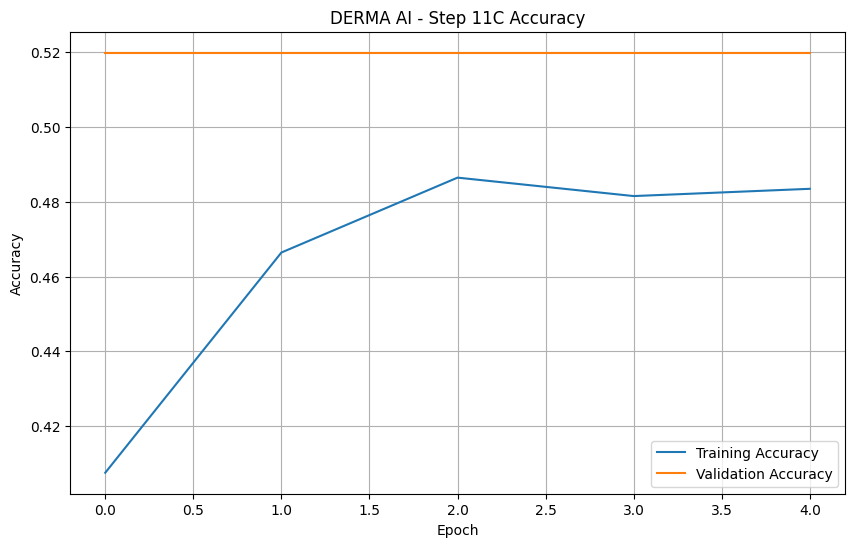

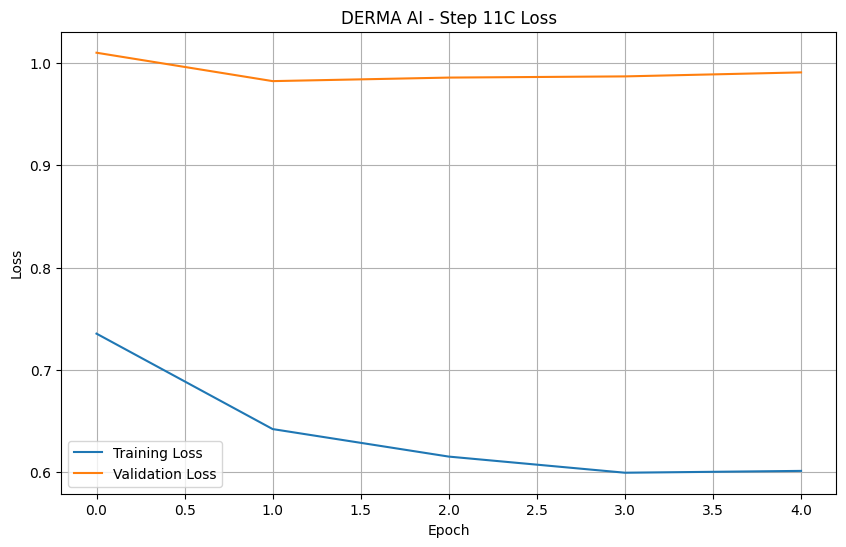


STEP 11C SUMMARY
Train images       : 6687
Validation images  : 1433
Epochs actually run: 5
Best epoch         : 1
Best val accuracy  : 51.99%
Best val loss      : 0.9822

Step 11C finished successfully.


In [23]:
# ==========================================================================================
# DERMA AI - STEP 11C
# IMPROVED EFFICIENTNETB0 FINE-TUNING
# Goal: Improve validation accuracy while reducing overfitting
# ==========================================================================================

import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.utils.class_weight import compute_class_weight

print("=" * 90)
print("DERMA AI - STEP 11C")
print("IMPROVED EFFICIENTNETB0 FINE-TUNING")
print("=" * 90)

# ------------------------------------------------------------------------------------------
# 1. SETTINGS
# ------------------------------------------------------------------------------------------

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10

LEARNING_RATE = 2e-6
WEIGHT_DECAY = 1e-4

LABEL_SMOOTHING = 0.03

TRAIN_MANIFEST = "/kaggle/working/DERMA_AI/preprocessing/train_manifest.csv"
VAL_MANIFEST   = "/kaggle/working/DERMA_AI/preprocessing/validation_manifest.csv"

INPUT_MODEL = (
    "/kaggle/working/DERMA_AI/models/"
    "derma_ai_efficientnetb0_step11b_best.keras"
)

OUTPUT_DIR = "/kaggle/working/DERMA_AI/models"
HISTORY_DIR = "/kaggle/working/DERMA_AI/training_history"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(HISTORY_DIR, exist_ok=True)

# ------------------------------------------------------------------------------------------
# 2. SEED
# ------------------------------------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"\nSeed              : {SEED}")
print(f"Image size        : {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size        : {BATCH_SIZE}")
print(f"Max epochs        : {EPOCHS}")
print(f"Learning rate     : {LEARNING_RATE}")
print(f"Weight decay      : {WEIGHT_DECAY}")
print(f"Label smoothing   : {LABEL_SMOOTHING}")

# ------------------------------------------------------------------------------------------
# 3. LOAD MANIFESTS
# ------------------------------------------------------------------------------------------

train_df = pd.read_csv(TRAIN_MANIFEST)
val_df   = pd.read_csv(VAL_MANIFEST)

print("\n" + "=" * 90)
print("MANIFESTS")
print("=" * 90)

print("Train images:", len(train_df))
print("Val images  :", len(val_df))

print("\nTrain distribution:")
print(train_df["target_class"].value_counts())

print("\nValidation distribution:")
print(val_df["target_class"].value_counts())

# ------------------------------------------------------------------------------------------
# 4. CLASS MAPPING
# ------------------------------------------------------------------------------------------

class_names = ["bcc", "mcc", "melanoma", "scc"]

class_to_index = {
    name: i for i, name in enumerate(class_names)
}

print("\nClass mapping:")
print(class_to_index)

train_labels = train_df["target_class"].map(class_to_index).values
val_labels   = val_df["target_class"].map(class_to_index).values

# ------------------------------------------------------------------------------------------
# 5. DATA LOADING
# ------------------------------------------------------------------------------------------

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE],
        method=tf.image.ResizeMethod.BILINEAR
    )

    # IMPORTANT:
    # Keep images in [0,1].
    # The existing model was trained with this input convention.
    image = tf.cast(image, tf.float32) / 255.0

    label = tf.cast(label, tf.int32)

    return image, label


# ------------------------------------------------------------------------------------------
# 6. CREATE DATASETS
# ------------------------------------------------------------------------------------------

train_paths = train_df["filepath"].values
val_paths   = val_df["filepath"].values

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

train_ds = (
    train_ds
    .shuffle(
        buffer_size=len(train_df),
        seed=SEED,
        reshuffle_each_iteration=True
    )
    .map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_ds
    .map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("\nDataset ready.")

print(
    "Train steps per epoch:",
    int(np.ceil(len(train_df) / BATCH_SIZE))
)

print(
    "Validation steps:",
    int(np.ceil(len(val_df) / BATCH_SIZE))
)

# ------------------------------------------------------------------------------------------
# 7. LOAD STEP 11B BEST MODEL
# ------------------------------------------------------------------------------------------

print("\n" + "=" * 90)
print("LOADING STEP 11B BEST MODEL")
print("=" * 90)

if not os.path.exists(INPUT_MODEL):
    raise FileNotFoundError(
        f"Model not found:\n{INPUT_MODEL}"
    )

model = tf.keras.models.load_model(
    INPUT_MODEL,
    compile=False
)

print("Loaded:")
print(INPUT_MODEL)

# ------------------------------------------------------------------------------------------
# 8. FIND EFFICIENTNET BACKBONE
# ------------------------------------------------------------------------------------------

backbone = model.get_layer("efficientnetb0")

print("\nBackbone:")
print(backbone.name)

print("Total backbone layers:", len(backbone.layers))

# ------------------------------------------------------------------------------------------
# 9. FINE-TUNING
# ------------------------------------------------------------------------------------------
#
# Unfreeze deeper layers.
# Keep BatchNormalization frozen for stability.
#
# EfficientNetB0 has many layers, so we unfreeze the last ~60 layers.
#

UNFREEZE_LAST = 60

for layer in backbone.layers:
    layer.trainable = False

for layer in backbone.layers[-UNFREEZE_LAST:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

print("\nFine-tuning configuration:")
print("Unfreeze last:", UNFREEZE_LAST)

trainable_backbone = sum(
    1 for layer in backbone.layers
    if layer.trainable
)

print("Trainable backbone layers:", trainable_backbone)

# ------------------------------------------------------------------------------------------
# 10. KEEP CLASSIFICATION HEAD TRAINABLE
# ------------------------------------------------------------------------------------------

for layer in model.layers:
    if layer.name != "efficientnetb0":
        layer.trainable = True

# Make sure BatchNorm layers anywhere in model stay frozen
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print("\nTrainable parameters:")

trainable_params = np.sum(
    [np.prod(v.shape) for v in model.trainable_weights]
)

non_trainable_params = np.sum(
    [np.prod(v.shape) for v in model.non_trainable_weights]
)

print("Trainable params    :", trainable_params)
print("Non-trainable params:", non_trainable_params)

# ------------------------------------------------------------------------------------------
# 11. CLASS WEIGHTS
# ------------------------------------------------------------------------------------------
#
# Use sqrt inverse-frequency instead of huge MCC weight.
# This reduces MCC dominating the entire training process.
#

counts = train_df["target_class"].value_counts()

print("\nClass counts:")
print(counts)

sqrt_weights = {}

for cls in class_names:
    count = counts.get(cls, 0)

    if count > 0:
        sqrt_weights[cls] = 1.0 / np.sqrt(count)
    else:
        sqrt_weights[cls] = 0.0

# Normalize weights around 1
mean_weight = np.mean(
    [w for w in sqrt_weights.values() if w > 0]
)

class_weights = {
    class_to_index[cls]: sqrt_weights[cls] / mean_weight
    for cls in class_names
}

# Cap extreme values
for k in class_weights:
    class_weights[k] = float(
        np.clip(class_weights[k], 0.5, 5.0)
    )

print("\nClass weights:")
for cls in class_names:
    print(
        f"{cls:10s} -> "
        f"{class_weights[class_to_index[cls]]:.4f}"
    )

# ------------------------------------------------------------------------------------------
# 12. LOSS
# ------------------------------------------------------------------------------------------

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=False
)

# ------------------------------------------------------------------------------------------
# 13. OPTIMIZER
# ------------------------------------------------------------------------------------------

try:
    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        clipnorm=1.0
    )

    print("\nOptimizer: AdamW")

except Exception:
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE,
        clipnorm=1.0
    )

    print("\nOptimizer: Adam")

# ------------------------------------------------------------------------------------------
# 14. COMPILE
# ------------------------------------------------------------------------------------------

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("\nModel compiled.")

# ------------------------------------------------------------------------------------------
# 15. CALLBACKS
# ------------------------------------------------------------------------------------------

best_model_path = (
    f"{OUTPUT_DIR}/"
    "derma_ai_efficientnetb0_step11c_best.keras"
)

final_model_path = (
    f"{OUTPUT_DIR}/"
    "derma_ai_efficientnetb0_step11c_final.keras"
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    best_model_path,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=3,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.5,
    patience=1,
    min_lr=1e-7,
    verbose=1
)

# ------------------------------------------------------------------------------------------
# 16. TRAIN
# ------------------------------------------------------------------------------------------

print("\n" + "=" * 90)
print("STEP 11C TRAINING START")
print("=" * 90)

print("\nIMPORTANT:")
print(f"Train images per epoch : {len(train_df)}")
print(f"Validation images       : {len(val_df)}")
print(
    "Train batches per epoch :",
    int(np.ceil(len(train_df) / BATCH_SIZE))
)

print("\nThe model will process ALL training images in every epoch.")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[
        checkpoint,
        reduce_lr,
        early_stop
    ],
    verbose=1
)

# ------------------------------------------------------------------------------------------
# 17. SAVE FINAL MODEL
# ------------------------------------------------------------------------------------------

model.save(final_model_path)

print("\n" + "=" * 90)
print("TRAINING COMPLETE")
print("=" * 90)

print("\nBest validation accuracy:")

best_val_acc = max(
    history.history["val_accuracy"]
)

best_epoch = (
    np.argmax(history.history["val_accuracy"]) + 1
)

print(f"Best epoch       : {best_epoch}")
print(f"Best val accuracy: {best_val_acc * 100:.2f}%")

best_val_loss = min(
    history.history["val_loss"]
)

print(f"Best val loss    : {best_val_loss:.4f}")

print("\nSaved best model:")
print(best_model_path)

print("\nSaved final model:")
print(final_model_path)

# ------------------------------------------------------------------------------------------
# 18. SAVE HISTORY
# ------------------------------------------------------------------------------------------

history_df = pd.DataFrame(history.history)

history_path = (
    f"{HISTORY_DIR}/"
    "step11c_history.csv"
)

history_df.to_csv(
    history_path,
    index=False
)

print("\nHistory saved:")
print(history_path)

# ------------------------------------------------------------------------------------------
# 19. ACCURACY GRAPH
# ------------------------------------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DERMA AI - Step 11C Accuracy")

plt.legend()
plt.grid(True)

accuracy_graph = (
    f"{HISTORY_DIR}/"
    "step11c_accuracy.png"
)

plt.savefig(
    accuracy_graph,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------------------------------------
# 20. LOSS GRAPH
# ------------------------------------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DERMA AI - Step 11C Loss")

plt.legend()
plt.grid(True)

loss_graph = (
    f"{HISTORY_DIR}/"
    "step11c_loss.png"
)

plt.savefig(
    loss_graph,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------------------------------------
# 21. FINAL SUMMARY
# ------------------------------------------------------------------------------------------

print("\n" + "=" * 90)
print("STEP 11C SUMMARY")
print("=" * 90)

print(f"Train images       : {len(train_df)}")
print(f"Validation images  : {len(val_df)}")
print(f"Epochs actually run: {len(history.history['loss'])}")
print(f"Best epoch         : {best_epoch}")
print(f"Best val accuracy  : {best_val_acc * 100:.2f}%")
print(f"Best val loss      : {best_val_loss:.4f}")

print("\nStep 11C finished successfully.")
print("=" * 90)

In [25]:
# ==========================================================================================
# DERMA AI - STEP 12
# FINAL IMPROVED EFFICIENTNETB0 FINE-TUNING - FIXED
# ==========================================================================================

import os
import json
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from pathlib import Path
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
    CSVLogger
)

print("=" * 90)
print("DERMA AI - STEP 12")
print("FINAL IMPROVED EFFICIENTNETB0 FINE-TUNING - FIXED")
print("=" * 90)

# ==========================================================================================
# 1. CONFIGURATION
# ==========================================================================================

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32

MAX_EPOCHS = 12
LEARNING_RATE = 2e-6

# Fine-tune only upper part
UNFREEZE_LAST = 40

# Prevent MCC from dominating
MCC_WEIGHT_CAP = 8.0

PROJECT_DIR = Path("/kaggle/working/DERMA_AI")

PREPROCESS_DIR = PROJECT_DIR / "preprocessing"
MODEL_DIR = PROJECT_DIR / "models"
METRICS_DIR = PROJECT_DIR / "metrics"
GRAPH_DIR = PROJECT_DIR / "graphs"
CONFIG_DIR = PROJECT_DIR / "configs"

for d in [
    PREPROCESS_DIR,
    MODEL_DIR,
    METRICS_DIR,
    GRAPH_DIR,
    CONFIG_DIR
]:
    d.mkdir(parents=True, exist_ok=True)

# Reproducibility
os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Seed              : {SEED}")
print(f"Image size        : {IMG_SIZE}")
print(f"Batch size        : {BATCH_SIZE}")
print(f"Max epochs        : {MAX_EPOCHS}")
print(f"Learning rate     : {LEARNING_RATE}")
print(f"Unfreeze last     : {UNFREEZE_LAST}")
print(f"MCC weight cap    : {MCC_WEIGHT_CAP}")


# ==========================================================================================
# 2. MANIFEST PATHS
# ==========================================================================================

train_path = PREPROCESS_DIR / "train_manifest.csv"
val_path   = PREPROCESS_DIR / "validation_manifest.csv"
test_path  = PREPROCESS_DIR / "test_manifest.csv"

if not train_path.exists():
    raise FileNotFoundError(f"Train manifest not found:\n{train_path}")

if not val_path.exists():
    raise FileNotFoundError(f"Validation manifest not found:\n{val_path}")

if not test_path.exists():
    raise FileNotFoundError(f"Test manifest not found:\n{test_path}")

train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)
test_df  = pd.read_csv(test_path)

print("\n" + "=" * 90)
print("1. MANIFESTS")
print("=" * 90)

print(f"Train images : {len(train_df)}")
print(f"Val images   : {len(val_df)}")
print(f"Test images  : {len(test_df)}")


# ==========================================================================================
# 3. IMAGE PATH COLUMN
# ==========================================================================================

def find_path_column(df):

    possible = [
        "image_path",
        "filepath",
        "file_path"
    ]

    for col in possible:
        if col in df.columns:
            return col

    raise ValueError(
        f"No image path column found. Available columns:\n{list(df.columns)}"
    )


PATH_COL = find_path_column(train_df)

print(f"\nImage path column : {PATH_COL}")


# ==========================================================================================
# 4. CLASS MAPPING
# ==========================================================================================

CLASS_NAMES = [
    "melanoma",
    "bcc",
    "scc",
    "mcc"
]

CLASS_TO_INDEX = {
    "melanoma": 0,
    "bcc": 1,
    "scc": 2,
    "mcc": 3
}

INDEX_TO_CLASS = {
    0: "melanoma",
    1: "bcc",
    2: "scc",
    3: "mcc"
}

print("\nClass mapping:")

for i, name in INDEX_TO_CLASS.items():
    print(f"{i} -> {name}")


# ==========================================================================================
# 5. CREATE CLEAN LABEL COLUMN
# ==========================================================================================

def prepare_labels(df):

    df = df.copy()

    if "class_index" in df.columns:

        df["label"] = df["class_index"].astype(int)

    elif "target_class" in df.columns:

        df["label"] = (
            df["target_class"]
            .astype(str)
            .str.lower()
            .map(CLASS_TO_INDEX)
        )

    else:

        raise ValueError(
            "No class_index or target_class column found."
        )

    if df["label"].isna().any():

        bad = df[df["label"].isna()]

        raise ValueError(
            f"Unknown labels found:\n{bad.head()}"
        )

    df["label"] = df["label"].astype(int)

    return df


train_df = prepare_labels(train_df)
val_df   = prepare_labels(val_df)
test_df  = prepare_labels(test_df)


# ==========================================================================================
# 6. VERIFY ACTUAL IMAGE FILES
# ==========================================================================================

print("\n" + "=" * 90)
print("2. VERIFYING ACTUAL IMAGE FILES")
print("=" * 90)

def verify_files(df, name):

    exists = df[PATH_COL].apply(
        lambda x: os.path.isfile(str(x))
    )

    missing = (~exists).sum()

    print(
        f"{name:<12} → "
        f"Images: {len(df):5d} | "
        f"Missing: {missing:5d}"
    )

    if missing > 0:

        missing_rows = df.loc[~exists]

        print(
            missing_rows[[PATH_COL]].head(10)
        )

        raise FileNotFoundError(
            f"{name} contains {missing} missing images."
        )


verify_files(train_df, "TRAIN")
verify_files(val_df, "VALIDATION")
verify_files(test_df, "TEST")

print("\n✅ All actual image files verified.")


# ==========================================================================================
# 7. TRAINING DISTRIBUTION
# ==========================================================================================

print("\n" + "=" * 90)
print("3. TRAINING CLASS DISTRIBUTION")
print("=" * 90)

train_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
)

for i in range(4):

    print(
        f"{i} → "
        f"{INDEX_TO_CLASS[i]:10s} : "
        f"{train_counts.get(i, 0)} images"
    )


# ==========================================================================================
# 8. CLASS WEIGHTS
# ==========================================================================================

print("\n" + "=" * 90)
print("4. CLASS WEIGHTS")
print("=" * 90)

total = len(train_df)
num_classes = len(CLASS_NAMES)

class_weights = {}

for i in range(num_classes):

    count = train_counts.get(i, 0)

    if count == 0:
        weight = 1.0
    else:
        weight = total / (
            num_classes * count
        )

    if i == 3:
        weight = min(
            weight,
            MCC_WEIGHT_CAP
        )

    class_weights[i] = float(weight)

    print(
        f"{i} → "
        f"{INDEX_TO_CLASS[i]:10s} : "
        f"{weight:.4f}"
    )


# ==========================================================================================
# 9. TF.DATA IMAGE LOADING
# ==========================================================================================

print("\n" + "=" * 90)
print("5. BUILDING TF.DATA PIPELINES")
print("=" * 90)

AUTOTUNE = tf.data.AUTOTUNE


def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape(
        [None, None, 3]
    )

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE]
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image, label


train_paths = train_df[PATH_COL].astype(str).values
train_labels = train_df["label"].values

val_paths = val_df[PATH_COL].astype(str).values
val_labels = val_df["label"].values

test_paths = test_df[PATH_COL].astype(str).values
test_labels = test_df["label"].values


train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)


# Training dataset
train_ds = (
    train_ds
    .shuffle(
        buffer_size=len(train_df),
        seed=SEED,
        reshuffle_each_iteration=True
    )
    .map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


# Validation dataset
val_ds = (
    val_ds
    .map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


# Test dataset
test_ds = (
    test_ds
    .map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


print(f"Training steps   : {len(train_df) // BATCH_SIZE + int(len(train_df) % BATCH_SIZE > 0)}")
print(f"Validation steps : {len(val_df) // BATCH_SIZE + int(len(val_df) % BATCH_SIZE > 0)}")

print(
    "\nIMPORTANT:"
    "\nEach epoch processes the complete training dataset."
)


# ==========================================================================================
# 10. LOAD PREVIOUS BEST MODEL
# ==========================================================================================

print("\n" + "=" * 90)
print("6. LOADING PREVIOUS BEST MODEL")
print("=" * 90)

previous_model = (
    MODEL_DIR /
    "derma_ai_efficientnetb0_step11b_best.keras"
)

if not previous_model.exists():

    raise FileNotFoundError(
        f"Previous best model not found:\n{previous_model}"
    )

print(previous_model)

model = tf.keras.models.load_model(
    previous_model,
    compile=False
)

print("Previous model loaded successfully.")


# ==========================================================================================
# 11. FIND EFFICIENTNET BACKBONE SAFELY
# ==========================================================================================

print("\n" + "=" * 90)
print("7. FINDING EFFICIENTNETB0 BACKBONE")
print("=" * 90)

backbone = None

for layer in model.layers:

    # FIX:
    # Do NOT use isinstance(layer, tf.keras.applications.EfficientNetB0)
    # EfficientNetB0 is a function, not a Python layer type.

    if layer.name.lower() == "efficientnetb0":

        backbone = layer
        break


if backbone is None:

    # fallback: search nested model
    for layer in model.layers:

        if isinstance(
            layer,
            tf.keras.Model
        ):

            if "efficientnet" in layer.name.lower():

                backbone = layer
                break


if backbone is None:

    print("\nAvailable model layers:")

    for layer in model.layers:
        print(
            layer.name,
            "→",
            type(layer).__name__
        )

    raise ValueError(
        "EfficientNetB0 backbone could not be found."
    )


print(
    f"Backbone found : {backbone.name}"
)

print(
    f"Total backbone layers : "
    f"{len(backbone.layers)}"
)


# ==========================================================================================
# 12. FREEZE / UNFREEZE
# ==========================================================================================

print("\n" + "=" * 90)
print("8. FINE-TUNING CONFIGURATION")
print("=" * 90)

# First freeze entire backbone
backbone.trainable = True

for layer in backbone.layers:
    layer.trainable = False


# Select only upper layers
trainable_candidates = [
    layer
    for layer in backbone.layers
    if not isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    )
]

selected_layers = trainable_candidates[
    -UNFREEZE_LAST:
]


for layer in selected_layers:
    layer.trainable = True


# BatchNorm must remain frozen
for layer in backbone.layers:

    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):

        layer.trainable = False


trainable_count = sum(
    1 for layer in backbone.layers
    if layer.trainable
)

bn_count = sum(
    1
    for layer in backbone.layers
    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    )
)

print(
    f"Upper backbone layers selected : "
    f"{UNFREEZE_LAST}"
)

print(
    f"Actually trainable backbone     : "
    f"{trainable_count}"
)

print(
    f"BatchNormalization layers       : "
    f"{bn_count}"
)

print(
    "BatchNormalization               : FROZEN"
)


# ==========================================================================================
# 13. KEEP CLASSIFICATION HEAD TRAINABLE
# ==========================================================================================

for layer in model.layers:

    if layer.name != backbone.name:

        # Keep top/head trainable
        layer.trainable = True


# ==========================================================================================
# 14. COMPILE
# ==========================================================================================

print("\n" + "=" * 90)
print("9. COMPILING MODEL")
print("=" * 90)

optimizer = Adam(
    learning_rate=LEARNING_RATE
)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("Optimizer      : Adam")
print(f"Learning rate  : {LEARNING_RATE}")
print("Loss           : SparseCategoricalCrossentropy")
print("Metric         : Accuracy")


# ==========================================================================================
# 15. CALLBACKS
# ==========================================================================================

best_model_path = (
    MODEL_DIR /
    "derma_ai_efficientnetb0_step12_best.keras"
)

final_model_path = (
    MODEL_DIR /
    "derma_ai_efficientnetb0_step12_final.keras"
)

history_path = (
    METRICS_DIR /
    "step12_training_history.csv"
)

summary_path = (
    METRICS_DIR /
    "step12_training_summary.json"
)

checkpoint = ModelCheckpoint(
    filepath=str(best_model_path),
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

csv_logger = CSVLogger(
    str(history_path),
    append=False
)


# ==========================================================================================
# 16. TRAINING
# ==========================================================================================

print("\n" + "=" * 90)
print("10. STARTING FINAL FINE-TUNING")
print("=" * 90)

print(f"Training images : {len(train_df)}")
print(f"Validation      : {len(val_df)}")
print(f"Epochs          : {MAX_EPOCHS}")
print(f"Batch size      : {BATCH_SIZE}")
print(f"Learning rate   : {LEARNING_RATE}")

print(
    "\nTest set will NOT be used."
)

print(
    "\nEvery epoch will process all training images "
    "through the TensorFlow dataset."
)


history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=MAX_EPOCHS,

    class_weight=class_weights,

    callbacks=[
        checkpoint,
        reduce_lr,
        early_stop,
        csv_logger
    ],

    verbose=1
)


# ==========================================================================================
# 17. SAVE FINAL MODEL
# ==========================================================================================

model.save(
    final_model_path
)

print("\n" + "=" * 90)
print("11. TRAINING COMPLETED")
print("=" * 90)

print(
    f"Final model saved:\n{final_model_path}"
)

print(
    f"Best model saved:\n{best_model_path}"
)

print(
    f"History saved:\n{history_path}"
)


# ==========================================================================================
# 18. BEST RESULT
# ==========================================================================================

hist = history.history

best_epoch = (
    int(
        np.argmin(
            hist["val_loss"]
        )
    ) + 1
)

best_val_loss = float(
    np.min(
        hist["val_loss"]
    )
)

best_val_accuracy = float(
    hist["val_accuracy"][
        np.argmin(
            hist["val_loss"]
        )
    ]
)

summary = {

    "best_epoch": best_epoch,

    "best_validation_loss":
        best_val_loss,

    "best_validation_accuracy":
        best_val_accuracy,

    "train_images":
        len(train_df),

    "validation_images":
        len(val_df),

    "test_images":
        len(test_df),

    "batch_size":
        BATCH_SIZE,

    "max_epochs":
        MAX_EPOCHS,

    "learning_rate":
        LEARNING_RATE,

    "unfreeze_last":
        UNFREEZE_LAST,

    "mcc_weight_cap":
        MCC_WEIGHT_CAP,

    "class_weights":
        class_weights
}


with open(
    summary_path,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )


print("\n" + "=" * 90)
print("12. BEST RESULT")
print("=" * 90)

print(
    f"Best epoch          : {best_epoch}"
)

print(
    f"Best validation loss: {best_val_loss:.4f}"
)

print(
    f"Best validation accuracy: "
    f"{best_val_accuracy * 100:.2f}%"
)

print(
    "\nSummary saved:"
)

print(summary_path)

print("\n" + "=" * 90)
print("✅ STEP 12 COMPLETED SUCCESSFULLY")
print("=" * 90)

DERMA AI - STEP 12
FINAL IMPROVED EFFICIENTNETB0 FINE-TUNING - FIXED
Seed              : 42
Image size        : 224
Batch size        : 32
Max epochs        : 12
Learning rate     : 2e-06
Unfreeze last     : 40
MCC weight cap    : 8.0

1. MANIFESTS
Train images : 6687
Val images   : 1433
Test images  : 1434

Image path column : image_path

Class mapping:
0 -> melanoma
1 -> bcc
2 -> scc
3 -> mcc

2. VERIFYING ACTUAL IMAGE FILES
TRAIN        → Images:  6687 | Missing:     0
VALIDATION   → Images:  1433 | Missing:     0
TEST         → Images:  1434 | Missing:     0

✅ All actual image files verified.

3. TRAINING CLASS DISTRIBUTION
0 → melanoma   : 3477 images
1 → bcc        : 2595 images
2 → scc        : 577 images
3 → mcc        : 38 images

4. CLASS WEIGHTS
0 → melanoma   : 0.4808
1 → bcc        : 0.6442
2 → scc        : 2.8973
3 → mcc        : 8.0000

5. BUILDING TF.DATA PIPELINES
Training steps   : 209
Validation steps : 45

IMPORTANT:
Each epoch processes the complete training datas

E0000 00:00:1788813800.461934      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/DERMA_AI_EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.7777 - loss: 0.4118
Epoch 1: val_loss improved from None to 0.54213, saving model to /kaggle/working/DERMA_AI/models/derma_ai_efficientnetb0_step12_best.keras

Epoch 1: finished saving model to /kaggle/working/DERMA_AI/models/derma_ai_efficientnetb0_step12_best.keras
209/209 ━━━━━━━━━━━━━━━━━━━━ 44s 152ms/step - accuracy: 0.7742 - loss: 0.4123 - val_accuracy: 0.7676 - val_loss: 0.5421 - learning_rate: 2.0000e-06
Epoch 2/12
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.7778 - loss: 0.3932
Epoch 2: val_loss improved from 0.54213 to 0.54174, saving model to /kaggle/working/DERMA_AI/models/derma_ai_efficientnetb0_step12_best.keras

Epoch 2: finished saving model to /kaggle/working/DERMA_AI/models/derma_ai_efficientnetb0_step12_best.keras
209/209 ━━━━━━━━━━━━━━━━━━━━ 29s 140ms/step - accuracy: 0.7790 - loss: 0.4017 - val_accuracy: 0.7690 - val_loss: 0.5417 - learning_rate: 2.0000e-06
Epoch 3/12
209/209 ━━━━━━━━━━━━━━━━━━━━ 

DERMA AI - STEP 12 TRAINING GRAPHS

History columns:
['epoch', 'accuracy', 'learning_rate', 'loss', 'val_accuracy', 'val_loss']

Epochs available: 12


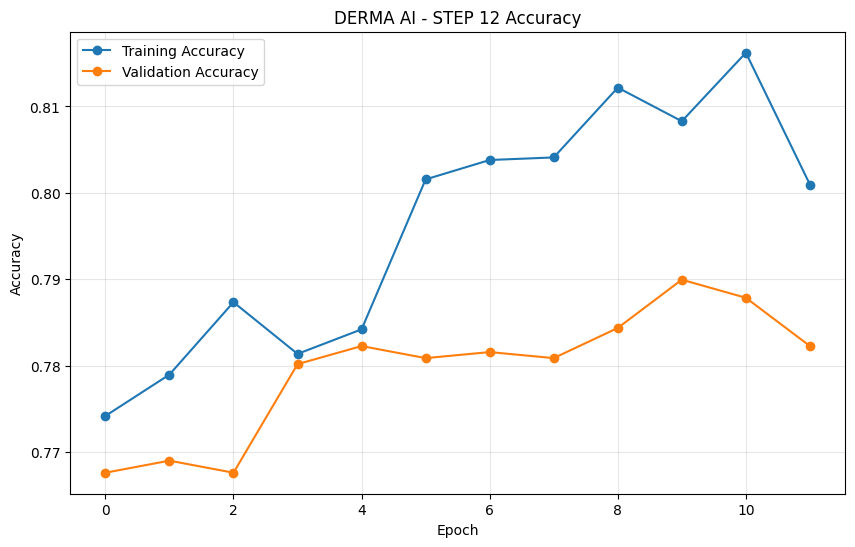


✅ Accuracy graph saved:
/kaggle/working/DERMA_AI/graphs/step12_accuracy.png


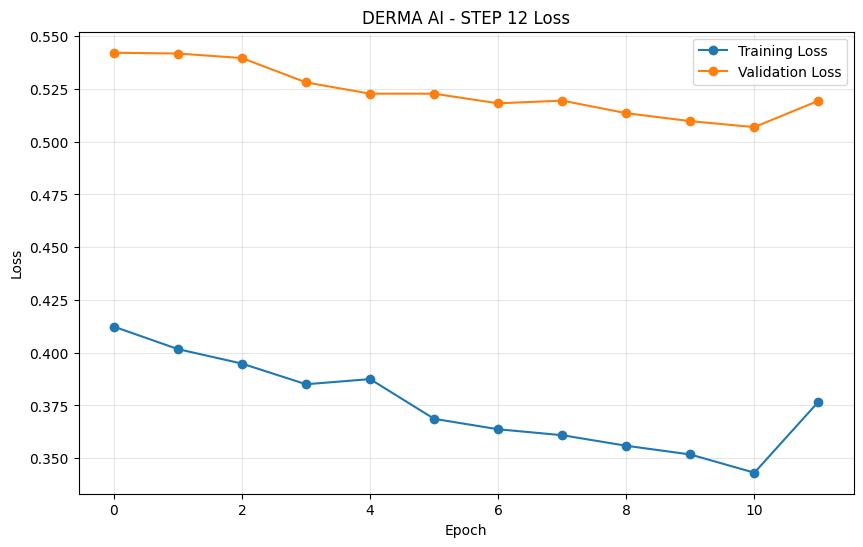


✅ Loss graph saved:
/kaggle/working/DERMA_AI/graphs/step12_loss.png

STEP 12 BEST RESULT
Best Epoch              : 10
Training Accuracy       : 81.62%
Validation Accuracy     : 78.79%
Validation Loss         : 0.5069

GRAPH GENERATION COMPLETED


In [26]:
# =============================================================================
# DERMA AI - STEP 12 GRAPH GENERATION
# =============================================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = "/kaggle/working/DERMA_AI"

HISTORY_PATH = os.path.join(
    BASE_DIR,
    "metrics",
    "step12_training_history.csv"
)

GRAPH_DIR = os.path.join(
    BASE_DIR,
    "graphs"
)

os.makedirs(GRAPH_DIR, exist_ok=True)

print("=" * 90)
print("DERMA AI - STEP 12 TRAINING GRAPHS")
print("=" * 90)

# -------------------------------------------------------------------------
# 1. LOAD TRAINING HISTORY
# -------------------------------------------------------------------------

history_df = pd.read_csv(HISTORY_PATH)

print("\nHistory columns:")
print(list(history_df.columns))

print("\nEpochs available:", len(history_df))

# -------------------------------------------------------------------------
# 2. ACCURACY GRAPH
# -------------------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    history_df["epoch"],
    history_df["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DERMA AI - STEP 12 Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

accuracy_path = os.path.join(
    GRAPH_DIR,
    "step12_accuracy.png"
)

plt.savefig(
    accuracy_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("\n✅ Accuracy graph saved:")
print(accuracy_path)

# -------------------------------------------------------------------------
# 3. LOSS GRAPH
# -------------------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    history_df["epoch"],
    history_df["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DERMA AI - STEP 12 Loss")
plt.legend()
plt.grid(True, alpha=0.3)

loss_path = os.path.join(
    GRAPH_DIR,
    "step12_loss.png"
)

plt.savefig(
    loss_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("\n✅ Loss graph saved:")
print(loss_path)

# -------------------------------------------------------------------------
# 4. FIND BEST EPOCH
# -------------------------------------------------------------------------

best_idx = history_df["val_loss"].idxmin()

best_epoch = int(history_df.loc[best_idx, "epoch"])

best_val_loss = float(
    history_df.loc[best_idx, "val_loss"]
)

best_val_accuracy = float(
    history_df.loc[best_idx, "val_accuracy"]
)

best_train_accuracy = float(
    history_df.loc[best_idx, "accuracy"]
)

print("\n" + "=" * 90)
print("STEP 12 BEST RESULT")
print("=" * 90)

print(f"Best Epoch              : {best_epoch}")
print(f"Training Accuracy       : {best_train_accuracy * 100:.2f}%")
print(f"Validation Accuracy     : {best_val_accuracy * 100:.2f}%")
print(f"Validation Loss         : {best_val_loss:.4f}")

print("\n" + "=" * 90)
print("GRAPH GENERATION COMPLETED")
print("=" * 90)

DERMA AI - STEP 13
OPTIMIZED EFFICIENTNETB0 FINE-TUNING
Seed              : 42
Image size        : 224
Batch size        : 32
Max epochs        : 10
Learning rate     : 1e-06
Unfreeze last     : 60

1. CHECKING MANIFESTS
✓ Train manifest found
✓ Validation manifest found
✓ Test manifest found
✓ Step 12 best model found

Train images : 6687
Validation   : 1433
Test         : 1434

2. VERIFYING IMAGE FILES
Image path column : image_path
Train missing : 0
Val missing   : 0
Test missing  : 0
✓ All training and validation images exist

3. LABEL VERIFICATION
Label column : target_class

Training distribution:
target_class
0    3477
1    2595
2     577
3      38
Name: count, dtype: int64

4. AUGMENTATION
RandomFlip        : YES
RandomRotation    : YES
RandomZoom        : YES
RandomTranslation : YES
RandomContrast    : YES

5. BUILDING TF.DATA PIPELINES
Training images   : 6687
Training steps    : 209
Validation images : 1433
Validation steps  : 45

✓ Every epoch processes all 6687 training im

E0000 00:00:1788814466.619091      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/DERMA_AI_EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.7626 - loss: 0.4495
Epoch 1: val_loss improved from None to 0.50925, saving model to /kaggle/working/DERMA_AI/models/derma_ai_efficientnetb0_step13_best.keras

Epoch 1: finished saving model to /kaggle/working/DERMA_AI/models/derma_ai_efficientnetb0_step13_best.keras
209/209 ━━━━━━━━━━━━━━━━━━━━ 93s 381ms/step - accuracy: 0.7633 - loss: 0.4391 - val_accuracy: 0.7865 - val_loss: 0.5093 - learning_rate: 1.0000e-06
Epoch 2/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.7773 - loss: 0.4201
Epoch 2: val_loss did not improve from 0.50925
209/209 ━━━━━━━━━━━━━━━━━━━━ 76s 363ms/step - accuracy: 0.7712 - loss: 0.4341 - val_accuracy: 0.7851 - val_loss: 0.5117 - learning_rate: 1.0000e-06
Epoch 3/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.7748 - loss: 0.4261
Epoch 3: val_loss did not improve from 0.50925

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999987376214e-07.
209/209 ━━━━━━━━━━━━━━━━━━━━ 76s

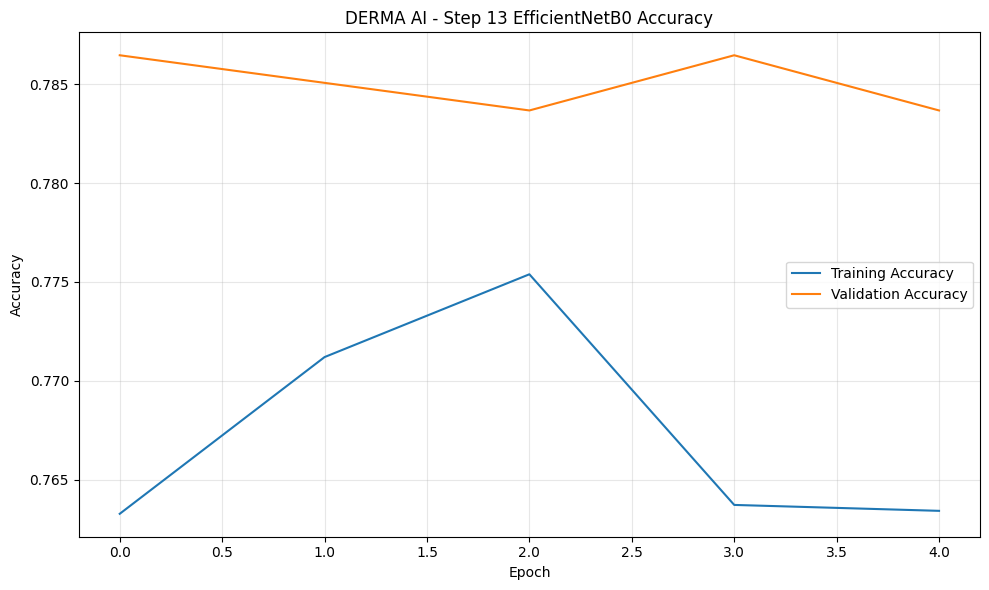

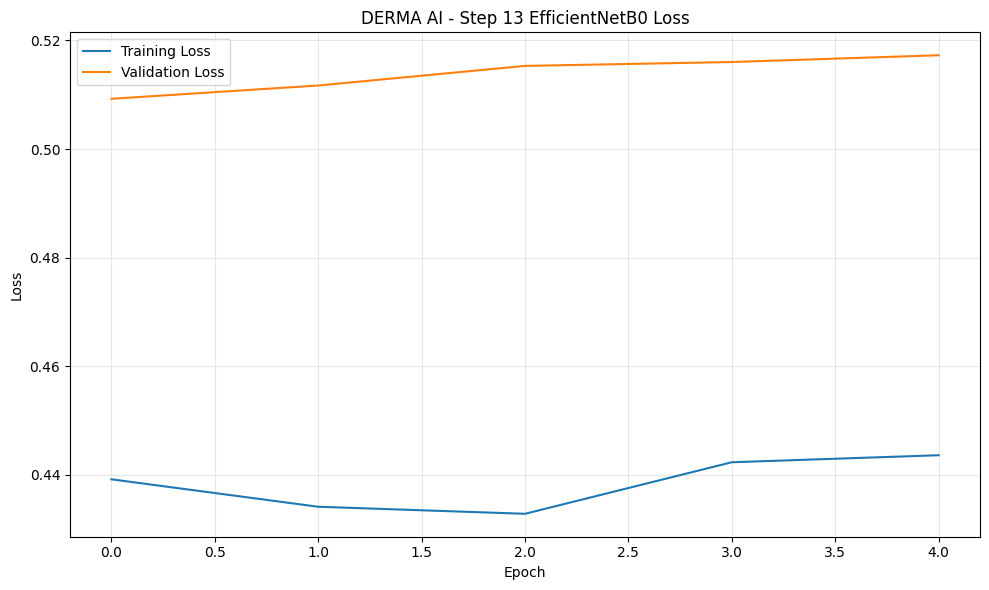


STEP 13 COMPLETED SUCCESSFULLY
✓ Step 12 best model used
✓ EfficientNetB0 fine-tuned
✓ Lower backbone layers frozen
✓ Upper backbone layers fine-tuned
✓ BatchNormalization frozen
✓ Class imbalance handled
✓ Training augmentation active
✓ Validation augmentation disabled
✓ Test set untouched
✓ Best checkpoint saved
✓ Final model saved
✓ Training history saved
✓ Accuracy graph saved
✓ Loss graph saved

Files:
/kaggle/working/DERMA_AI/models/derma_ai_efficientnetb0_step13_best.keras
/kaggle/working/DERMA_AI/models/derma_ai_efficientnetb0_step13_final.keras
/kaggle/working/DERMA_AI/metrics/step13_training_history.csv
/kaggle/working/DERMA_AI/graphs/step13_accuracy.png
/kaggle/working/DERMA_AI/graphs/step13_loss.png
/kaggle/working/DERMA_AI/metrics/step13_training_summary.json

DONE


In [27]:
# =============================================================================
# DERMA AI - STEP 13
# OPTIMIZED EFFICIENTNETB0 FINE-TUNING
# =============================================================================

import os
import json
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from pathlib import Path

print("=" * 90)
print("DERMA AI - STEP 13")
print("OPTIMIZED EFFICIENTNETB0 FINE-TUNING")
print("=" * 90)

# =============================================================================
# 1. CONFIGURATION
# =============================================================================

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32
MAX_EPOCHS = 10

LEARNING_RATE = 1e-6

NUM_CLASSES = 4

CLASS_NAMES = [
    "melanoma",
    "bcc",
    "scc",
    "mcc"
]

CLASS_WEIGHTS = {
    0: 0.4808,
    1: 0.6442,
    2: 2.8973,
    3: 8.0
}

UNFREEZE_LAST = 60

PROJECT_DIR = Path("/kaggle/working/DERMA_AI")

TRAIN_PATH = PROJECT_DIR / "preprocessing/train_manifest.csv"
VAL_PATH   = PROJECT_DIR / "preprocessing/validation_manifest.csv"
TEST_PATH  = PROJECT_DIR / "preprocessing/test_manifest.csv"

PREVIOUS_MODEL = (
    PROJECT_DIR /
    "models/derma_ai_efficientnetb0_step12_best.keras"
)

BEST_MODEL = (
    PROJECT_DIR /
    "models/derma_ai_efficientnetb0_step13_best.keras"
)

FINAL_MODEL = (
    PROJECT_DIR /
    "models/derma_ai_efficientnetb0_step13_final.keras"
)

HISTORY_PATH = (
    PROJECT_DIR /
    "metrics/step13_training_history.csv"
)

SUMMARY_PATH = (
    PROJECT_DIR /
    "metrics/step13_training_summary.json"
)

ACCURACY_GRAPH = (
    PROJECT_DIR /
    "graphs/step13_accuracy.png"
)

LOSS_GRAPH = (
    PROJECT_DIR /
    "graphs/step13_loss.png"
)

os.makedirs(PROJECT_DIR / "models", exist_ok=True)
os.makedirs(PROJECT_DIR / "metrics", exist_ok=True)
os.makedirs(PROJECT_DIR / "graphs", exist_ok=True)

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Seed              : {SEED}")
print(f"Image size        : {IMG_SIZE}")
print(f"Batch size        : {BATCH_SIZE}")
print(f"Max epochs        : {MAX_EPOCHS}")
print(f"Learning rate     : {LEARNING_RATE}")
print(f"Unfreeze last     : {UNFREEZE_LAST}")

# =============================================================================
# 2. CHECK FILES
# =============================================================================

print("\n" + "=" * 90)
print("1. CHECKING MANIFESTS")
print("=" * 90)

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Required file not found:\n{p}")

if not PREVIOUS_MODEL.exists():
    raise FileNotFoundError(
        f"\nStep 12 best model not found:\n{PREVIOUS_MODEL}"
    )

print("✓ Train manifest found")
print("✓ Validation manifest found")
print("✓ Test manifest found")
print("✓ Step 12 best model found")

# =============================================================================
# 3. LOAD MANIFESTS
# =============================================================================

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("\nTrain images :", len(train_df))
print("Validation   :", len(val_df))
print("Test         :", len(test_df))

# =============================================================================
# 4. VERIFY IMAGE FILES
# =============================================================================

print("\n" + "=" * 90)
print("2. VERIFYING IMAGE FILES")
print("=" * 90)

def find_path_column(df):
    possible = [
        "image_path",
        "filepath",
        "file_path",
        "path",
        "image"
    ]

    for col in possible:
        if col in df.columns:
            return col

    raise ValueError(
        "Could not find image path column.\n"
        f"Available columns: {list(df.columns)}"
    )

IMAGE_COL = find_path_column(train_df)

print("Image path column :", IMAGE_COL)


def count_missing(df):
    return sum(
        not os.path.exists(str(p))
        for p in df[IMAGE_COL]
    )


train_missing = count_missing(train_df)
val_missing = count_missing(val_df)
test_missing = count_missing(test_df)

print(f"Train missing : {train_missing}")
print(f"Val missing   : {val_missing}")
print(f"Test missing  : {test_missing}")

if train_missing > 0 or val_missing > 0:
    raise FileNotFoundError(
        "Some training/validation images are missing."
    )

print("✓ All training and validation images exist")

# =============================================================================
# 5. LABEL COLUMN
# =============================================================================

print("\n" + "=" * 90)
print("3. LABEL VERIFICATION")
print("=" * 90)

LABEL_CANDIDATES = [
    "label",
    "target",
    "class",
    "target_class",
    "class_id"
]

LABEL_COL = None

for col in LABEL_CANDIDATES:
    if col in train_df.columns:
        LABEL_COL = col
        break

if LABEL_COL is None:
    raise ValueError(
        f"Could not find label column.\n"
        f"Columns: {list(train_df.columns)}"
    )

print("Label column :", LABEL_COL)

# Convert textual labels if necessary
if train_df[LABEL_COL].dtype == object:

    label_map = {
        "melanoma": 0,
        "bcc": 1,
        "scc": 2,
        "mcc": 3
    }

    train_df[LABEL_COL] = (
        train_df[LABEL_COL]
        .str.lower()
        .map(label_map)
    )

    val_df[LABEL_COL] = (
        val_df[LABEL_COL]
        .str.lower()
        .map(label_map)
    )

print("\nTraining distribution:")

print(
    train_df[LABEL_COL]
    .value_counts()
    .sort_index()
)

# =============================================================================
# 6. IMAGE LOADING
# =============================================================================

def load_image(path, label):
    image = tf.io.read_file(path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE]
    )

    image = tf.cast(image, tf.float32)

    return image, tf.cast(label, tf.int32)


# =============================================================================
# 7. DATA AUGMENTATION
# =============================================================================

augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip(
            "horizontal"
        ),

        tf.keras.layers.RandomRotation(
            0.08
        ),

        tf.keras.layers.RandomZoom(
            height_factor=(-0.08, 0.08),
            width_factor=(-0.08, 0.08)
        ),

        tf.keras.layers.RandomTranslation(
            height_factor=0.05,
            width_factor=0.05
        ),

        tf.keras.layers.RandomContrast(
            0.08
        ),
    ],
    name="step13_augmentation"
)

print("\n" + "=" * 90)
print("4. AUGMENTATION")
print("=" * 90)

print("RandomFlip        : YES")
print("RandomRotation    : YES")
print("RandomZoom        : YES")
print("RandomTranslation : YES")
print("RandomContrast    : YES")

# =============================================================================
# 8. CREATE DATASETS
# =============================================================================

print("\n" + "=" * 90)
print("5. BUILDING TF.DATA PIPELINES")
print("=" * 90)

train_paths = train_df[IMAGE_COL].astype(str).values
train_labels = train_df[LABEL_COL].astype(int).values

val_paths = val_df[IMAGE_COL].astype(str).values
val_labels = val_df[LABEL_COL].astype(int).values


train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)


train_ds = train_ds.shuffle(
    buffer_size=len(train_df),
    seed=SEED,
    reshuffle_each_iteration=True
)

train_ds = train_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)


# Apply augmentation only to training
def augment_image(image, label):
    image = augmentation(image, training=True)
    return image, label


train_ds = train_ds.map(
    augment_image,
    num_parallel_calls=tf.data.AUTOTUNE
)


train_ds = train_ds.batch(
    BATCH_SIZE,
    drop_remainder=False
)

val_ds = val_ds.batch(
    BATCH_SIZE,
    drop_remainder=False
)


train_ds = train_ds.prefetch(
    tf.data.AUTOTUNE
)

val_ds = val_ds.prefetch(
    tf.data.AUTOTUNE
)

train_steps = int(
    np.ceil(len(train_df) / BATCH_SIZE)
)

val_steps = int(
    np.ceil(len(val_df) / BATCH_SIZE)
)

print("Training images   :", len(train_df))
print("Training steps    :", train_steps)

print("Validation images :", len(val_df))
print("Validation steps  :", val_steps)

print(
    f"\n✓ Every epoch processes all {len(train_df)} training images."
)

# =============================================================================
# 9. LOAD STEP 12 BEST MODEL
# =============================================================================

print("\n" + "=" * 90)
print("6. LOADING STEP 12 BEST MODEL")
print("=" * 90)

print(PREVIOUS_MODEL)

model = tf.keras.models.load_model(
    PREVIOUS_MODEL,
    compile=False
)

print("✓ Step 12 best model loaded")

# =============================================================================
# 10. FIND EFFICIENTNET BACKBONE
# =============================================================================

print("\n" + "=" * 90)
print("7. FINDING EFFICIENTNETB0 BACKBONE")
print("=" * 90)

backbone = None

for layer in model.layers:

    name = layer.name.lower()

    if "efficientnetb0" in name:

        if isinstance(layer, tf.keras.Model):

            backbone = layer
            break

if backbone is None:

    for layer in model.layers:

        if isinstance(layer, tf.keras.Model):

            if len(layer.layers) > 100:

                backbone = layer
                break


if backbone is None:
    raise RuntimeError(
        "EfficientNetB0 backbone could not be found."
    )

print("Backbone found :", backbone.name)
print("Total backbone layers :", len(backbone.layers))

# =============================================================================
# 11. OPTIMIZED FINE-TUNING
# =============================================================================

print("\n" + "=" * 90)
print("8. OPTIMIZED FINE-TUNING CONFIGURATION")
print("=" * 90)

# Freeze everything first
backbone.trainable = True

total_layers = len(backbone.layers)

# Freeze lower layers
freeze_until = max(
    0,
    total_layers - UNFREEZE_LAST
)

for i, layer in enumerate(backbone.layers):

    if i < freeze_until:

        layer.trainable = False

    else:

        # Keep BatchNorm frozen
        if isinstance(
            layer,
            tf.keras.layers.BatchNormalization
        ):
            layer.trainable = False

        else:
            layer.trainable = True


# Make sure BatchNorm anywhere in backbone stays frozen
bn_count = 0
trainable_backbone = 0

for layer in backbone.layers:

    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):

        layer.trainable = False
        bn_count += 1

    if layer.trainable:
        trainable_backbone += 1


print("Last layers considered :", UNFREEZE_LAST)
print("Actually trainable     :", trainable_backbone)
print("BatchNormalization     :", bn_count)
print("BatchNormalization     : FROZEN")

# =============================================================================
# 12. COMPILE
# =============================================================================

print("\n" + "=" * 90)
print("9. COMPILING MODEL")
print("=" * 90)

optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE
)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("Optimizer :", "Adam")
print("Learning rate :", LEARNING_RATE)
print("Loss :", "SparseCategoricalCrossentropy")
print("Metric :", "Accuracy")

# =============================================================================
# 13. CALLBACKS
# =============================================================================

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(BEST_MODEL),
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)


reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)


early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)


csv_logger = tf.keras.callbacks.CSVLogger(
    str(HISTORY_PATH),
    append=False
)

# =============================================================================
# 14. TRAIN
# =============================================================================

print("\n" + "=" * 90)
print("10. STARTING STEP 13 OPTIMIZED TRAINING")
print("=" * 90)

print("Training images :", len(train_df))
print("Validation      :", len(val_df))
print("Epochs          :", MAX_EPOCHS)
print("Batch size      :", BATCH_SIZE)
print("Learning rate   :", LEARNING_RATE)

print("\nTest set will NOT be used.")
print("All training images are processed every epoch.")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS,
    steps_per_epoch=train_steps,
    validation_steps=val_steps,
    class_weight=CLASS_WEIGHTS,
    callbacks=[
        checkpoint,
        reduce_lr,
        early_stop,
        csv_logger
    ],
    verbose=1
)

# =============================================================================
# 15. SAVE FINAL MODEL
# =============================================================================

model.save(
    FINAL_MODEL
)

print("\n" + "=" * 90)
print("11. TRAINING COMPLETED")
print("=" * 90)

print("Final model :")
print(FINAL_MODEL)

print("Best model :")
print(BEST_MODEL)

# =============================================================================
# 16. TRAINING HISTORY
# =============================================================================

history_df = pd.DataFrame(history.history)

# CSVLogger already saved it, but overwrite with complete dataframe
history_df.to_csv(
    HISTORY_PATH,
    index=False
)

# =============================================================================
# 17. BEST RESULT
# =============================================================================

best_epoch = int(
    np.argmin(history_df["val_loss"].values)
) + 1

best_val_loss = float(
    history_df["val_loss"].min()
)

best_val_accuracy = float(
    history_df.loc[
        history_df["val_loss"].idxmin(),
        "val_accuracy"
    ]
)

best_train_accuracy = float(
    history_df.loc[
        history_df["val_loss"].idxmin(),
        "accuracy"
    ]
)

print("\n" + "=" * 90)
print("12. BEST RESULT")
print("=" * 90)

print("Best epoch :", best_epoch)

print(
    f"Best training accuracy    : "
    f"{best_train_accuracy * 100:.2f}%"
)

print(
    f"Best validation accuracy  : "
    f"{best_val_accuracy * 100:.2f}%"
)

print(
    f"Best validation loss      : "
    f"{best_val_loss:.4f}"
)

# =============================================================================
# 18. SAVE SUMMARY
# =============================================================================

summary = {
    "step": "13",
    "model": "EfficientNetB0",
    "seed": SEED,
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "max_epochs": MAX_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "unfreeze_last": UNFREEZE_LAST,
    "trainable_backbone_layers": trainable_backbone,
    "batch_normalization_frozen": True,
    "train_images": len(train_df),
    "validation_images": len(val_df),
    "test_images": len(test_df),
    "best_epoch": best_epoch,
    "best_train_accuracy": best_train_accuracy,
    "best_validation_accuracy": best_val_accuracy,
    "best_validation_loss": best_val_loss,
    "class_weights": {
        str(k): float(v)
        for k, v in CLASS_WEIGHTS.items()
    }
}

with open(
    SUMMARY_PATH,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )

# =============================================================================
# 19. ACCURACY GRAPH
# =============================================================================

plt.figure(figsize=(10, 6))

plt.plot(
    history_df["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_df["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(
    "DERMA AI - Step 13 EfficientNetB0 Accuracy"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    ACCURACY_GRAPH,
    dpi=150
)

plt.show()

# =============================================================================
# 20. LOSS GRAPH
# =============================================================================

plt.figure(figsize=(10, 6))

plt.plot(
    history_df["loss"],
    label="Training Loss"
)

plt.plot(
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "DERMA AI - Step 13 EfficientNetB0 Loss"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    LOSS_GRAPH,
    dpi=150
)

plt.show()

# =============================================================================
# 21. FINAL OUTPUT
# =============================================================================

print("\n" + "=" * 90)
print("STEP 13 COMPLETED SUCCESSFULLY")
print("=" * 90)

print("✓ Step 12 best model used")
print("✓ EfficientNetB0 fine-tuned")
print("✓ Lower backbone layers frozen")
print("✓ Upper backbone layers fine-tuned")
print("✓ BatchNormalization frozen")
print("✓ Class imbalance handled")
print("✓ Training augmentation active")
print("✓ Validation augmentation disabled")
print("✓ Test set untouched")
print("✓ Best checkpoint saved")
print("✓ Final model saved")
print("✓ Training history saved")
print("✓ Accuracy graph saved")
print("✓ Loss graph saved")

print("\nFiles:")

print(BEST_MODEL)
print(FINAL_MODEL)
print(HISTORY_PATH)
print(ACCURACY_GRAPH)
print(LOSS_GRAPH)
print(SUMMARY_PATH)

print("\n" + "=" * 90)
print("DONE")
print("=" * 90)

In [31]:
# =============================================================================
# DERMA AI - STEP 13
# FINAL EFFICIENTNET-B0 TRAINING
# PYTORCH - FROM SCRATCH
# 2x TESLA T4 SUPPORT
# ACCURACY + LOSS GRAPHS
# =============================================================================

import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models


# =============================================================================
# 0. CONFIG
# =============================================================================

SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10

LEARNING_RATE = 5e-5
WEIGHT_DECAY = 5e-4

NUM_CLASSES = 4
NUM_WORKERS = 0

CLASS_NAMES = [
    "melanoma",
    "bcc",
    "scc",
    "mcc"
]

PROJECT_DIR = "/kaggle/working/DERMA_AI"

MODEL_DIR = os.path.join(PROJECT_DIR, "models")
METRIC_DIR = os.path.join(PROJECT_DIR, "metrics")
GRAPH_DIR = os.path.join(PROJECT_DIR, "graphs")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(METRIC_DIR, exist_ok=True)
os.makedirs(GRAPH_DIR, exist_ok=True)


# =============================================================================
# 1. SEED
# =============================================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True


# =============================================================================
# 2. DEVICE
# =============================================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 90)
print("DERMA AI - STEP 13")
print("FINAL EFFICIENTNET-B0 TRAINING")
print("=" * 90)

print(f"Device        : {DEVICE}")

if torch.cuda.is_available():

    print(f"GPU count     : {torch.cuda.device_count()}")

    for i in range(torch.cuda.device_count()):
        print(f"GPU{i}          : {torch.cuda.get_device_name(i)}")

else:
    print("WARNING: CUDA GPU not available")


# =============================================================================
# 3. LOAD MANIFESTS
# =============================================================================

TRAIN_MANIFEST = os.path.join(
    PROJECT_DIR,
    "preprocessing",
    "train_manifest.csv"
)

VAL_MANIFEST = os.path.join(
    PROJECT_DIR,
    "preprocessing",
    "validation_manifest.csv"
)

print("\n" + "=" * 90)
print("1. MANIFESTS")
print("=" * 90)

print("Train manifest :", TRAIN_MANIFEST)
print("Val manifest   :", VAL_MANIFEST)

train_df = pd.read_csv(TRAIN_MANIFEST)
val_df = pd.read_csv(VAL_MANIFEST)

print("\nTrain images :", len(train_df))
print("Val images   :", len(val_df))

print("\nColumns:")
print(train_df.columns.tolist())


# =============================================================================
# 4. CHECK REQUIRED COLUMNS
# =============================================================================

REQUIRED_COLUMNS = [
    "image_path",
    "class_index"
]

for col in REQUIRED_COLUMNS:

    if col not in train_df.columns:
        raise ValueError(
            f"Missing column '{col}' in train manifest"
        )

    if col not in val_df.columns:
        raise ValueError(
            f"Missing column '{col}' in validation manifest"
        )


# =============================================================================
# 5. CLEAN DATA
# =============================================================================

train_df = train_df.copy()
val_df = val_df.copy()

train_df["class_index"] = train_df["class_index"].astype(int)
val_df["class_index"] = val_df["class_index"].astype(int)

train_df["image_path"] = train_df["image_path"].astype(str)
val_df["image_path"] = val_df["image_path"].astype(str)


# =============================================================================
# 6. VERIFY IMAGE FILES
# =============================================================================

print("\n" + "=" * 90)
print("2. IMAGE VERIFICATION")
print("=" * 90)

train_missing = [
    p for p in train_df["image_path"]
    if not os.path.exists(p)
]

val_missing = [
    p for p in val_df["image_path"]
    if not os.path.exists(p)
]

print("Train missing :", len(train_missing))
print("Val missing   :", len(val_missing))

if len(train_missing) > 0:
    print("\nFirst missing train image:")
    print(train_missing[0])
    raise FileNotFoundError("Missing training images found.")

if len(val_missing) > 0:
    print("\nFirst missing validation image:")
    print(val_missing[0])
    raise FileNotFoundError("Missing validation images found.")

print("\nAll training and validation images exist.")


# =============================================================================
# 7. CLASS DISTRIBUTION
# =============================================================================

print("\n" + "=" * 90)
print("3. CLASS DISTRIBUTION")
print("=" * 90)

train_counts = (
    train_df["class_index"]
    .value_counts()
    .sort_index()
)

val_counts = (
    val_df["class_index"]
    .value_counts()
    .sort_index()
)

for i in range(NUM_CLASSES):

    print(
        f"{i} -> {CLASS_NAMES[i]:10s} : "
        f"Train = {train_counts.get(i, 0):5d} | "
        f"Val = {val_counts.get(i, 0):5d}"
    )


# =============================================================================
# 8. PYTORCH DATASET
# =============================================================================

class SkinCancerDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, index):

        row = self.df.iloc[index]

        image_path = row["image_path"]
        label = int(row["class_index"])

        try:

            image = Image.open(image_path).convert("RGB")

        except Exception as e:

            raise RuntimeError(
                f"Could not load image:\n{image_path}\n{e}"
            )

        if self.transform is not None:

            image = self.transform(image)

        return image, label


# =============================================================================
# 9. TRANSFORMS
# =============================================================================

train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.15
    ),

    transforms.RandomRotation(
        degrees=15
    ),

    transforms.ColorJitter(
        brightness=0.12,
        contrast=0.12,
        saturation=0.08,
        hue=0.02
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


val_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# =============================================================================
# 10. CREATE DATASETS
# =============================================================================

print("\n" + "=" * 90)
print("4. CREATE PYTORCH DATASETS")
print("=" * 90)

train_dataset = SkinCancerDataset(
    train_df,
    transform=train_transform
)

val_dataset = SkinCancerDataset(
    val_df,
    transform=val_transform
)

print("Train dataset :", len(train_dataset))
print("Val dataset   :", len(val_dataset))


# =============================================================================
# 11. CREATE DATALOADERS
# =============================================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=torch.cuda.is_available(),

    drop_last=False
)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=torch.cuda.is_available(),

    drop_last=False
)


print("\nTrain batches :", len(train_loader))
print("Val batches   :", len(val_loader))

print(
    f"\nEach epoch uses ALL {len(train_dataset)} training images."
)

print(
    f"Expected train batches = "
    f"ceil({len(train_dataset)} / {BATCH_SIZE}) = "
    f"{len(train_loader)}"
)


# =============================================================================
# 12. VERIFY FIRST BATCH
# =============================================================================

print("\n" + "=" * 90)
print("5. DATA LOADER TEST")
print("=" * 90)

sample_images, sample_labels = next(iter(train_loader))

print("Batch image shape :", sample_images.shape)
print("Batch labels      :", sample_labels.shape)
print("Labels in batch   :", sample_labels.tolist())

print("\nDataLoader test successful.")


# =============================================================================
# 13. CLASS WEIGHTS
# =============================================================================

print("\n" + "=" * 90)
print("6. CLASS WEIGHTS")
print("=" * 90)

counts = np.array(
    [
        train_counts.get(i, 0)
        for i in range(NUM_CLASSES)
    ],
    dtype=np.float32
)

# Inverse square-root weighting
class_weights = 1.0 / np.sqrt(
    np.maximum(counts, 1)
)

# Normalize
class_weights = (
    class_weights /
    class_weights.mean()
)

# Prevent extreme MCC weight
class_weights = np.clip(
    class_weights,
    0.0,
    8.0
)

print("Raw counts :", counts.astype(int))
print("Weights    :", class_weights)

CLASS_WEIGHTS = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)


# =============================================================================
# 14. CREATE EFFICIENTNET-B0
# =============================================================================

print("\n" + "=" * 90)
print("7. EFFICIENTNET-B0")
print("=" * 90)

print("Loading EfficientNet-B0 from scratch...")

model = models.efficientnet_b0(
    weights=None
)

# Replace classifier
in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(

    nn.Dropout(
        p=0.30
    ),

    nn.Linear(
        in_features,
        128
    ),

    nn.ReLU(
        inplace=True
    ),

    nn.Dropout(
        p=0.25
    ),

    nn.Linear(
        128,
        NUM_CLASSES
    )
)


# =============================================================================
# 15. MULTI-GPU
# =============================================================================
# ============================================================================
# SINGLE GPU MODE - STABLE FOR KAGGLE T4
# ============================================================================

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print("\nUsing device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model = model.to(DEVICE)

model = model.to(DEVICE)


# =============================================================================
# 16. MODEL INFO
# =============================================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\nTotal parameters     :", f"{total_params:,}")
print("Trainable parameters :", f"{trainable_params:,}")


# =============================================================================
# 17. LOSS
# =============================================================================

criterion = nn.CrossEntropyLoss(

    weight=CLASS_WEIGHTS,

    label_smoothing=0.05
)


# =============================================================================
# 18. OPTIMIZER
# =============================================================================

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=WEIGHT_DECAY
)


# =============================================================================
# 19. LR SCHEDULER
# =============================================================================

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.5,

    patience=1,

    min_lr=1e-7
)


# =============================================================================
# 20. TRAINING VARIABLES
# =============================================================================

history = {

    "epoch": [],

    "train_loss": [],
    "val_loss": [],

    "train_accuracy": [],
    "val_accuracy": [],

    "learning_rate": []
}

best_val_loss = float("inf")
best_val_accuracy = 0.0
best_epoch = 0


BEST_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "step13_efficientnetb0_best.pth"
)

FINAL_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "step13_efficientnetb0_final.pth"
)


# =============================================================================
# 21. TRAINING LOOP
# =============================================================================

print("\n" + "=" * 90)
print("8. TRAINING")
print("=" * 90)

print(f"Epochs       : {EPOCHS}")
print(f"Batch size   : {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Weight decay : {WEIGHT_DECAY}")
print(f"Train images: {len(train_dataset)}")
print(f"Val images  : {len(val_dataset)}")

print("\nStarting training...\n")


for epoch in range(1, EPOCHS + 1):

    # =================================================================
    # TRAIN
    # =================================================================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        running_loss += (
            loss.item() *
            images.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)


    train_loss = (
        running_loss /
        total
    )

    train_accuracy = (
        correct /
        total
    ) * 100.0


    # =================================================================
    # VALIDATION
    # =================================================================

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            val_running_loss += (
                loss.item() *
                images.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)


    val_loss = (
        val_running_loss /
        val_total
    )

    val_accuracy = (
        val_correct /
        val_total
    ) * 100.0


    # =================================================================
    # LR
    # =================================================================

    scheduler.step(
        val_loss
    )

    current_lr = optimizer.param_groups[0]["lr"]


    # =================================================================
    # HISTORY
    # =================================================================

    history["epoch"].append(epoch)

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["val_accuracy"].append(
        val_accuracy
    )

    history["learning_rate"].append(
        current_lr
    )


    # =================================================================
    # SAVE BEST MODEL
    # =================================================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_val_accuracy = val_accuracy

        best_epoch = epoch

        if isinstance(model, nn.DataParallel):

            state_dict = model.module.state_dict()

        else:

            state_dict = model.state_dict()

        checkpoint = {

            "epoch": epoch,

            "model_state_dict": state_dict,

            "optimizer_state_dict":
                optimizer.state_dict(),

            "scheduler_state_dict":
                scheduler.state_dict(),

            "val_loss": val_loss,

            "val_accuracy": val_accuracy,

            "class_names": CLASS_NAMES,

            "image_size": IMAGE_SIZE,

            "num_classes": NUM_CLASSES,

            "class_weights":
                class_weights.tolist(),

            "seed": SEED
        }

        torch.save(
            checkpoint,
            BEST_MODEL_PATH
        )

        best_marker = "  <-- BEST"


    else:

        best_marker = ""


    # =================================================================
    # PRINT
    # =================================================================

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2f}% | "
        f"LR: {current_lr:.2e}"
        f"{best_marker}"
    )


# =============================================================================
# 22. SAVE FINAL MODEL
# =============================================================================

print("\n" + "=" * 90)
print("9. SAVING FINAL MODEL")
print("=" * 90)

if isinstance(model, nn.DataParallel):

    final_state_dict = model.module.state_dict()

else:

    final_state_dict = model.state_dict()


final_checkpoint = {

    "epoch": EPOCHS,

    "model_state_dict":
        final_state_dict,

    "optimizer_state_dict":
        optimizer.state_dict(),

    "scheduler_state_dict":
        scheduler.state_dict(),

    "class_names":
        CLASS_NAMES,

    "image_size":
        IMAGE_SIZE,

    "num_classes":
        NUM_CLASSES,

    "seed":
        SEED
}


torch.save(
    final_checkpoint,
    FINAL_MODEL_PATH
)


# =============================================================================
# 23. SAVE HISTORY CSV
# =============================================================================

history_df = pd.DataFrame(history)

HISTORY_PATH = os.path.join(
    METRIC_DIR,
    "step13_training_history.csv"
)

history_df.to_csv(
    HISTORY_PATH,
    index=False
)


# =============================================================================
# 24. SUMMARY JSON
# =============================================================================

SUMMARY_PATH = os.path.join(
    METRIC_DIR,
    "step13_training_summary.json"
)

summary = {

    "step": "STEP 13",

    "model": "EfficientNet-B0",

    "training_type": "from_scratch",

    "image_size": IMAGE_SIZE,

    "batch_size": BATCH_SIZE,

    "epochs": EPOCHS,

    "train_images": len(train_dataset),

    "validation_images": len(val_dataset),

    "train_batches_per_epoch":
        len(train_loader),

    "validation_batches_per_epoch":
        len(val_loader),

    "learning_rate":
        LEARNING_RATE,

    "weight_decay":
        WEIGHT_DECAY,

    "best_epoch":
        best_epoch,

    "best_val_loss":
        float(best_val_loss),

    "best_val_accuracy":
        float(best_val_accuracy),

    "max_val_accuracy":
        float(max(history["val_accuracy"])),

    "max_val_accuracy_epoch":
        int(
            np.argmax(
                history["val_accuracy"]
            ) + 1
        ),

    "final_train_accuracy":
        float(
            history["train_accuracy"][-1]
        ),

    "final_val_accuracy":
        float(
            history["val_accuracy"][-1]
        ),

    "best_model":
        BEST_MODEL_PATH,

    "final_model":
        FINAL_MODEL_PATH,

    "history_csv":
        HISTORY_PATH,

    "class_names":
        CLASS_NAMES,

    "class_counts":
        {
            CLASS_NAMES[i]:
                int(counts[i])
            for i in range(NUM_CLASSES)
        }
}


with open(
    SUMMARY_PATH,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )


# =============================================================================
# 25. ACCURACY GRAPH
# =============================================================================

print("\n" + "=" * 90)
print("10. ACCURACY GRAPH")
print("=" * 90)

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history["epoch"],
    history["train_accuracy"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    history["epoch"],
    history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "DERMA AI - STEP 13 EfficientNet-B0 Accuracy"
)

plt.legend()
plt.grid(True)

plt.tight_layout()

ACCURACY_GRAPH = os.path.join(
    GRAPH_DIR,
    "step13_accuracy.png"
)

plt.savefig(
    ACCURACY_GRAPH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

plt.close()


# =============================================================================
# 26. LOSS GRAPH
# =============================================================================

print("\n" + "=" * 90)
print("11. LOSS GRAPH")
print("=" * 90)

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history["epoch"],
    history["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    history["epoch"],
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "DERMA AI - STEP 13 EfficientNet-B0 Loss"
)

plt.legend()
plt.grid(True)

plt.tight_layout()

LOSS_GRAPH = os.path.join(
    GRAPH_DIR,
    "step13_loss.png"
)

plt.savefig(
    LOSS_GRAPH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

plt.close()


# =============================================================================
# 27. FINAL RESULT
# =============================================================================

print("\n" + "=" * 90)
print("STEP 13 COMPLETE")
print("=" * 90)

print(
    f"Best epoch             : {best_epoch}"
)

print(
    f"Best validation loss   : {best_val_loss:.4f}"
)

print(
    f"Validation accuracy at "
    f"best-loss checkpoint  : {best_val_accuracy:.2f}%"
)

print(
    f"Maximum validation acc : "
    f"{max(history['val_accuracy']):.2f}% "
    f"(Epoch "
    f"{np.argmax(history['val_accuracy']) + 1})"
)

print(
    f"Final validation acc   : "
    f"{history['val_accuracy'][-1]:.2f}%"
)

print("\nFiles saved:")

print(
    "Best model :",
    BEST_MODEL_PATH
)

print(
    "Final model:",
    FINAL_MODEL_PATH
)

print(
    "History CSV:",
    HISTORY_PATH
)

print(
    "Accuracy graph:",
    ACCURACY_GRAPH
)

print(
    "Loss graph:",
    LOSS_GRAPH
)

print(
    "Summary JSON:",
    SUMMARY_PATH
)

print("\nAll training images were used in every epoch.")
print("Test set was NOT used in STEP 13.")
print("=" * 90)

AcceleratorError: CUDA error: misaligned address
Search for `cudaErrorMisalignedAddress' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [32]:
# =============================================================================
# DERMA AI - STEP 13
# CUDA RECOVERY TRAINING
# NO RESTART REQUIRED
# FRESH PYTHON PROCESS
# SINGLE TESLA T4
# =============================================================================

import os
import subprocess
import textwrap

PROJECT_DIR = "/kaggle/working/DERMA_AI"

SCRIPT_PATH = "/kaggle/working/DERMA_AI/step13_fresh_process.py"

script = r'''
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models


# =============================================================================
# CONFIG
# =============================================================================

SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10

LR = 5e-5
WEIGHT_DECAY = 5e-4

NUM_CLASSES = 4

CLASS_NAMES = [
    "melanoma",
    "bcc",
    "scc",
    "mcc"
]

PROJECT_DIR = "/kaggle/working/DERMA_AI"

MODEL_DIR = os.path.join(
    PROJECT_DIR, "models"
)

METRIC_DIR = os.path.join(
    PROJECT_DIR, "metrics"
)

GRAPH_DIR = os.path.join(
    PROJECT_DIR, "graphs"
)

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(METRIC_DIR, exist_ok=True)
os.makedirs(GRAPH_DIR, exist_ok=True)


# =============================================================================
# SEED
# =============================================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


# =============================================================================
# DEVICE
# =============================================================================

DEVICE = torch.device(
    "cuda:0" if torch.cuda.is_available() else "cpu"
)

print("=" * 90)
print("DERMA AI - STEP 13")
print("FINAL EFFICIENTNET-B0 TRAINING")
print("FRESH PYTHON PROCESS - NO RESTART")
print("=" * 90)

print("Device :", DEVICE)

if torch.cuda.is_available():

    print(
        "GPU   :",
        torch.cuda.get_device_name(0)
    )

    print(
        "CUDA  :",
        torch.version.cuda
    )

else:

    print("WARNING: CUDA unavailable")


# =============================================================================
# MANIFESTS
# =============================================================================

TRAIN_MANIFEST = os.path.join(
    PROJECT_DIR,
    "preprocessing",
    "train_manifest.csv"
)

VAL_MANIFEST = os.path.join(
    PROJECT_DIR,
    "preprocessing",
    "validation_manifest.csv"
)

train_df = pd.read_csv(
    TRAIN_MANIFEST
)

val_df = pd.read_csv(
    VAL_MANIFEST
)

train_df = train_df.copy()
val_df = val_df.copy()

train_df["class_index"] = (
    train_df["class_index"].astype(int)
)

val_df["class_index"] = (
    val_df["class_index"].astype(int)
)

print("\n" + "=" * 90)
print("1. DATA")
print("=" * 90)

print(
    "Train images :",
    len(train_df)
)

print(
    "Val images   :",
    len(val_df)
)

print(
    "Train missing:",
    sum(
        not os.path.exists(p)
        for p in train_df["image_path"]
    )
)

print(
    "Val missing  :",
    sum(
        not os.path.exists(p)
        for p in val_df["image_path"]
    )
)


# =============================================================================
# CLASS COUNTS
# =============================================================================

train_counts = (
    train_df["class_index"]
    .value_counts()
    .sort_index()
)

print("\nClass distribution:")

for i in range(NUM_CLASSES):

    print(
        f"{i} -> {CLASS_NAMES[i]:10s}: "
        f"{train_counts.get(i, 0)}"
    )


# =============================================================================
# DATASET
# =============================================================================

class SkinCancerDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, index):

        row = self.df.iloc[index]

        path = row["image_path"]

        label = int(
            row["class_index"]
        )

        image = Image.open(
            path
        ).convert("RGB")

        if self.transform:

            image = self.transform(
                image
            )

        return image, label


# =============================================================================
# TRANSFORMS
# =============================================================================

train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.15
    ),

    transforms.RandomRotation(
        15
    ),

    transforms.ColorJitter(
        brightness=0.12,
        contrast=0.12,
        saturation=0.08,
        hue=0.02
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])


val_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])


# =============================================================================
# DATASETS
# =============================================================================

train_dataset = SkinCancerDataset(
    train_df,
    train_transform
)

val_dataset = SkinCancerDataset(
    val_df,
    val_transform
)

print("\n" + "=" * 90)
print("2. DATALOADERS")
print("=" * 90)

print(
    "Train dataset:",
    len(train_dataset)
)

print(
    "Val dataset  :",
    len(val_dataset)
)


train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=0,

    pin_memory=True,

    drop_last=False
)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=True,

    drop_last=False
)

print(
    "Train batches:",
    len(train_loader)
)

print(
    "Val batches  :",
    len(val_loader)
)

print(
    "\nALL",
    len(train_dataset),
    "training images will be used every epoch."
)


# =============================================================================
# CLASS WEIGHTS
# =============================================================================

counts = np.array(
    [
        train_counts.get(
            i,
            0
        )
        for i in range(NUM_CLASSES)
    ],
    dtype=np.float32
)

weights = 1.0 / np.sqrt(
    np.maximum(
        counts,
        1
    )
)

weights = (
    weights /
    weights.mean()
)

weights = np.clip(
    weights,
    0.0,
    8.0
)

CLASS_WEIGHTS = torch.tensor(
    weights,
    dtype=torch.float32,
    device=DEVICE
)

print("\n" + "=" * 90)
print("3. CLASS WEIGHTS")
print("=" * 90)

print(weights)


# =============================================================================
# MODEL
# =============================================================================

print("\n" + "=" * 90)
print("4. EFFICIENTNET-B0")
print("=" * 90)

model = models.efficientnet_b0(
    weights=None
)

in_features = (
    model.classifier[1].in_features
)

model.classifier = nn.Sequential(

    nn.Dropout(0.30),

    nn.Linear(
        in_features,
        128
    ),

    nn.ReLU(
        inplace=True
    ),

    nn.Dropout(0.25),

    nn.Linear(
        128,
        NUM_CLASSES
    )
)

# SINGLE GPU ONLY
model = model.to(DEVICE)

print(
    "Using:",
    torch.cuda.get_device_name(0)
    if torch.cuda.is_available()
    else "CPU"
)

print(
    "Total parameters:",
    f"{sum(p.numel() for p in model.parameters()):,}"
)


# =============================================================================
# LOSS
# =============================================================================

criterion = nn.CrossEntropyLoss(

    weight=CLASS_WEIGHTS,

    label_smoothing=0.05
)


# =============================================================================
# OPTIMIZER
# =============================================================================

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LR,

    weight_decay=WEIGHT_DECAY
)


# =============================================================================
# SCHEDULER
# =============================================================================

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.5,

    patience=1,

    min_lr=1e-7
)


# =============================================================================
# PATHS
# =============================================================================

BEST_PATH = os.path.join(
    MODEL_DIR,
    "step13_efficientnetb0_best.pth"
)

FINAL_PATH = os.path.join(
    MODEL_DIR,
    "step13_efficientnetb0_final.pth"
)

HISTORY_PATH = os.path.join(
    METRIC_DIR,
    "step13_training_history.csv"
)

SUMMARY_PATH = os.path.join(
    METRIC_DIR,
    "step13_training_summary.json"
)

ACC_GRAPH = os.path.join(
    GRAPH_DIR,
    "step13_accuracy.png"
)

LOSS_GRAPH = os.path.join(
    GRAPH_DIR,
    "step13_loss.png"
)


# =============================================================================
# HISTORY
# =============================================================================

history = {

    "epoch": [],

    "train_loss": [],

    "val_loss": [],

    "train_accuracy": [],

    "val_accuracy": [],

    "learning_rate": []
}

best_val_loss = float("inf")
best_val_accuracy = 0.0
best_epoch = 0


# =============================================================================
# TRAINING
# =============================================================================

print("\n" + "=" * 90)
print("5. TRAINING START")
print("=" * 90)

print(
    f"Epochs      : {EPOCHS}"
)

print(
    f"Batch size  : {BATCH_SIZE}"
)

print(
    f"Train images: {len(train_dataset)}"
)

print(
    f"Batches     : {len(train_loader)}"
)

print("=" * 90)


for epoch in range(1, EPOCHS + 1):

    # -------------------------------------------------------------------------
    # TRAIN
    # -------------------------------------------------------------------------

    model.train()

    train_loss_sum = 0.0

    train_correct = 0

    train_total = 0


    for batch_idx, (images, labels) in enumerate(
        train_loader,
        start=1
    ):

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        outputs = model(
            images
        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            5.0
        )

        optimizer.step()

        train_loss_sum += (
            loss.item() *
            images.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        train_correct += (
            predictions == labels
        ).sum().item()

        train_total += labels.size(0)


    train_loss = (
        train_loss_sum /
        train_total
    )

    train_accuracy = (
        train_correct /
        train_total
    ) * 100.0


    # -------------------------------------------------------------------------
    # VALIDATION
    # -------------------------------------------------------------------------

    model.eval()

    val_loss_sum = 0.0

    val_correct = 0

    val_total = 0


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True
            )

            outputs = model(
                images
            )

            loss = criterion(
                outputs,
                labels
            )

            val_loss_sum += (
                loss.item() *
                images.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)


    val_loss = (
        val_loss_sum /
        val_total
    )

    val_accuracy = (
        val_correct /
        val_total
    ) * 100.0


    # -------------------------------------------------------------------------
    # SCHEDULER
    # -------------------------------------------------------------------------

    scheduler.step(
        val_loss
    )

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )


    # -------------------------------------------------------------------------
    # HISTORY
    # -------------------------------------------------------------------------

    history["epoch"].append(
        epoch
    )

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["val_accuracy"].append(
        val_accuracy
    )

    history["learning_rate"].append(
        current_lr
    )


    # -------------------------------------------------------------------------
    # BEST MODEL
    # -------------------------------------------------------------------------

    is_best = (
        val_loss <
        best_val_loss
    )

    if is_best:

        best_val_loss = val_loss

        best_val_accuracy = val_accuracy

        best_epoch = epoch

        torch.save(

            {
                "epoch": epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "scheduler_state_dict":
                    scheduler.state_dict(),

                "val_loss":
                    val_loss,

                "val_accuracy":
                    val_accuracy,

                "class_names":
                    CLASS_NAMES,

                "image_size":
                    IMAGE_SIZE,

                "num_classes":
                    NUM_CLASSES,

                "class_weights":
                    weights.tolist(),

                "seed":
                    SEED
            },

            BEST_PATH
        )


    marker = " <-- BEST" if is_best else ""


    # -------------------------------------------------------------------------
    # PRINT
    # -------------------------------------------------------------------------

    print(

        f"Epoch {epoch:02d}/{EPOCHS} | "

        f"Train Loss: {train_loss:.4f} | "

        f"Train Acc: {train_accuracy:.2f}% | "

        f"Val Loss: {val_loss:.4f} | "

        f"Val Acc: {val_accuracy:.2f}% | "

        f"LR: {current_lr:.2e}"

        f"{marker}"
    )


# =============================================================================
# SAVE FINAL MODEL
# =============================================================================

torch.save(

    {
        "epoch": EPOCHS,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scheduler_state_dict":
            scheduler.state_dict(),

        "class_names":
            CLASS_NAMES,

        "image_size":
            IMAGE_SIZE,

        "num_classes":
            NUM_CLASSES,

        "seed":
            SEED
    },

    FINAL_PATH
)


# =============================================================================
# SAVE HISTORY
# =============================================================================

history_df = pd.DataFrame(
    history
)

history_df.to_csv(
    HISTORY_PATH,
    index=False
)


# =============================================================================
# ACCURACY GRAPH
# =============================================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history["epoch"],
    history["train_accuracy"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    history["epoch"],
    history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "DERMA AI - STEP 13 EfficientNet-B0 Accuracy"
)

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    ACC_GRAPH,
    dpi=200,
    bbox_inches="tight"
)

plt.close()


# =============================================================================
# LOSS GRAPH
# =============================================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history["epoch"],
    history["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    history["epoch"],
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "DERMA AI - STEP 13 EfficientNet-B0 Loss"
)

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    LOSS_GRAPH,
    dpi=200,
    bbox_inches="tight"
)

plt.close()


# =============================================================================
# SUMMARY
# =============================================================================

max_val_acc = max(
    history["val_accuracy"]
)

max_val_acc_epoch = (
    int(
        np.argmax(
            history["val_accuracy"]
        )
    ) + 1
)

summary = {

    "step":
        "STEP 13",

    "model":
        "EfficientNet-B0",

    "training":
        "from_scratch",

    "train_images":
        len(train_dataset),

    "validation_images":
        len(val_dataset),

    "batch_size":
        BATCH_SIZE,

    "epochs":
        EPOCHS,

    "train_batches_per_epoch":
        len(train_loader),

    "best_epoch":
        best_epoch,

    "best_val_loss":
        float(best_val_loss),

    "best_val_accuracy":
        float(best_val_accuracy),

    "max_val_accuracy":
        float(max_val_acc),

    "max_val_accuracy_epoch":
        max_val_acc_epoch,

    "final_val_accuracy":
        float(
            history["val_accuracy"][-1]
        ),

    "best_model":
        BEST_PATH,

    "final_model":
        FINAL_PATH,

    "accuracy_graph":
        ACC_GRAPH,

    "loss_graph":
        LOSS_GRAPH
}

with open(
    SUMMARY_PATH,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )


# =============================================================================
# FINAL
# =============================================================================

print("\n" + "=" * 90)
print("STEP 13 COMPLETED SUCCESSFULLY")
print("=" * 90)

print(
    f"Best epoch            : {best_epoch}"
)

print(
    f"Best-loss Val Acc     : "
    f"{best_val_accuracy:.2f}%"
)

print(
    f"Maximum Val Accuracy  : "
    f"{max_val_acc:.2f}% "
    f"(Epoch {max_val_acc_epoch})"
)

print(
    f"Final Val Accuracy    : "
    f"{history['val_accuracy'][-1]:.2f}%"
)

print("\nSaved:")

print(
    BEST_PATH
)

print(
    FINAL_PATH
)

print(
    HISTORY_PATH
)

print(
    ACC_GRAPH
)

print(
    LOSS_GRAPH
)

print(
    SUMMARY_PATH
)

print("\nALL 6687 training images were used.")
print("Test set was NOT used.")
print("=" * 90)
'''

# Write fresh training script
with open(SCRIPT_PATH, "w") as f:
    f.write(script)

print("=" * 90)
print("STEP 13 FRESH PROCESS")
print("=" * 90)
print("Starting a NEW Python process...")
print("Notebook restart is NOT required.")
print("Using GPU 0 only.")
print("=" * 90)

env = os.environ.copy()

# Important: only expose one GPU to the new process
env["CUDA_VISIBLE_DEVICES"] = "0"

# Run completely separate Python process
result = subprocess.run(
    ["python", SCRIPT_PATH],
    env=env,
    text=True
)

print("\n" + "=" * 90)

if result.returncode == 0:
    print("STEP 13 FINISHED SUCCESSFULLY ✅")
else:
    print(
        "STEP 13 PROCESS EXITED WITH CODE:",
        result.returncode
    )

print("=" * 90)

STEP 13 FRESH PROCESS
Starting a NEW Python process...
Notebook restart is NOT required.
Using GPU 0 only.
DERMA AI - STEP 13
FINAL EFFICIENTNET-B0 TRAINING
FRESH PYTHON PROCESS - NO RESTART
Device : cuda:0
GPU   : Tesla T4
CUDA  : 12.8

1. DATA
Train images : 6687
Val images   : 1433
Train missing: 0
Val missing  : 0

Class distribution:
0 -> melanoma  : 3477
1 -> bcc       : 2595
2 -> scc       : 577
3 -> mcc       : 38

2. DATALOADERS
Train dataset: 6687
Val dataset  : 1433
Train batches: 209
Val batches  : 45

ALL 6687 training images will be used every epoch.

3. CLASS WEIGHTS
[0.2821295 0.3265744 0.6925688 2.6987274]

4. EFFICIENTNET-B0
Using: Tesla T4
Total parameters: 4,172,032

5. TRAINING START
Epochs      : 10
Batch size  : 32
Train images: 6687
Batches     : 209
Epoch 01/10 | Train Loss: 1.4165 | Train Acc: 52.31% | Val Loss: 1.3247 | Val Acc: 62.04% | LR: 5.00e-05 <-- BEST
Epoch 02/10 | Train Loss: 1.2887 | Train Acc: 66.40% | Val Loss: 1.2525 | Val Acc: 70.41% | LR: 5.00e